# Imports and dependicies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import re
import os
import umap 
import seaborn as sns
from collections import Counter, defaultdict
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pywt
from scipy.ndimage import uniform_filter1d


# Load available data

In [2]:
features_dir = "Project_Features/"
debate_name = "Seguro_vs_Filipe_December_19"   # a debate: has visual+speech+audio (no OCR)

visual_file_path = features_dir + debate_name + '_visual.pkl'
speech_file_path = features_dir + debate_name + '_speech.pkl'
audio_file_path = features_dir + debate_name + '_audio.pkl'
ocr_file_path = features_dir + debate_name + '_ocr.pkl'

try:
    with open(visual_file_path, 'rb') as f:
        visual_data = pd.read_pickle(f)
        print("Visual data loaded successfully.")
except FileNotFoundError as e:
    print(f"File not found: {e}")

try:
    with open(ocr_file_path, 'rb') as f:
        ocr_data = pd.read_pickle(f)
        print("OCR data loaded successfully.")
except FileNotFoundError as e:
    print(f"File not found: {e}")

try:
    with open(speech_file_path, 'rb') as f:
        speech_data = pd.read_pickle(f)
        print("Speech data loaded successfully.")
except FileNotFoundError as e:
    print(f"File not found: {e}")

try:
    with open(audio_file_path, 'rb') as f:
        audio_data = pd.read_pickle(f)
        print("Audio data loaded successfully.")
except FileNotFoundError as e:
    print(f"File not found: {e}")



Visual data loaded successfully.
File not found: [Errno 2] No such file or directory: 'Project_Features/Seguro_vs_Filipe_December_19_ocr.pkl'
Speech data loaded successfully.
Audio data loaded successfully.


# Most common words

1356
{'o': 154, 'próximo': 2, 'presidente': 9, 'da': 72, 'república': 18, 'irá': 3, 'trabalhar': 4, 'com': 44, 'luís': 2, 'montenegro': 1, 'enquanto': 4, 'primeiro': 6, 'ministro': 5, 'que': 281, 'viu': 2, 'esta': 17, 'semana': 3, 'ser': 17, 'adquivada': 1, 'a': 192, 'averiguação': 1, 'preventiva': 1, 'sua': 13, 'empresa': 3, 'familiar': 2, 'se': 45, 'pinounviva': 1, 'então': 13, 'onde': 8, 'é': 132, 'seguro': 3, 'caso': 8, 'seja': 15, 'eleito': 2, 'considera': 1, 'estão': 7, 'esqueçando': 1, 'todas': 2, 'as': 22, 'dúvidas': 1, 'levaram': 1, 'à': 8, 'queda': 1, 'do': 55, 'governo': 7, 'interior': 1, 'bom': 2, 'boa': 2, 'noite': 3, 'na': 31, 'verdade': 25, 'ministério': 2, 'público': 4, 'entendeu': 1, 'não': 113, 'havia': 5, 'lícias': 1, 'discriminais': 1, 'e': 161, 'obviamente': 4, 'para': 65, 'ter': 23, 'uma': 48, 'decisão': 4, 'de': 182, 'respeitada': 1, 'porque': 22, 'assim': 9, 'plano': 1, 'automíneo': 1, 'no': 33, 'mas': 43, 'facto': 9, 'um': 58, 'exercido': 1, 'tevidades': 1, 'te

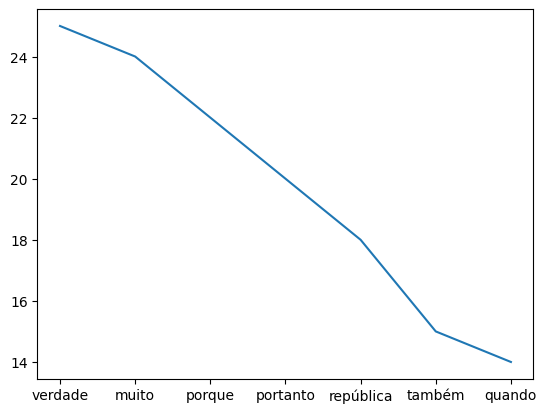

In [3]:
def create_bow(text):
  """Creates a Bag-of-Words representation from text.

  Args:
    text: The input text string.

  Returns:
    A dictionary where keys are words and values are their frequencies.
  """
  words = text.lower().split()  # Convert to lowercase and split into words
  word_counts = Counter(words)  # Count word frequencies
  return dict(word_counts)  # Return as a dictionaryt


ext = speech_data['transcript']

# clean the text of punctuation and numbers
text = ' '.join(speech_data['transcript'])

text = re.sub(r'[^\w\s]', '', text) # remove pontuation
text = re.sub(r'\d+', '', text)  # Remove numbers

bow = create_bow(text)
text = re.sub(r'\d+', '', text)     


print(len(bow.keys()))
print(bow)



# make a new dict with only the n most common words bigger than 4 characters
n = 7
max_len = 4
n_bow = {k: v for k, v in bow.items() if len(k) > max_len}
n_bow = dict(sorted(n_bow.items(), key=lambda item: item[1], reverse=True)[:n])


plt.plot(list(n_bow.keys()), list(n_bow.values()))
plt.show()

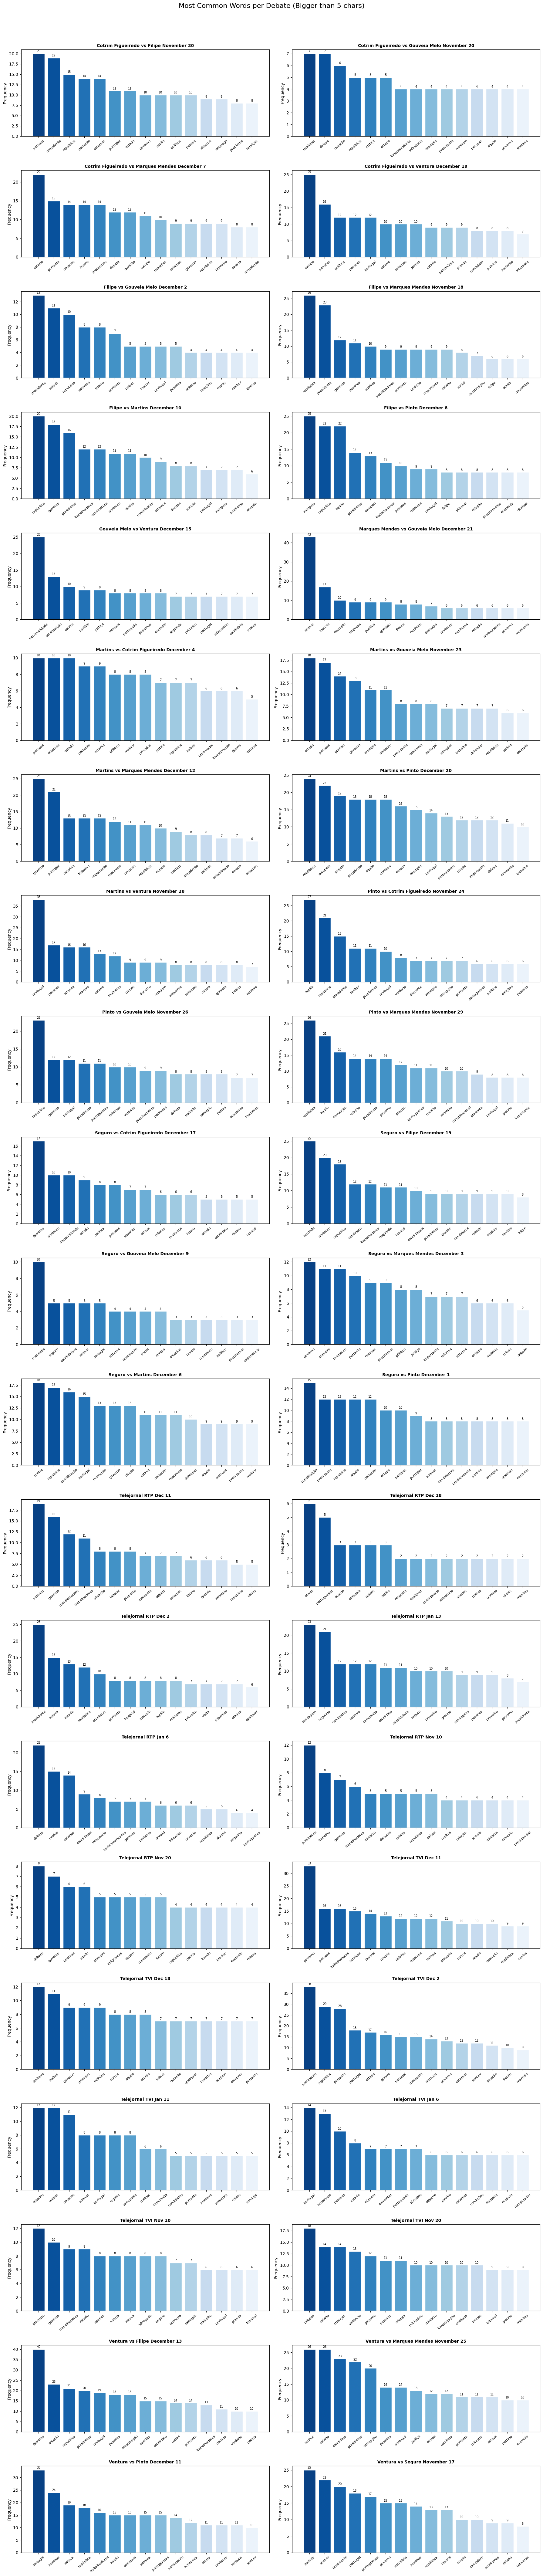

In [4]:
stopwords_pt = {'também', 'porque', 'quando', 'então', 'ainda', 'depois',
                'sempre', 'muito', 'isso', 'aqui', 'sobre', 'mesmo',
                'todos', 'nosso', 'nossa', 'temos', 'podem', 'estar'}



features_dir  = "Project_Features/"
speech_files  = sorted([f for f in os.listdir(features_dir) if f.endswith('_speech.pkl')])

top_n = 15
n_cols = 2
n_rows = -(-len(speech_files) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, file_name in enumerate(speech_files):
    debate = file_name.replace('_speech.pkl', '')
    try:
        df = pd.read_pickle(os.path.join(features_dir, file_name))

        text_blob = ' '.join(df['transcript'].dropna().astype(str).tolist()).lower()
        text_blob = re.sub(r'[^\w\s]', '', text_blob)
        text_blob = re.sub(r'\d+', '', text_blob)

        word_counts = Counter(
            w for w in text_blob.split()
            if len(w) > 5 and w not in stopwords_pt
        )

        top_words = pd.Series(dict(word_counts.most_common(top_n)))

        bars = axes[i].bar(top_words.index, top_words.values,
                           color=sns.color_palette('Blues_r', top_n),
                           edgecolor='white')
        for bar, val in zip(bars, top_words.values):
            axes[i].text(bar.get_x() + bar.get_width() / 2,
                         bar.get_height() + top_words.max() * 0.01,
                         str(val), ha='center', va='bottom', fontsize=7)

        axes[i].set_title(debate.replace('_', ' '), fontsize=10, fontweight='bold')
        axes[i].set_ylabel('Frequency')
        axes[i].tick_params(axis='x', rotation=40, labelsize=8)

    except Exception as e:
        axes[i].set_title(f'{debate} — ERROR', fontsize=9, color='red')
        print(f"Error reading {file_name}: {e}")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'Most Common Words per Debate (Bigger than 5 chars)', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

# See available fields in data

In [5]:
# Show the available fields for whichever modalities loaded for this video
for _nm in ['speech_data', 'audio_data', 'visual_data', 'ocr_data']:
    _df = globals().get(_nm)
    if _df is not None:
        print(f'{_nm:12s}: {_df.columns.tolist()}')
    else:
        print(f'{_nm:12s}: (not available for this video)')


speech_data : ['timestamp', 'duration', 'transcript', 'text_embedding']
audio_data  : ['time stamp', 'duration', 'meanF0Hz', 'stdevF0Hz', 'HNR', 'localJitter', 'localabsoluteJitter', 'rapJitter', 'ppq5Jitter', 'ddpJitter', 'localShimmer', 'localdbShimmer', 'apq3Shimmer', 'apq5Shimmer', 'apq11Shimmer', 'ddaShimmer', 'f1_mean', 'f2_mean', 'f3_mean', 'f4_mean', 'f1_median', 'f2_median', 'f3_median', 'f4_median', 'npause', 'speechrate', 'articulationrate', 'asd', 'speak_embeddings', 'pF', 'fdisp', 'avgFormant', 'mff']
visual_data : ['Frame', 'Poses', 'Fer']
ocr_data    : (not available for this video)


# Loop snippet to perform in all pkl files

In [6]:
# Quick inventory of every feature file available
features_dir = "Project_Features/"
all_files = [f for f in os.listdir(features_dir) if f.endswith('.pkl')]

kinds = Counter(f.rsplit('_', 1)[-1].replace('.pkl', '') for f in all_files)
debates   = sorted({f.rsplit('_', 1)[0] for f in all_files if 'Telejornal' not in f and any(k in f for k in ['_audio','_speech','_visual'])})
newscasts = sorted({f.rsplit('_', 1)[0] for f in all_files if 'Telejornal' in f})

print(f"{len(all_files)} feature files by kind: {dict(kinds)}")
print(f"\n{len(debates)} debate videos, {len(newscasts)} newscast videos")
print("Plus meta files: candidate_party.pkl, polls_timeline.pkl")

114 feature files by kind: {'audio': 28, 'visual': 28, 'speech': 42, 'ocr': 14, 'timeline': 1, 'party': 1}

28 debate videos, 14 newscast videos
Plus meta files: candidate_party.pkl, polls_timeline.pkl


# Dimensionality reduction
  for audio data for debates (PCA VS T-SNE VS UMAP) 

Matrix ready! Shape: (82, 512) (Audio Segments, 512 Features)


/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


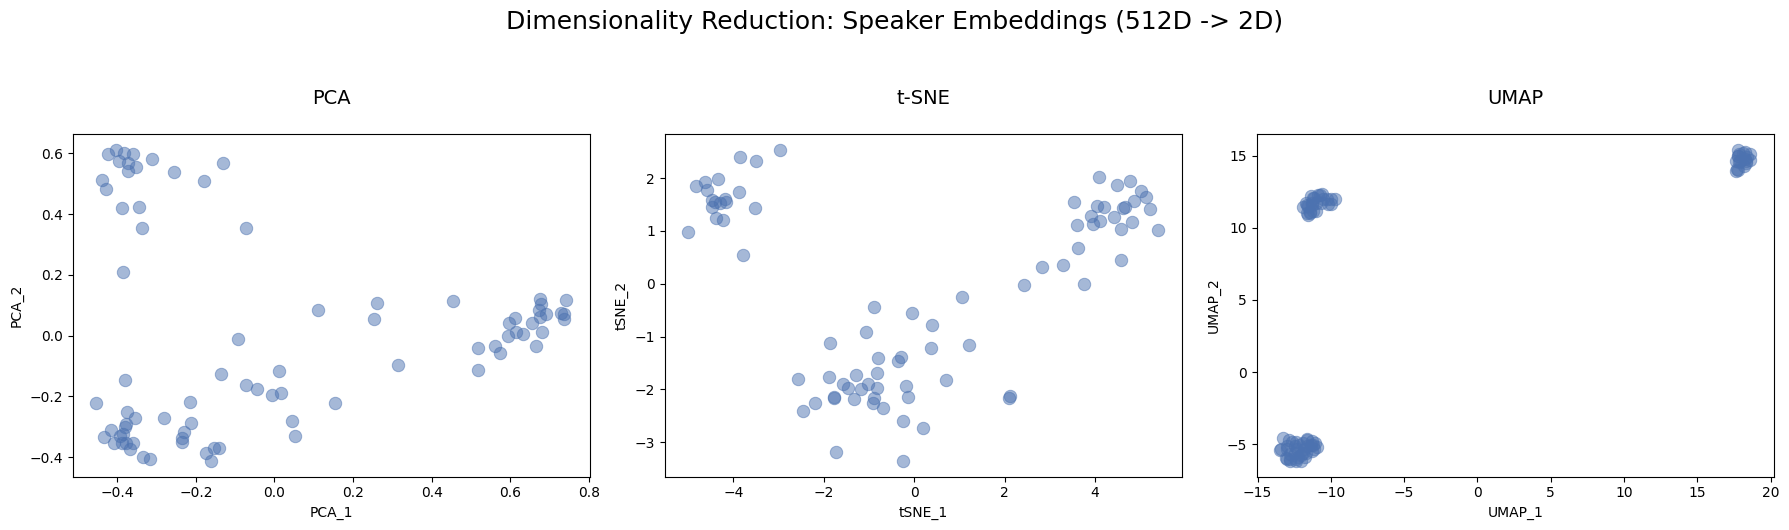

In [7]:

df_audio = pd.read_pickle('Project_Features/Seguro_vs_Filipe_December_19_audio.pkl')
#df_audio.describe('Project_Features/Seguro_vs_Filipe_December_19_audio.pkl')

df_clean = df_audio.dropna(subset=['speak_embeddings']).copy()
X_embeddings = np.vstack(df_clean['speak_embeddings'].values)

print(f"Matrix ready! Shape: {X_embeddings.shape} (Audio Segments, 512 Features)")

# PCA 

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_embeddings)
df_clean['PCA_1'] = pca_result[:, 0]
df_clean['PCA_2'] = pca_result[:, 1]

# t-SNE 
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_result = tsne.fit_transform(X_embeddings)
df_clean['tSNE_1'] = tsne_result[:, 0]
df_clean['tSNE_2'] = tsne_result[:, 1]

# UMAP 
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
umap_result = umap_model.fit_transform(X_embeddings)
df_clean['UMAP_1'] = umap_result[:, 0]
df_clean['UMAP_2'] = umap_result[:, 1]


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
dot_color = '#4C72B0' 

# PCA Plot
sns.scatterplot(
    ax=axes[0], data=df_clean, x='PCA_1', y='PCA_2', 
    color=dot_color, s=80, alpha=0.5, edgecolor=None
)
axes[0].set_title('PCA\n', fontsize=14)

# t-SNE Plot
sns.scatterplot(
    ax=axes[1], data=df_clean, x='tSNE_1', y='tSNE_2', 
    color=dot_color, s=80, alpha=0.5, edgecolor=None
)
axes[1].set_title('t-SNE\n', fontsize=14)

# UMAP Plot
sns.scatterplot(
    ax=axes[2], data=df_clean, x='UMAP_1', y='UMAP_2', 
    color=dot_color, s=80, alpha=0.5, edgecolor=None
)
axes[2].set_title('UMAP\n', fontsize=14)

plt.suptitle("Dimensionality Reduction: Speaker Embeddings (512D -> 2D)", fontsize=18, y=1.05)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


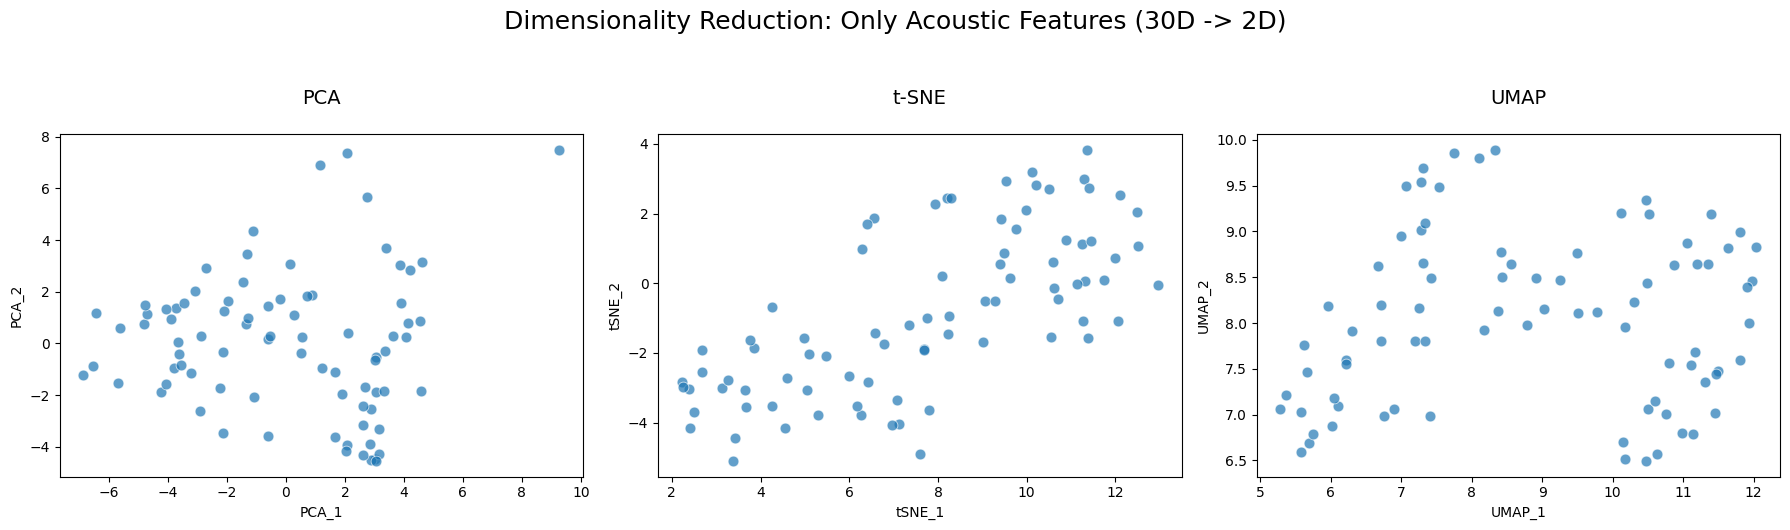

In [8]:
acoustic_features = [
    'meanF0Hz', 'stdevF0Hz', 'HNR', 'localJitter', 'localabsoluteJitter', 
    'rapJitter', 'ppq5Jitter', 'ddpJitter', 'localShimmer', 'localdbShimmer', 
    'apq3Shimmer', 'apq5Shimmer', 'apq11Shimmer', 'ddaShimmer', 'f1_mean', 
    'f2_mean', 'f3_mean', 'f4_mean', 'f1_median', 'f2_median', 'f3_median', 
    'f4_median', 'npause', 'speechrate', 'articulationrate', 'asd', 'pF', 
    'fdisp', 'avgFormant', 'mff'
]

df_features = df_clean.dropna(subset=acoustic_features).copy()
X_acoustic = df_features[acoustic_features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_acoustic)


pca = PCA(n_components=2)
df_features['PCA_1'] = pca.fit_transform(X_scaled)[:, 0]
df_features['PCA_2'] = pca.fit_transform(X_scaled)[:, 1]

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
df_features['tSNE_1'] = tsne.fit_transform(X_scaled)[:, 0]
df_features['tSNE_2'] = tsne.fit_transform(X_scaled)[:, 1]

umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
df_features['UMAP_1'] = umap_model.fit_transform(X_scaled)[:, 0]
df_features['UMAP_2'] = umap_model.fit_transform(X_scaled)[:, 1]


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cores = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Blue, Orange, Green

# PCA
sns.scatterplot(
    ax=axes[0], data=df_features, x='PCA_1', y='PCA_2', 
    s=60, alpha=0.7, legend=False
)
axes[0].set_title('PCA\n', fontsize=14)

# t-SNE
sns.scatterplot(
    ax=axes[1], data=df_features, x='tSNE_1', y='tSNE_2', 
    s=60, alpha=0.7, legend=False
)
axes[1].set_title('t-SNE\n', fontsize=14)

# UMAP
sns.scatterplot(
    ax=axes[2], data=df_features, x='UMAP_1', y='UMAP_2', 
    s=60, alpha=0.7
)
axes[2].set_title('UMAP\n', fontsize=14)


plt.suptitle("Dimensionality Reduction: Only Acoustic Features (30D -> 2D)", fontsize=18, y=1.05)
plt.tight_layout()
plt.show()

# Finding Themes intervals

Themes: Catch words

  * Estabilidade Politica: estabilidade, magistratura de influência, dissolução, parlamento, moderação, governabilidade, diálogo, crise política, compromisso
  * SNS/Saúde: sns, médicos de família, urgências, listas de espera, setor privado, saúde, profissionais de saúde, hospitais, hospital
  * Habitação: habitação, rendas, especulação imobiliária, oferta, construção, crédito habitação, crise habitacional, licenciamento, impostos,poder de compra
  * Imigração: imigração, nacionalidade, fronteiras, integração, demografia, segurança, regularização, xenofobia, multiculturalismo
  * Macroeconomia: macroeconomia, economia, inflação, custo de vida, salários, impostos, crescimento económico, concertação social, poder de compra, pacote laboral 
  * Defesa: defesa, forças armadas, investimento, nato, guerra, recrutamento militar, armamento, geoestratégia, soberania, segurança nacional, marinha, exercito, força aerea
  * Juventude: jovens, juventude, fuga de cérebros, emigração jovem, oportunidades, salários de entrada, precariedade, futuro seguro, retenção de talento, elevador social
  * Justiça/Corrupção: justiça, corrupção, impunidade, transparência, tribunais, ministério público, tribunal constitucional, reforma da justiça, morosidade, escrutínio
  * Crise Ambiental: ambiente, alterações climáticas, tempestade, incêndios, proteção civil, estado de calamidade, sustentabilidade, transição climática, apoios estatais, ecologia
  * Eleições: eleições,voto, candidatos, campanha, partidos políticos,debate eleitoral,programas eleitorais, promessas de campanha, votação, eleitores



For one debate

In [9]:

temas_dict = {
    "Estabilidade Politica": ["estabilidade", "magistratura de influência", "dissolução", "parlamento", "moderação", "governabilidade", "diálogo", "crise política", "compromisso"],
    "SNS/Saúde": ["sns", "médicos de família", "urgências", "listas de espera", "setor privado", "saúde", "profissionais de saúde", "hospitais", "hospital"],
    "Habitação": ["habitação", "rendas", "especulação imobiliária", "oferta", "construção", "crédito habitação", "crise habitacional", "licenciamento", "impostos", "poder de compra"],
    "Imigração": ["imigração", "nacionalidade", "fronteiras", "integração", "demografia", "segurança", "regularização", "xenofobia", "multiculturalismo"],
    "Macroeconomia": ["macroeconomia", "economia", "inflação", "custo de vida", "salários", "impostos", "crescimento económico", "concertação social", "poder de compra", "pacote laboral"],
    "Defesa": ["defesa", "forças armadas", "investimento", "nato", "guerra", "recrutamento militar", "armamento", "geoestratégia", "soberania", "segurança nacional", "marinha", "exercito", "força aerea"],
    "Juventude": ["jovens", "juventude", "fuga de cérebros", "emigração jovem", "oportunidades", "salários de entrada", "precariedade", "futuro seguro", "retenção de talento", "elevador social"],
    "Justiça/Corrupção": ["justiça", "corrupção", "impunidade", "transparência", "tribunais", "ministério público", "tribunal constitucional", "reforma da justiça", "morosidade", "escrutínio"],
    "Crise Ambiental": ["ambiente", "alterações climáticas", "tempestade", "incêndios", "proteção civil", "estado de calamidade", "sustentabilidade", "transição climática", "apoios estatais", "ecologia"],
    "Eleições": ["eleições", "voto", "candidatos", "campanha", "partidos políticos", "debate eleitoral", "programas eleitorais", "promessas de campanha", "votação", "eleitores"]
}

df_speech = pd.read_pickle('Project_Features/Seguro_vs_Filipe_December_19_speech.pkl')

# detetar o tema dominante numa frase
def detetar_tema(texto):
    if not isinstance(texto, str):
        return "Sem Tema Claro"
    
    texto_lower = texto.lower()
    contagens = {}
    
    for tema, palavras in temas_dict.items():
        count = 0
        for palavra in palavras:
            count += len(re.findall(r'\b' + re.escape(palavra) + r'\b', texto_lower))
        if count > 0:
            contagens[tema] = count
            
   
    if contagens:
        tema_dominante = max(contagens, key=contagens.get)
        return tema_dominante
    else:
        return "Sem Tema Claro"


df_speech['Tema'] = df_speech['transcript'].apply(detetar_tema)


intervalos_temas = []
tema_atual = None
inicio_atual = 0

for index, row in df_speech.sort_values('timestamp').iterrows():
    tema_linha = row['Tema']
  
    if tema_linha != tema_atual:
     
        if tema_atual is not None and tema_atual != "Sem Tema Claro":
            fim_anterior = df_speech.loc[index_anterior, 'timestamp'] + df_speech.loc[index_anterior, 'duration']
            intervalos_temas.append({
                'Tema': tema_atual,
                'Start Time (s)': round(inicio_atual, 2),
                'End Time (s)': round(fim_anterior, 2),
                'Duração (s)': round(fim_anterior - inicio_atual, 2)
            })
        

        tema_atual = tema_linha
        inicio_atual = row['timestamp']
        
    index_anterior = index

if tema_atual is not None and tema_atual != "Sem Tema Claro":
    fim_anterior = df_speech.loc[index_anterior, 'timestamp'] + df_speech.loc[index_anterior, 'duration']
    intervalos_temas.append({
        'Tema': tema_atual,
        'Start Time (s)': round(inicio_atual, 2),
        'End Time (s)': round(fim_anterior, 2),
        'Duração (s)': round(fim_anterior - inicio_atual, 2)
    })

df_intervalos = pd.DataFrame(intervalos_temas)

display(df_intervalos)

,Tema,Start Time (s),End Time (s),Duração (s)
0,Justiça/Corrupção,79.82,131.03,51.22
1,Eleições,190.52,238.64,48.13
2,Eleições,261.27,362.03,100.76
3,Eleições,428.08,452.03,23.95
4,Macroeconomia,470.34,553.87,83.53
5,Estabilidade Politica,632.62,814.18,181.56
6,Juventude,886.63,910.10,23.47
7,Macroeconomia,959.85,1117.49,157.65
8,Imigração,1119.27,1177.70,58.44
9,Estabilidade Politica,1257.25,1315.00,57.75


Using wavelet transcript analysis (for one theme)

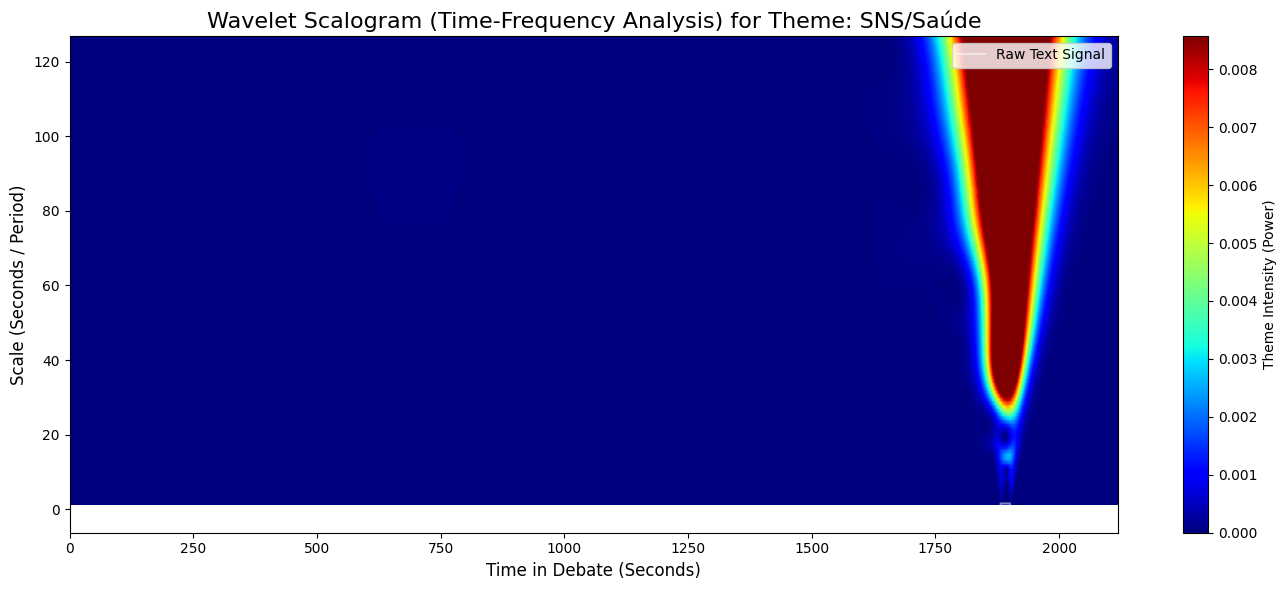

In [10]:
tema_alvo = "SNS/Saúde"

debate_length_sec = int(df_speech['timestamp'].max() + df_speech['duration'].iloc[-1]) + 1


# array of zeros representing every second of the debate
signal = np.zeros(debate_length_sec)

catchwords_saude = ["sns", "médicos", "urgências", "saúde", "hospitais"]

# count number of catchwords in each sentence and add to the signal
for index, row in df_speech.iterrows():
    start_time = int(row['timestamp'])
    duration = int(max(1, row['duration']))
    text = str(row['transcript']).lower()
    
    # Count how many catchwords are in this sentence
    hits = sum(text.count(word) for word in catchwords_saude)
    
    if hits > 0:
        signal[start_time:start_time+duration] += hits / duration

# wavelet calc
wavelet = 'cmor1.5-1.0' # morlet wavelet
scales = np.arange(1, 128)

# Calculate the coefficients (power) and the corresponding frequencies
coefficients, frequencies = pywt.cwt(signal, scales, wavelet, sampling_period=1)


power = (abs(coefficients)) ** 2

#plot
plt.figure(figsize=(14, 6))
plt.imshow(power, extent=[0, debate_length_sec, scales[-1], scales[0]], 
           cmap='jet', aspect='auto', vmax=power.max()*0.5) 

plt.gca().invert_yaxis() 
plt.title(f'Wavelet Scalogram (Time-Frequency Analysis) for Theme: {tema_alvo}', fontsize=16)
plt.ylabel('Scale (Seconds / Period)', fontsize=12)
plt.xlabel('Time in Debate (Seconds)', fontsize=12)
plt.colorbar(label='Theme Intensity (Power)')

plt.plot(np.linspace(0, debate_length_sec, len(signal)), signal * 10, color='white', alpha=0.5, label='Raw Text Signal')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

for all themes

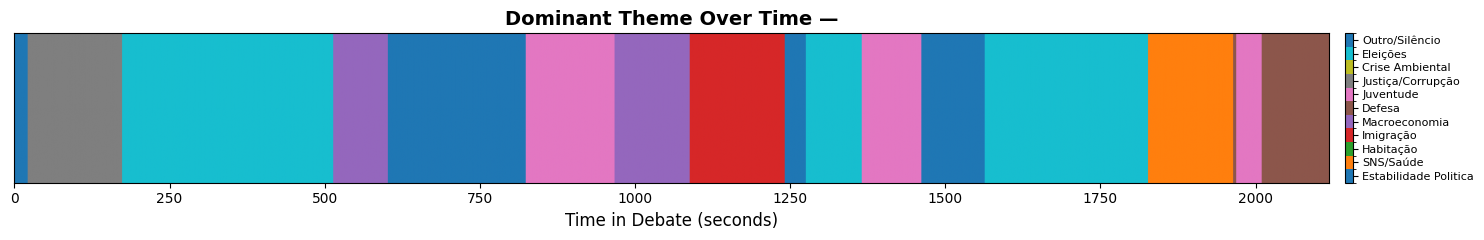

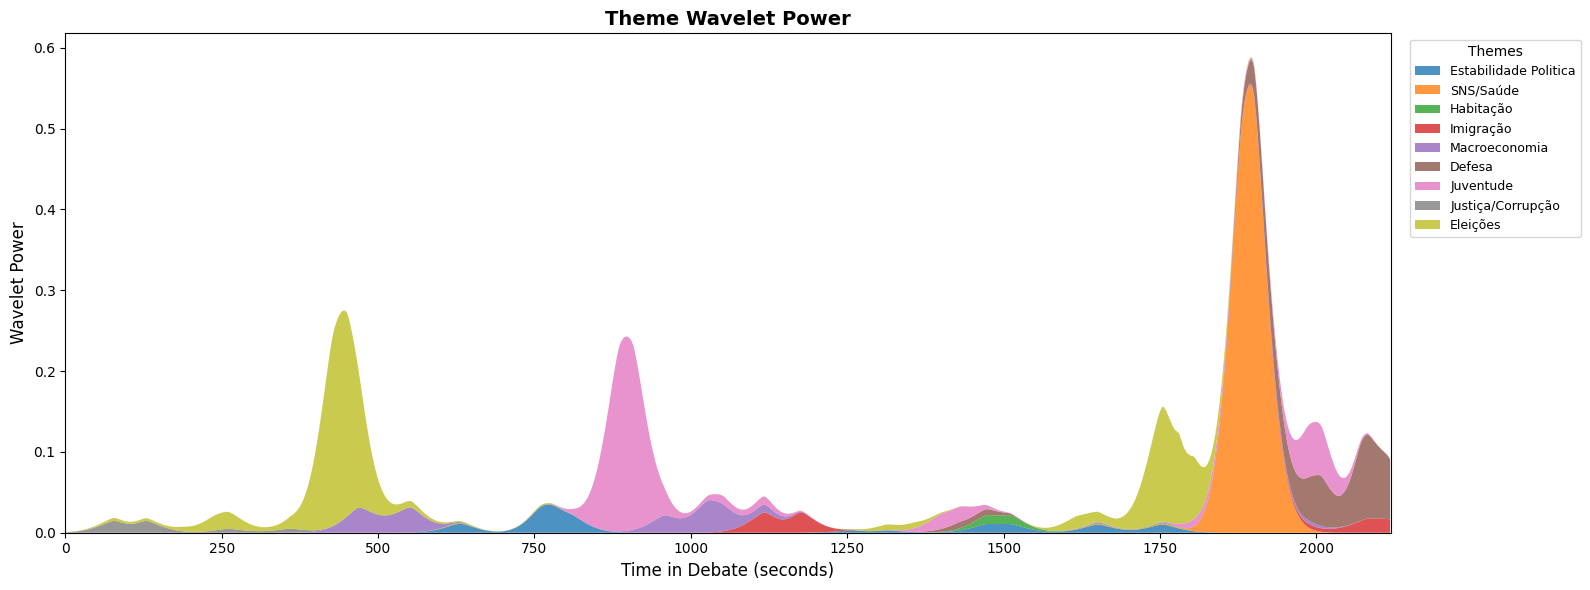

In [11]:
import matplotlib as mpl

# Build a per-second intensity signal for every theme (second-resolution)
debate_length_sec = int(df_speech['timestamp'].max() + df_speech['duration'].iloc[-1]) + 1
signals = {}
for _tema, _palavras in temas_dict.items():
    _sig = np.zeros(debate_length_sec)
    for _, _row in df_speech.iterrows():
        _st  = int(_row['timestamp'])
        _dur = int(max(1, _row['duration']))
        _txt = str(_row['transcript']).lower()
        _hits = sum(len(re.findall(r'\b' + re.escape(_w) + r'\b', _txt)) for _w in _palavras)
        if _hits > 0:
            _sig[_st:_st + _dur] += _hits / _dur
    signals[_tema] = _sig

wavelet = 'cmor1.5-1.0'
scales  = np.arange(0.1, 64)
poder_tematico = {}

for tema, sinal in signals.items():
    if np.sum(sinal) > 0:
        coeffs, _ = pywt.cwt(sinal, scales, wavelet, sampling_period=1)
        power = (np.abs(coeffs)) ** 2
        poder_tematico[tema] = np.sum(power, axis=0)
    else:
        poder_tematico[tema] = np.zeros(debate_length_sec)

df_power = pd.DataFrame(poder_tematico)


limiar_energia            = 0.002
tema_dominante            = df_power.idxmax(axis=1)
max_energia               = df_power.max(axis=1)
tema_dominante[max_energia < limiar_energia] = "Outro/Silêncio"


all_themes  = [t for t in temas_dict.keys()] + ["Outro/Silêncio"]
theme2idx   = {t: i for i, t in enumerate(all_themes)}
color_signal = np.array([theme2idx[t] for t in tema_dominante])

palette = sns.color_palette('tab10', len(all_themes))
cmap    = mpl.colors.ListedColormap(palette)
bounds  = np.arange(len(all_themes) + 1) - 0.5
norm    = mpl.colors.BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(figsize=(16, 2.5))
img = ax.imshow(color_signal[np.newaxis, :], aspect='auto',
                cmap=cmap, norm=norm,
                extent=[0, debate_length_sec, 0, 1])
ax.set_yticks([])
ax.set_xlabel('Time in Debate (seconds)', fontsize=12)
ax.set_title('Dominant Theme Over Time —', fontsize=14, fontweight='bold')

cbar = plt.colorbar(img, ax=ax, orientation='vertical', pad=0.01)
cbar.set_ticks(range(len(all_themes)))
cbar.set_ticklabels(all_themes, fontsize=8)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(16, 6))
ax.stackplot(range(debate_length_sec),
             [df_power[t].values for t in temas_dict if np.sum(signals[t]) > 0],
             labels=[t for t in temas_dict if np.sum(signals[t]) > 0],
             colors=sns.color_palette('tab10', len(temas_dict)),
             alpha=0.8)
ax.set_title('Theme Wavelet Power', fontsize=14, fontweight='bold')
ax.set_xlabel('Time in Debate (seconds)', fontsize=12)
ax.set_ylabel('Wavelet Power', fontsize=12)
ax.set_xlim(0, debate_length_sec)
ax.legend(title='Themes', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

# News missing data analysis

✓ Loaded: Project_Features/Cotrim_Figueiredo_vs_Ventura_December_19_audio.pkl — (102, 33)
✓ Loaded: Project_Features/Cotrim_Figueiredo_vs_Ventura_December_19_speech.pkl — (37, 4)


✓ Loaded: Project_Features/Cotrim_Figueiredo_vs_Ventura_December_19_visual.pkl — (2165, 3)

=== Audio DATA ===
Shape: (102, 33)


,time stamp,duration,meanF0Hz,stdevF0Hz,HNR,localJitter,localabsoluteJitter,rapJitter,ppq5Jitter,ddpJitter,...,f4_median,npause,speechrate,articulationrate,asd,speak_embeddings,pF,fdisp,avgFormant,mff
count,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,...,102.000000,102.000000,102.000000,102.000000,102.000000,102,1.020000e+02,102.000000,102.000000,102.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,102,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,"[-0.07669693, 0.002468539, -0.029221741, 0.060...",NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN
mean,1061.431892,21.462647,171.610468,39.209076,10.928712,0.027687,0.000165,0.009520,0.012631,0.028559,...,3509.305852,1.401961,5.164711,5.284158,0.190609,NaN,3.163047e-15,1021.752937,1950.966135,1519.526133
std,647.009197,20.374412,21.619580,8.013520,1.522678,0.002485,0.000029,0.001381,0.001504,0.004144,...,124.970279,1.884065,0.509320,0.446143,0.016432,NaN,7.965334e-01,37.988956,63.904867,60.060051
min,3.777000,5.434000,123.040844,18.596170,7.231566,0.021866,0.000105,0.005986,0.008334,0.017959,...,3299.341485,0.000000,3.703704,4.107788,0.157636,NaN,-1.418999e+00,965.309335,1839.373625,1410.869978
25%,465.354500,8.479500,156.721596,33.141654,9.718555,0.026206,0.000145,0.008464,0.011778,0.025393,...,3416.352628,0.000000,4.809217,4.988526,0.179140,NaN,-5.938291e-01,993.846493,1897.462648,1475.965591
50%,1014.775000,14.344000,174.130674,40.600880,11.028852,0.027678,0.000162,0.009456,0.012415,0.028367,...,3498.326996,1.000000,5.158335,5.298128,0.188747,NaN,-2.830216e-02,1013.562869,1952.777290,1517.892181
75%,1632.729500,26.223500,190.404175,44.962348,12.111896,0.029087,0.000179,0.010252,0.013525,0.030756,...,3567.642545,2.000000,5.525911,5.582239,0.200460,NaN,4.921215e-01,1044.517954,1984.958655,1568.153168



=== Speech DATA ===
Shape: (37, 4)


,timestamp,duration,transcript,text_embedding
count,37.000000,37.000000,37,37
unique,NaN,NaN,37,37
top,NaN,NaN,Boa noite. É um mês das presidenciais hoje de...,"[1.727637, -0.041435923, 0.29471213, 0.1202736..."
freq,NaN,NaN,1,1
mean,1077.278973,40.566541,NaN,NaN
std,655.322142,23.416347,NaN,NaN
min,3.777000,20.048000,NaN,NaN
25%,505.792000,25.599000,NaN,NaN
50%,1060.912000,32.349000,NaN,NaN
75%,1659.316000,41.512000,NaN,NaN



=== Visual DATA ===
Shape: (2165, 3)


,Frame,Poses,Fer
count,2165,2165,2165
unique,2165,2163,2165
top,Frames/Cotrim_Figueiredo_vs_Ventura_December_1...,[],"[{'bbox': [98, 453, 138, 513], 'top_emotion': ..."
freq,1,3,1


/tmp/claude-0/ipykernel_2475/2215895814.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing.values, y=missing.index, ax=ax, palette='Reds_r')
/tmp/claude-0/ipykernel_2475/2215895814.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing.values, y=missing.index, ax=ax, palette='Reds_r')
/tmp/claude-0/ipykernel_2475/2215895814.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing.values, y=missing.index, ax=ax, palette='Reds_r')


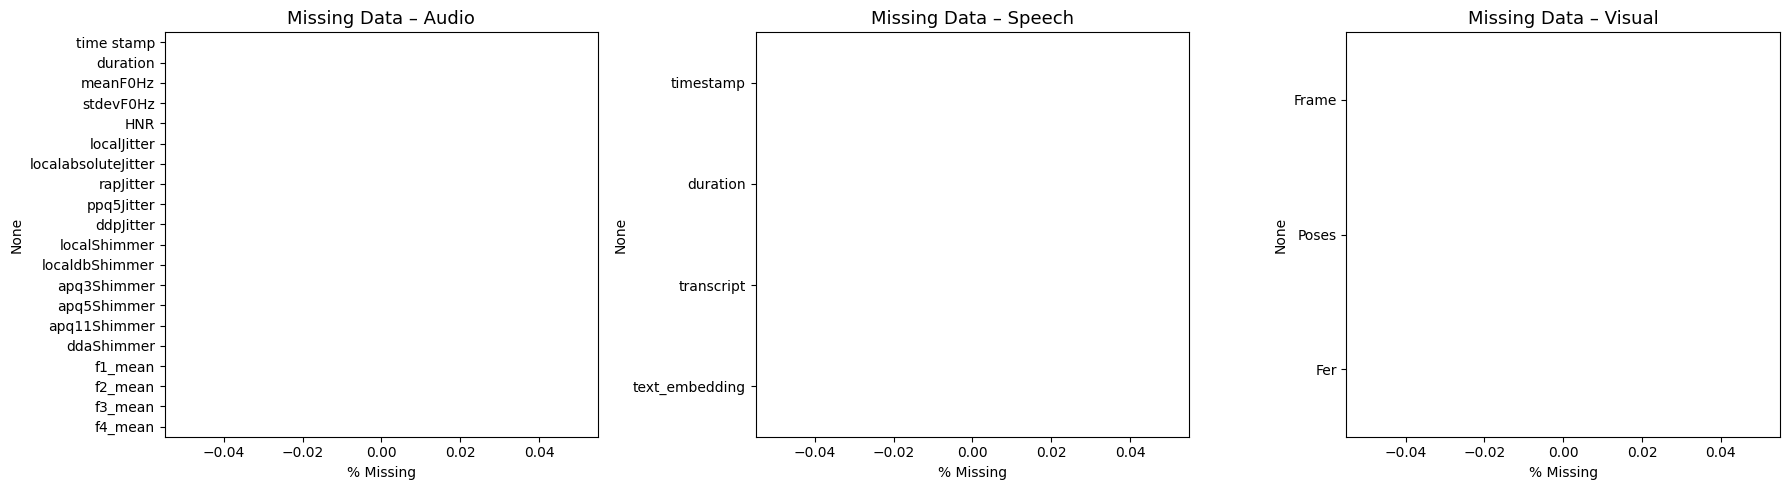

In [12]:
# Data loading 
features_dir = "Project_Features/"
debate_name = "Cotrim_Figueiredo_vs_Ventura_December_19"

def safe_load(path):
    try:
        df = pd.read_pickle(path)
        print(f"✓ Loaded: {path} — {df.shape}")
        return df
    except FileNotFoundError:
        print(f"✗ Not found: {path}")
        return None

df_audio   = safe_load(features_dir + debate_name + '_audio.pkl')
df_speech  = safe_load(features_dir + debate_name + '_speech.pkl')
df_visual  = safe_load(features_dir + debate_name + '_visual.pkl')


for df, name in [(df_audio, 'Audio'), (df_speech, 'Speech'), (df_visual, 'Visual')]:
    if df is None:
        print(f"\n[{name}] — data not available, skipping.")
        continue
    print(f"\n=== {name} DATA ===")
    print(f"Shape: {df.shape}")
    display(df.describe(include='all'))


available = [(df, name) for df, name in [(df_audio, 'Audio'), (df_speech, 'Speech'), (df_visual, 'Visual')] if df is not None]

if available:
    fig, axes = plt.subplots(1, len(available), figsize=(6 * len(available), 5))
    if len(available) == 1:
        axes = [axes]
    for ax, (df, name) in zip(axes, available):
        missing = df.isna().mean().sort_values(ascending=False).head(20)
        sns.barplot(x=missing.values, y=missing.index, ax=ax, palette='Reds_r')
        ax.set_title(f'Missing Data – {name}', fontsize=13)
        ax.set_xlabel('% Missing')
    plt.tight_layout()
    plt.show()

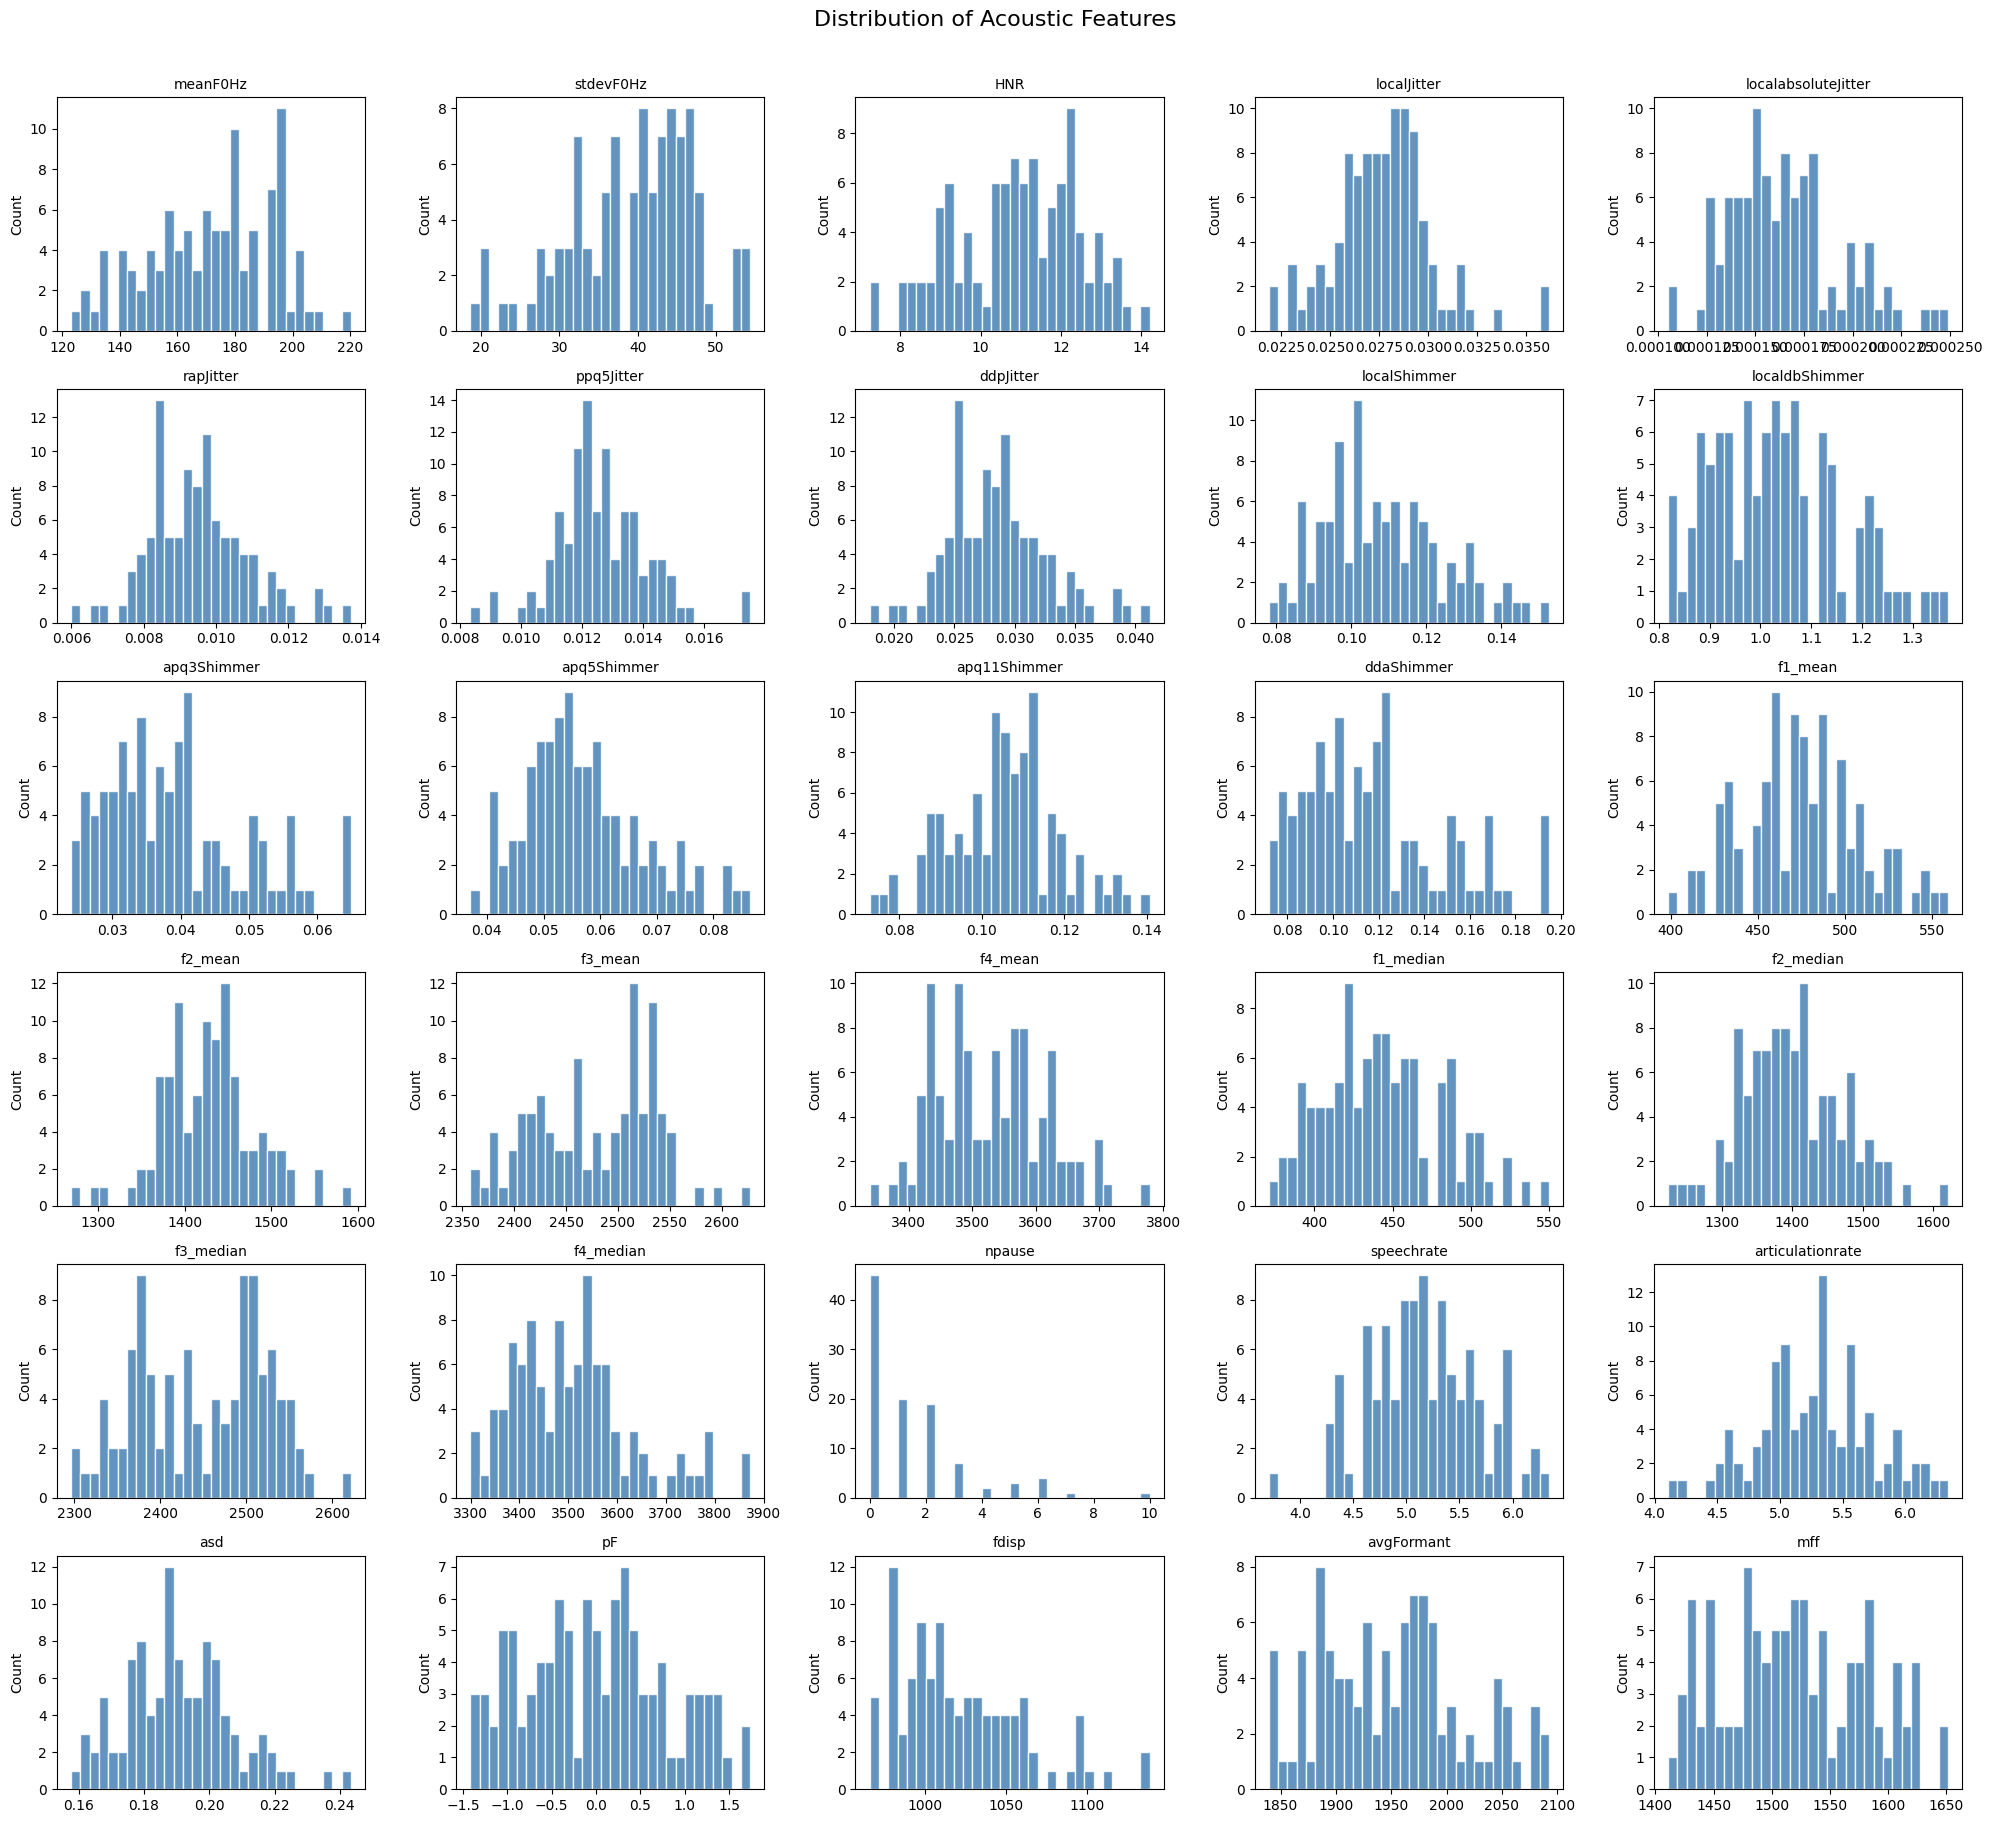

In [13]:
acoustic_features = [
    'meanF0Hz', 'stdevF0Hz', 'HNR', 'localJitter', 'localabsoluteJitter',
    'rapJitter', 'ppq5Jitter', 'ddpJitter', 'localShimmer', 'localdbShimmer',
    'apq3Shimmer', 'apq5Shimmer', 'apq11Shimmer', 'ddaShimmer',
    'f1_mean', 'f2_mean', 'f3_mean', 'f4_mean',
    'f1_median', 'f2_median', 'f3_median', 'f4_median',
    'npause', 'speechrate', 'articulationrate', 'asd', 'pF', 'fdisp', 'avgFormant', 'mff'
]

if df_audio is None:
    print("Audio data not available — skipping histogram grid.")
else:
    available_feats = [f for f in acoustic_features if f in df_audio.columns]
    df_audio_clean = df_audio[available_feats].dropna()

    n_cols = 5
    n_rows = -(-len(available_feats) // n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3))
    axes = axes.flatten()

    for i, feat in enumerate(available_feats):
        axes[i].hist(df_audio_clean[feat], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
        axes[i].set_title(feat, fontsize=10)
        axes[i].set_ylabel('Count')

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Distribution of Acoustic Features', fontsize=16, y=1.01)
    plt.tight_layout()
    plt.show()

/tmp/claude-0/ipykernel_2475/2875874184.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=emotion_counts.index, y=emotion_counts.values, ax=axes[0], palette='viridis')


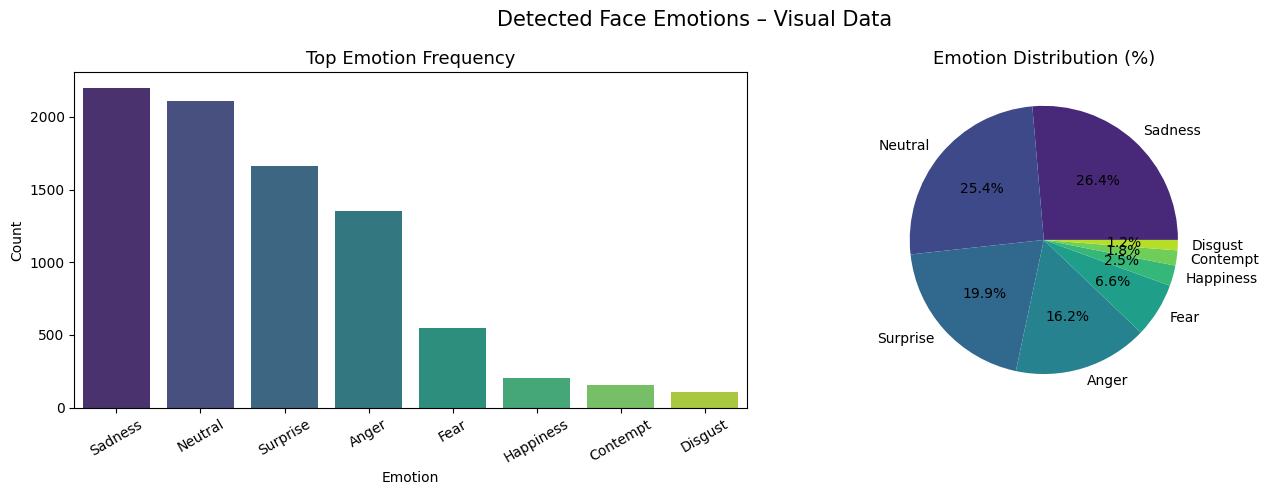

/tmp/claude-0/ipykernel_2475/2875874184.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_probs.index, y=avg_probs.values, palette='magma')


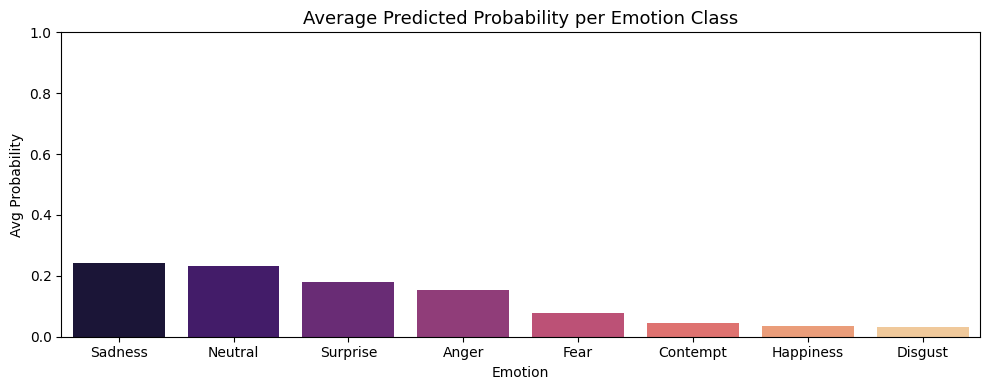

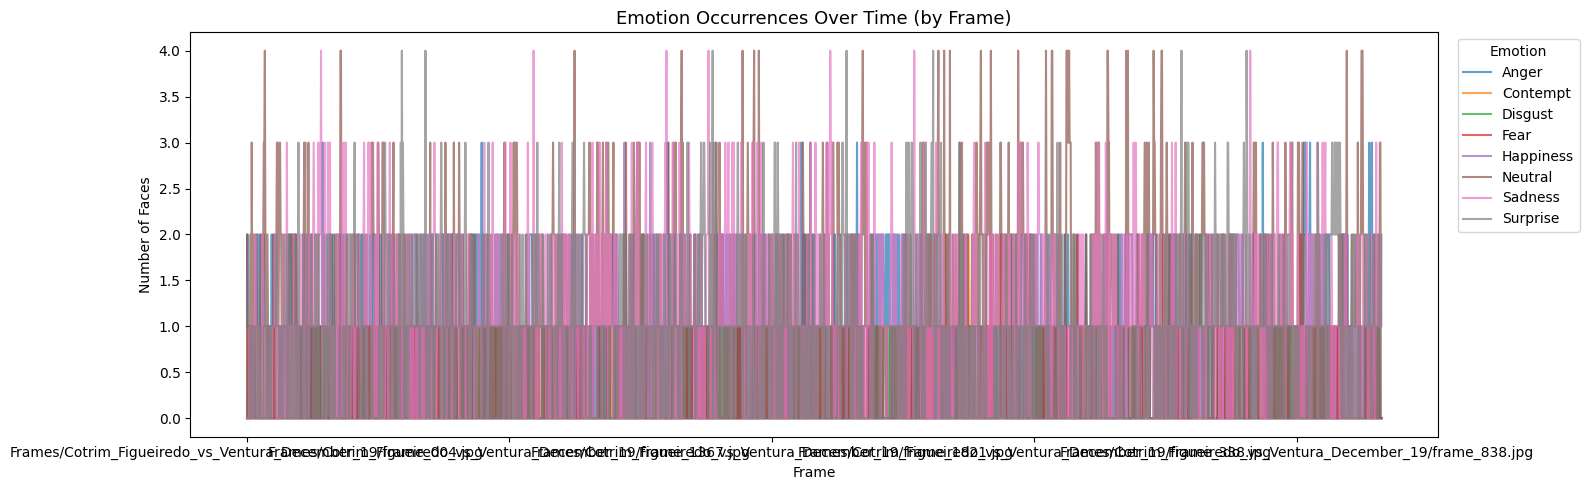

In [14]:

if df_visual is None:
    print("Visual data not available — skipping emotion analysis.")
elif 'Fer' not in df_visual.columns:
    print("No 'fer' column found in visual data.")
else:
 
    faces_exploded = df_visual['Fer'].dropna().explode()
    faces_exploded = faces_exploded.dropna()


    top_emotions = faces_exploded.apply(lambda x: x['top_emotion'] if isinstance(x, dict) else None).dropna()

    probs_df = faces_exploded.apply(
        lambda x: x['probabilities'] if isinstance(x, dict) else None
    ).dropna().apply(pd.Series)

    emotion_counts = top_emotions.value_counts()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.barplot(x=emotion_counts.index, y=emotion_counts.values, ax=axes[0], palette='viridis')
    axes[0].set_title('Top Emotion Frequency', fontsize=13)
    axes[0].set_xlabel('Emotion')
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=30)

    axes[1].pie(emotion_counts.values, labels=emotion_counts.index, autopct='%1.1f%%',
                colors=sns.color_palette('viridis', len(emotion_counts)))
    axes[1].set_title('Emotion Distribution (%)', fontsize=13)

    plt.suptitle('Detected Face Emotions – Visual Data', fontsize=15)
    plt.tight_layout()
    plt.show()

    avg_probs = probs_df.mean().sort_values(ascending=False)

    plt.figure(figsize=(10, 4))
    sns.barplot(x=avg_probs.index, y=avg_probs.values, palette='magma')
    plt.title('Average Predicted Probability per Emotion Class', fontsize=13)
    plt.ylabel('Avg Probability')
    plt.xlabel('Emotion')
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()


    df_visual_clean = df_visual[['Frame', 'Fer']].dropna()
    df_visual_clean = df_visual_clean.explode('Fer').dropna(subset=['Fer'])
    df_visual_clean['top_emotion'] = df_visual_clean['Fer'].apply(
        lambda x: x['top_emotion'] if isinstance(x, dict) else None
    )
    df_visual_clean = df_visual_clean.dropna(subset=['top_emotion'])

    emotion_over_time = df_visual_clean.groupby(['Frame', 'top_emotion']).size().unstack(fill_value=0)

    plt.figure(figsize=(16, 5))
    emotion_over_time.plot(ax=plt.gca(), alpha=0.7)
    plt.title('Emotion Occurrences Over Time (by Frame)', fontsize=13)
    plt.xlabel('Frame')
    plt.ylabel('Number of Faces')
    plt.legend(title='Emotion', bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

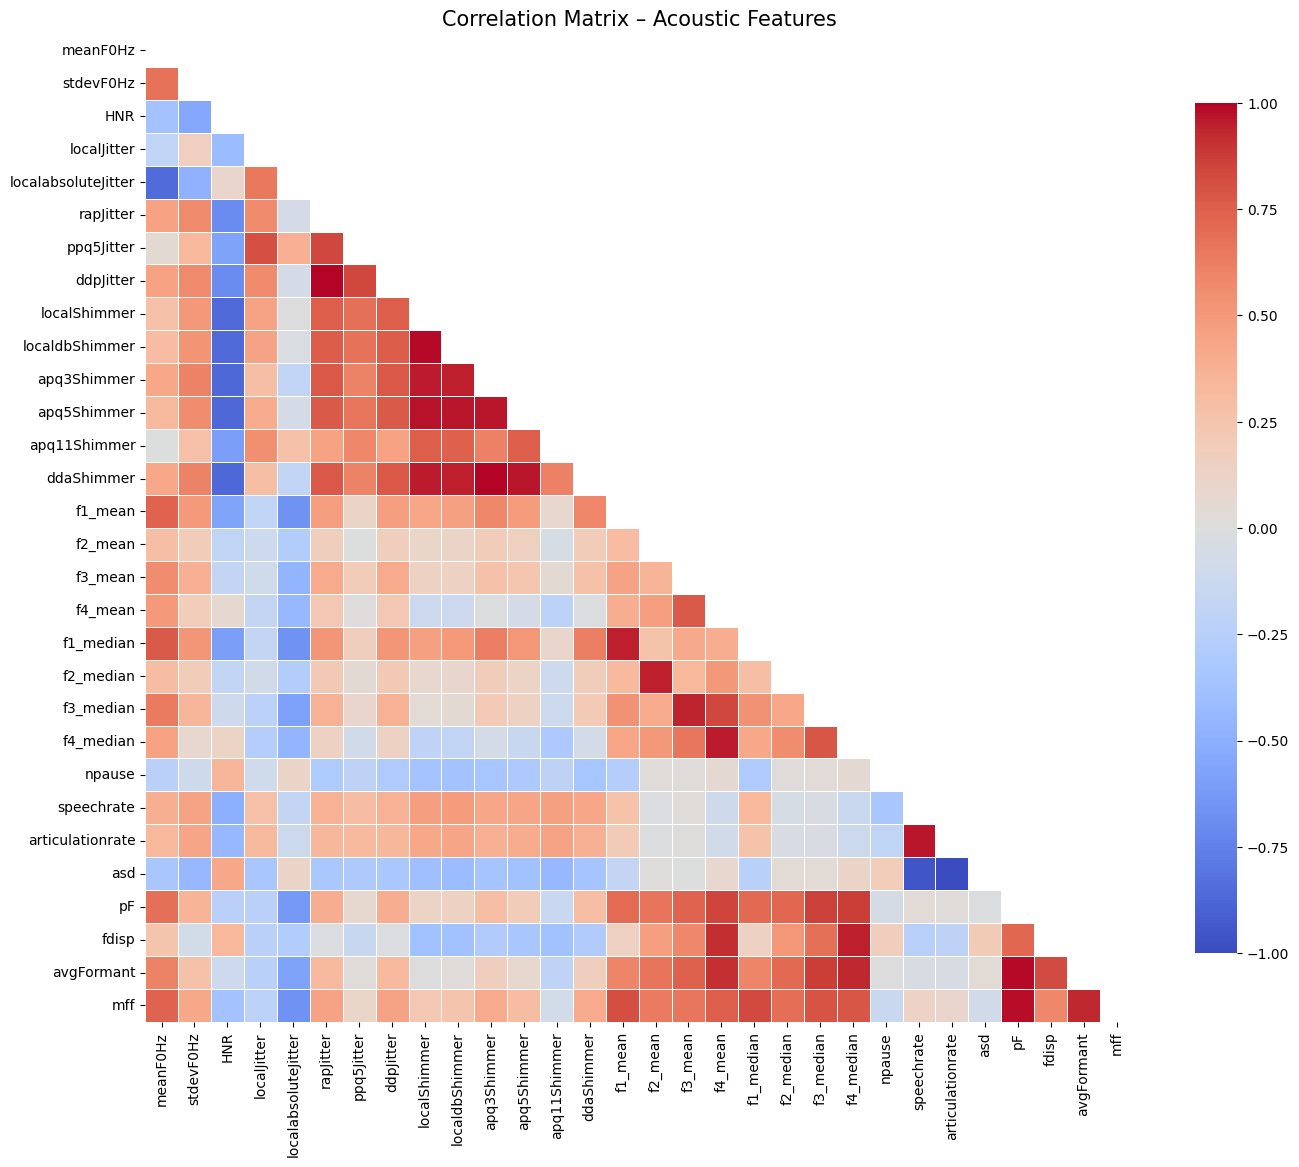

In [15]:
if df_audio is None:
    print("Audio data not available — skipping correlation heatmap.")
else:
    available_feats = [f for f in acoustic_features if f in df_audio.columns]
    corr_matrix = df_audio[available_feats].dropna().corr()

    plt.figure(figsize=(14, 12))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(
        corr_matrix, mask=mask,
        cmap='coolwarm', center=0, vmin=-1, vmax=1,
        annot=False, linewidths=0.4, square=True,
        cbar_kws={"shrink": 0.8}
    )
    plt.title('Correlation Matrix – Acoustic Features', fontsize=15)
    plt.tight_layout()
    plt.show()

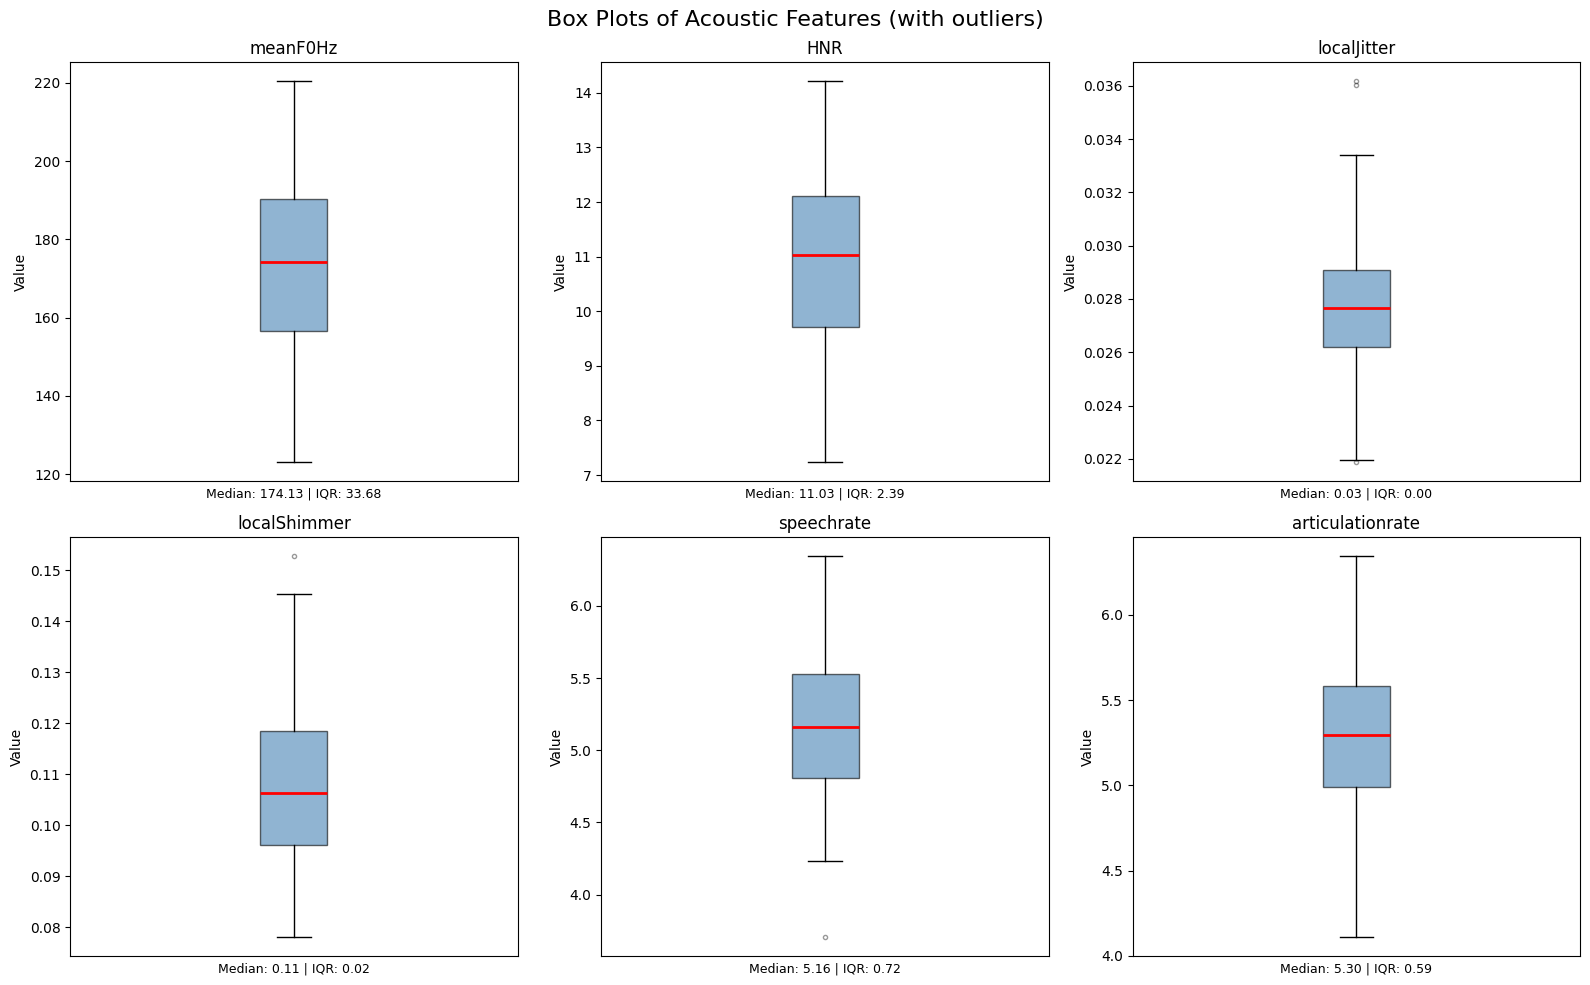

In [16]:

features_to_plot = ['meanF0Hz', 'HNR', 'localJitter', 'localShimmer', 'speechrate', 'articulationrate']

if df_audio is None:
    print("Audio data not available — skipping box plots.")
else:
    available_feats = [f for f in features_to_plot if f in df_audio.columns]

    if not available_feats:
        print("None of the target features found in audio dataframe.")
    else:
        n = len(available_feats)
        fig, axes = plt.subplots(2, -(-n // 2), figsize=(16, 10))
        axes = axes.flatten()

        for i, feat in enumerate(available_feats):
            data = df_audio[feat].dropna()
            axes[i].boxplot(data, vert=True, patch_artist=True,
                            boxprops=dict(facecolor='steelblue', alpha=0.6),
                            medianprops=dict(color='red', linewidth=2),
                            flierprops=dict(marker='o', markersize=3, alpha=0.4))
            axes[i].set_title(feat, fontsize=12)
            axes[i].set_ylabel('Value')
            axes[i].set_xticks([])
            q1, median, q3 = data.quantile([0.25, 0.5, 0.75])
            axes[i].set_xlabel(f'Median: {median:.2f} | IQR: {q3-q1:.2f}', fontsize=9)

        for j in range(i + 1, len(axes)):
            axes[j].set_visible(False)

        plt.suptitle('Box Plots of Acoustic Features (with outliers)', fontsize=16)
        plt.tight_layout()
        plt.show()

////////////////////////////////////////////////////////////////////////////////////////

Sorting the visual pkl by frame + cleaning the visual pkls all of them and saving

In [17]:
def compute_intersection_area(box1, box2):
    x_left   = max(box1[0], box2[0])
    y_top    = max(box1[1], box2[1])
    x_right  = min(box1[2], box2[2])
    y_bottom = min(box1[3], box2[3])
    if x_right < x_left or y_bottom < y_top:
        return 0.0
    return (x_right - x_left) * (y_bottom - y_top)

def calcular_area(box):
    return (box[2] - box[0]) * (box[3] - box[1])

def apply_containment_filter(detections, containment_threshold=0.90):
    if not detections:
        return []
    detections_sorted = sorted(
        detections,
        key=lambda k: calcular_area(k['bbox']) if 'bbox' in k else 0,
        reverse=True
    )
    kept_boxes = []
    for current_det in detections_sorted:
        if 'bbox' not in current_det:
            continue
        current_bbox  = current_det['bbox']
        current_area  = calcular_area(current_bbox)
        if current_area == 0:
            continue
        is_contained = False
        for kept_det in kept_boxes:
            inter_area     = compute_intersection_area(current_bbox, kept_det['bbox'])
            coverage_ratio = inter_area / current_area
            if coverage_ratio >= containment_threshold:
                is_contained = True
                break
        if not is_contained:
            kept_boxes.append(current_det)
    return kept_boxes

def count_persons(poses_list):
    if not isinstance(poses_list, list) or len(poses_list) == 0:
        return 0
    return sum(1 for p in poses_list if 'bbox' in p)

def extrair_dados_validos(lista_deteccoes, img_width=1280, img_height=720, area_min=10000):

    if not isinstance(lista_deteccoes, list) or len(lista_deteccoes) == 0:
        return []

    Y_CUTOFF    = img_height * 0.55
    LEFT_ZONE   = img_width  * 0.25
    RIGHT_ZONE  = img_width  * 0.75

    pre_clean = []
    for detec in lista_deteccoes:
        if 'bbox' not in detec:
            continue
        x1, y1, x2, y2 = detec['bbox']
        center_x = (x1 + x2) / 2
        center_y = (y1 + y2) / 2
        area     = calcular_area(detec['bbox'])

        in_bottom_left  = (center_x < LEFT_ZONE)  and (center_y > Y_CUTOFF)
        in_bottom_right = (center_x > RIGHT_ZONE) and (center_y > Y_CUTOFF)

        if not (in_bottom_left or in_bottom_right) and (area > area_min):
            pre_clean.append(detec)

    return apply_containment_filter(pre_clean, containment_threshold=0.60)


def extrair_fer_validos(fer_list, valid_poses,
                        img_width=1280, img_height=720,
                        area_min=900,
                        min_confidence=0.50,
                        pose_coverage_threshold=0.60):

    if not isinstance(fer_list, list) or len(fer_list) == 0:
        return []

    Y_CUTOFF   = img_height * 0.55
    LEFT_ZONE  = img_width  * 0.25
    RIGHT_ZONE = img_width  * 0.75


    pre_clean = []
    for face in fer_list:
        if 'bbox' not in face:
            continue
        x1, y1, x2, y2 = face['bbox']
        center_x = (x1 + x2) / 2
        center_y = (y1 + y2) / 2
        area     = calcular_area(face['bbox'])

        in_bottom_left  = (center_x < LEFT_ZONE)  and (center_y > Y_CUTOFF)
        in_bottom_right = (center_x > RIGHT_ZONE) and (center_y > Y_CUTOFF)

        if not (in_bottom_left or in_bottom_right) and (area > area_min):
            pre_clean.append(face)


    after_containment = apply_containment_filter(pre_clean, containment_threshold=0.80)


    after_confidence = []
    for face in after_containment:
        top_emotion = face.get('top_emotion')
        probs       = face.get('probabilities', {})
        confidence  = probs.get(top_emotion, 0.0) if top_emotion else 0.0

        if confidence >= min_confidence:
            after_confidence.append(face)

    if not isinstance(valid_poses, list) or len(valid_poses) == 0:
        return []  # no valid poses at all → no valid faces

    final = []
    for face in after_confidence:
        face_bbox = face['bbox']
        face_area = calcular_area(face_bbox)
        if face_area == 0:
            continue

        has_pose_backing = False
        for pose in valid_poses:
            if 'bbox' not in pose:
                continue
            inter         = compute_intersection_area(face_bbox, pose['bbox'])
            face_coverage = inter / face_area  # % of face covered by this pose box
            if face_coverage >= pose_coverage_threshold:
                has_pose_backing = True
                break

        if has_pose_backing:
            final.append(face)

    return final

df_visual['total_person_count'] = df_visual['Poses'].apply(count_persons)

df_visual['valid_poses'] = df_visual['Poses'].apply(
    lambda x: extrair_dados_validos(x, area_min=10000)
)

df_visual['valid_fer'] = df_visual.apply(
    lambda row: extrair_fer_validos(
        row['Fer'],
        row['valid_poses'],
        area_min=200,
        min_confidence=0.05,
        pose_coverage_threshold=0.500
    ),
    axis=1
)

df_visual['valid_person_count'] = df_visual['valid_poses'].apply(lambda x: len(x) if isinstance(x, list) else 0)
df_visual['valid_poses_count']  = df_visual['valid_poses'].apply(lambda x: len(x) if isinstance(x, list) else 0)
df_visual['valid_fer_count']    = df_visual['valid_fer'].apply(lambda x: len(x) if isinstance(x, list) else 0)


mismatches = df_visual[df_visual['valid_poses_count'] != df_visual['valid_fer_count']]

if mismatches.empty:
    print("✓ All frames have matching pose and FER counts.")
else:
    print(f"⚠ WARNING: {len(mismatches)} frame(s) have mismatched counts:\n")
    for idx, row in mismatches.iterrows():
        print(f"  Frame {idx:>5} — valid_poses: {row['valid_poses_count']}  |  valid_fer: {row['valid_fer_count']}  |  diff: {abs(row['valid_poses_count'] - row['valid_fer_count'])}")
    
    print(f"\nSummary:")
    print(f"  Total frames:       {len(df_visual)}")
    print(f"  Matching frames:    {len(df_visual) - len(mismatches)}  ({(1 - len(mismatches)/len(df_visual))*100:.1f}%)")
    print(f"  Mismatched frames:  {len(mismatches)}  ({len(mismatches)/len(df_visual)*100:.1f}%)")
    print(f"  Avg pose count:     {df_visual['valid_poses_count'].mean():.2f}")
    print(f"  Avg FER count:      {df_visual['valid_fer_count'].mean():.2f}")


def clean_visual_df(df_visual,
                    area_min_poses=10000,
                    area_min_fer=200,
                    min_confidence=0.05,
                    pose_coverage_threshold=0.50):
    """
    Applies all cleaning filters to a visual dataframe and returns it
    with the new cleaned columns added.
    """
    df = df_visual.copy()

    df['frame_idx'] = df['Frame'].str.extract(r'frame_(\d+)').astype(int)
    df = df.sort_values('frame_idx').set_index('frame_idx')
    print(f"  Sorted — timeline: frame {df.index.min()} → {df.index.max()}")

    df['total_person_count'] = df['Poses'].apply(count_persons)

    df['valid_poses'] = df['Poses'].apply(
        lambda x: extrair_dados_validos(x, area_min=area_min_poses)
    )

    df['valid_fer'] = df.apply(
        lambda row: extrair_fer_validos(
            row['Fer'],
            row['valid_poses'],
            area_min=area_min_fer,
            min_confidence=min_confidence,
            pose_coverage_threshold=pose_coverage_threshold
        ),
        axis=1
    )

    df['valid_person_count'] = df['valid_poses'].apply(lambda x: len(x) if isinstance(x, list) else 0)
    df['valid_poses_count']  = df['valid_poses'].apply(lambda x: len(x) if isinstance(x, list) else 0)
    df['valid_fer_count']    = df['valid_fer'].apply(lambda x: len(x) if isinstance(x, list) else 0)

    return df


def sanity_check(df_visual, debate_name):
    """Prints a mismatch report for poses vs FER counts."""
    mismatches = df_visual[df_visual['valid_poses_count'] != df_visual['valid_fer_count']]

    if mismatches.empty:
        print(f"  ✓ [{debate_name}] All frames have matching pose and FER counts.")
    else:
        print(f"  ⚠ [{debate_name}] {len(mismatches)} mismatched frame(s):")
        for idx, row in mismatches.iterrows():
            print(f"    Frame {idx:>5} — poses: {row['valid_poses_count']}  |  fer: {row['valid_fer_count']}  |  diff: {abs(row['valid_poses_count'] - row['valid_fer_count'])}")
        print(f"    Matching: {len(df_visual) - len(mismatches)}/{len(df_visual)} ({(1 - len(mismatches)/len(df_visual))*100:.1f}%)")


# for all files
features_dir    = "Project_Features/"
output_dir      = "cleaned_features/"
os.makedirs(output_dir, exist_ok=True)

visual_files = sorted([
    f for f in os.listdir(features_dir)
    if f.endswith('_visual.pkl')
])

print(f"Found {len(visual_files)} visual file(s) to process.\n")

for file_name in visual_files:
    debate_name = file_name.replace('_visual.pkl', '')
    input_path  = os.path.join(features_dir, file_name)
    output_path = os.path.join(output_dir, file_name)

    print(f"[{debate_name}]")

    try:
        df_visual = pd.read_pickle(input_path)
        print(f"  Loaded — {df_visual.shape[0]} frames")

        df_cleaned = clean_visual_df(df_visual)

        sanity_check(df_cleaned, debate_name)

        df_cleaned.to_pickle(output_path)
        print(f"  Saved → {output_path}\n")

    except Exception as e:
        print(f"  ✗ Error processing {file_name}: {e}\n")

print("Done.")

⚠ WARNING: 1 frame(s) have mismatched counts:

  Frame  1095 — valid_poses: 3  |  valid_fer: 2  |  diff: 1

Summary:
  Total frames:       2165
  Matching frames:    2164  (100.0%)
  Mismatched frames:  1  (0.0%)
  Avg pose count:     1.86
  Avg FER count:      1.86
Found 28 visual file(s) to process.

[Cotrim_Figueiredo_vs_Filipe_November_30]


  Loaded — 1916 frames
  Sorted — timeline: frame 1 → 1916
  ⚠ [Cotrim_Figueiredo_vs_Filipe_November_30] 4 mismatched frame(s):
    Frame   263 — poses: 1  |  fer: 2  |  diff: 1
    Frame   581 — poses: 3  |  fer: 2  |  diff: 1
    Frame  1407 — poses: 3  |  fer: 2  |  diff: 1
    Frame  1588 — poses: 3  |  fer: 4  |  diff: 1
    Matching: 1912/1916 (99.8%)


  Saved → cleaned_features/Cotrim_Figueiredo_vs_Filipe_November_30_visual.pkl

[Cotrim_Figueiredo_vs_Gouveia_Melo_November_20]


  Loaded — 2094 frames
  Sorted — timeline: frame 1 → 2094
  ⚠ [Cotrim_Figueiredo_vs_Gouveia_Melo_November_20] 5 mismatched frame(s):
    Frame   741 — poses: 2  |  fer: 1  |  diff: 1
    Frame   742 — poses: 2  |  fer: 1  |  diff: 1
    Frame   743 — poses: 2  |  fer: 1  |  diff: 1
    Frame  1496 — poses: 2  |  fer: 1  |  diff: 1
    Frame  1928 — poses: 2  |  fer: 3  |  diff: 1
    Matching: 2089/2094 (99.8%)


  Saved → cleaned_features/Cotrim_Figueiredo_vs_Gouveia_Melo_November_20_visual.pkl

[Cotrim_Figueiredo_vs_Marques_Mendes_December_7]


...

  Saved → cleaned_features/Ventura_vs_Marques_Mendes_November_25_visual.pkl

[Ventura_vs_Pinto_December_11]


  Loaded — 2144 frames
  Sorted — timeline: frame 1 → 2144
  ⚠ [Ventura_vs_Pinto_December_11] 7 mismatched frame(s):
    Frame    22 — poses: 3  |  fer: 2  |  diff: 1
    Frame   520 — poses: 3  |  fer: 2  |  diff: 1
    Frame  1211 — poses: 3  |  fer: 2  |  diff: 1
    Frame  1457 — poses: 4  |  fer: 3  |  diff: 1
    Frame  1927 — poses: 3  |  fer: 4  |  diff: 1
    Frame  1976 — poses: 3  |  fer: 2  |  diff: 1
    Frame  1998 — poses: 3  |  fer: 2  |  diff: 1
    Matching: 2137/2144 (99.7%)


  Saved → cleaned_features/Ventura_vs_Pinto_December_11_visual.pkl

[Ventura_vs_Seguro_November_17]


  Loaded — 2070 frames
  Sorted — timeline: frame 1 → 2070
  ⚠ [Ventura_vs_Seguro_November_17] 13 mismatched frame(s):
    Frame    56 — poses: 4  |  fer: 3  |  diff: 1
    Frame   825 — poses: 2  |  fer: 1  |  diff: 1
    Frame   924 — poses: 4  |  fer: 3  |  diff: 1
    Frame  1107 — poses: 4  |  fer: 3  |  diff: 1
    Frame  1108 — poses: 4  |  fer: 3  |  diff: 1
    Frame  1109 — poses: 4  |  fer: 3  |  diff: 1
    Frame  1262 — poses: 2  |  fer: 3  |  diff: 1
    Frame  1263 — poses: 2  |  fer: 3  |  diff: 1
    Frame  1393 — poses: 3  |  fer: 2  |  diff: 1
    Frame  1706 — poses: 4  |  fer: 3  |  diff: 1
    Frame  1707 — poses: 2  |  fer: 3  |  diff: 1
    Frame  1906 — poses: 2  |  fer: 3  |  diff: 1
    Frame  1957 — poses: 4  |  fer: 3  |  diff: 1
    Matching: 2057/2070 (99.4%)


  Saved → cleaned_features/Ventura_vs_Seguro_November_17_visual.pkl

Done.


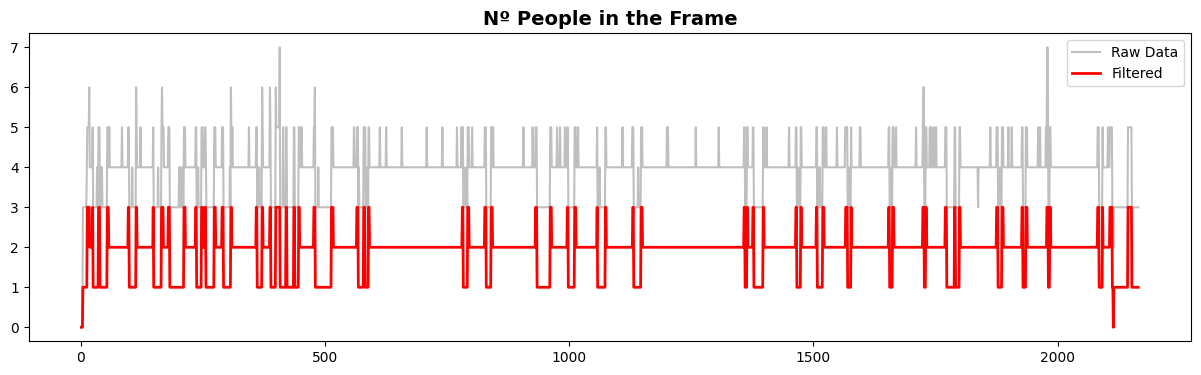

In [18]:
df_visual = pd.read_pickle("cleaned_features/Cotrim_Figueiredo_vs_Ventura_December_19_visual.pkl")
plt.figure(figsize=(15, 4))
plt.plot(df_visual.index, df_visual['total_person_count'], label='Raw Data', color='grey', alpha=0.5)
plt.plot(df_visual.index, df_visual['valid_person_count'], label='Filtered', color='red', linewidth=2)
plt.title("Nº People in the Frame", fontsize=14, fontweight='bold')
plt.legend()
plt.show()

# Debug Visual Frame

Imagem não encontrada: frames_files/Cotrim_Figueiredo_vs_Ventura_December_19/frame_479.jpg


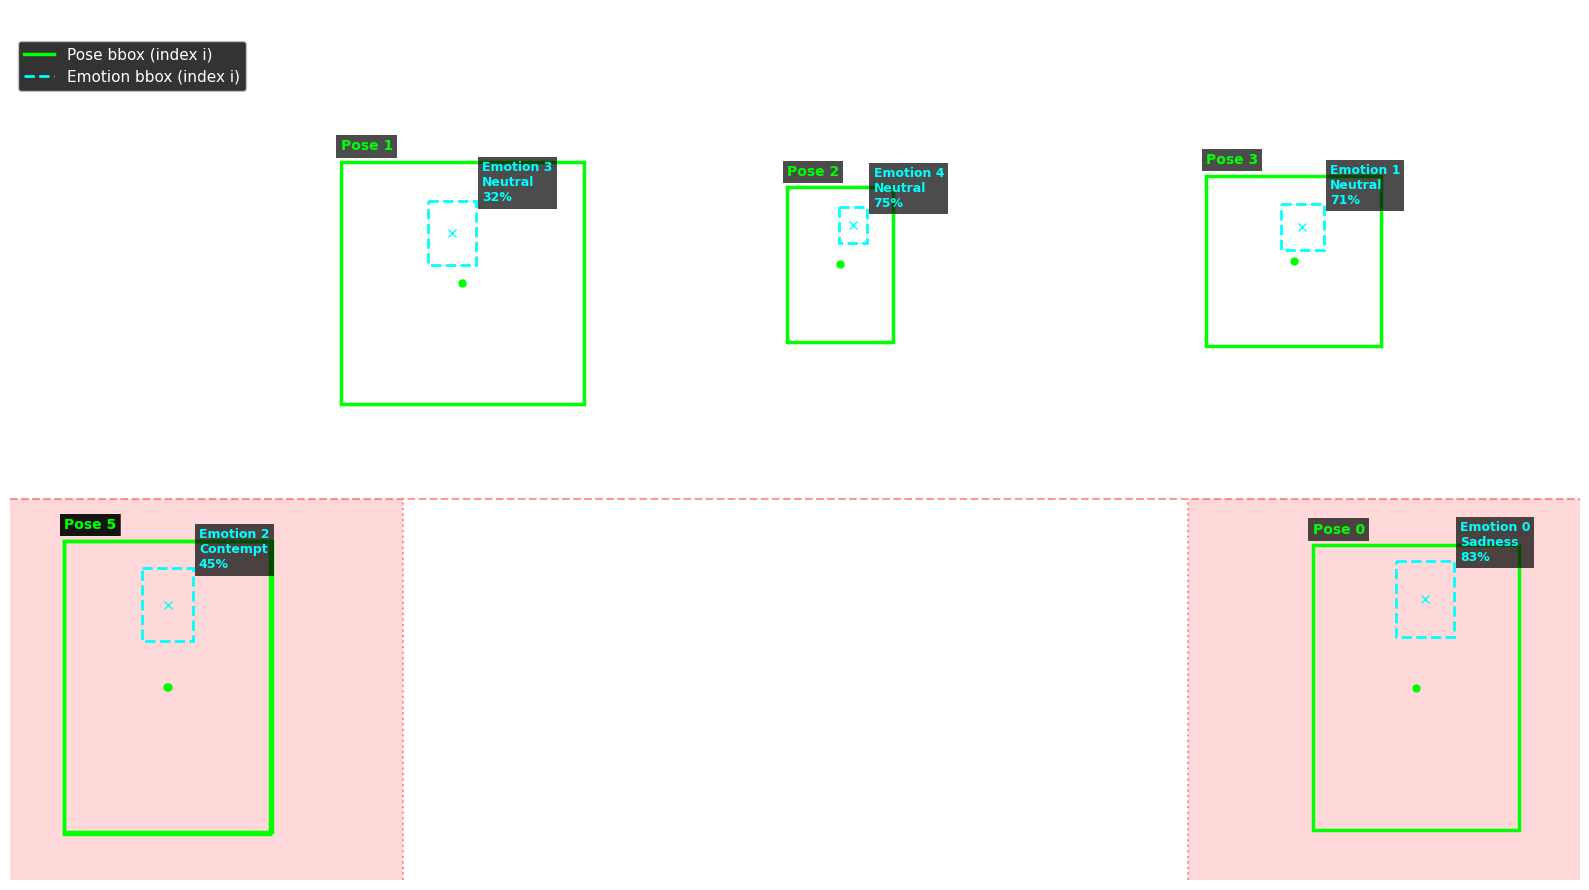


i     Pose bbox                           Emotion bbox                        Emotion
----------------------------------------------------------------------------------------------------
0     [1062.0319   435.47726 1230.0103   677.8298 ] [np.int64(1130), np.int64(449), np.int64(1177), np.int64(513)] Sadness
1     [269.51785 109.571   467.85492 315.46585] [np.int64(1036), np.int64(145), np.int64(1071), np.int64(184)] Neutral
2     [633.2589  131.04536 719.6316  262.07968] [np.int64(108), np.int64(455), np.int64(149), np.int64(517)] Contempt
3     [ 974.9397   121.25046 1117.9889   265.84677] [np.int64(341), np.int64(143), np.int64(380), np.int64(197)] Neutral
4     [ 43.812996 431.62357  213.78769  679.3004  ] [np.int64(676), np.int64(148), np.int64(699), np.int64(178)] Neutral
5     [ 44.364616 431.72168  212.21176  680.58575 ] MISSING                             MISSING


In [19]:
frame_alvo = 479
pasta_imagens = 'frames_files/Cotrim_Figueiredo_vs_Ventura_December_19/'
caminho_imagem = os.path.join(pasta_imagens, f'frame_{frame_alvo:03d}.jpg')


poses_do_frame = df_visual.loc[frame_alvo, 'Poses']
fer_do_frame   = df_visual.loc[frame_alvo, 'Fer']  # Use the cleaned FER detections

IMG_WIDTH  = 1280
IMG_HEIGHT = 720
Y_CUTOFF    = IMG_HEIGHT * 0.55
LEFT_ZONE   = IMG_WIDTH  * 0.25
RIGHT_ZONE  = IMG_WIDTH  * 0.75


fig, ax = plt.subplots(1, figsize=(16, 9))
ax.set_facecolor('#222222')

try:
    img = plt.imread(caminho_imagem)
    ax.imshow(img)
except FileNotFoundError:
    print(f"Imagem não encontrada: {caminho_imagem}")
    ax.set_xlim(0, IMG_WIDTH)
    ax.set_ylim(IMG_HEIGHT, 0)

#apply zones
ax.add_patch(patches.Rectangle((0, Y_CUTOFF), LEFT_ZONE, IMG_HEIGHT - Y_CUTOFF,
                                linewidth=0, facecolor='red', alpha=0.15))
ax.add_patch(patches.Rectangle((RIGHT_ZONE, Y_CUTOFF), IMG_WIDTH - RIGHT_ZONE, IMG_HEIGHT - Y_CUTOFF,
                                linewidth=0, facecolor='red', alpha=0.15))
ax.axhline(Y_CUTOFF, color='red', linestyle='--', alpha=0.4, label='Y Cutoff')
ax.axvline(LEFT_ZONE,  ymin=0, ymax=1 - (Y_CUTOFF / IMG_HEIGHT), color='red', linestyle=':', alpha=0.4)
ax.axvline(RIGHT_ZONE, ymin=0, ymax=1 - (Y_CUTOFF / IMG_HEIGHT), color='red', linestyle=':', alpha=0.4)


if isinstance(poses_do_frame, list):
    for i, person in enumerate(poses_do_frame):
        if isinstance(person, dict) and 'bbox' in person:
            x1, y1, x2, y2 = person['bbox']
            w, h = x2 - x1, y2 - y1
            center_x, center_y = x1 + w / 2, y1 + h / 2

            ax.add_patch(patches.Rectangle((x1, y1), w, h,
                                           linewidth=2.5, edgecolor='lime', facecolor='none',
                                           linestyle='-'))
            ax.plot(center_x, center_y, marker='o', color='lime', markersize=5)
            ax.text(x1, y1 - 10, f"Pose {i}", color='lime', fontsize=10, fontweight='bold',
                    bbox=dict(facecolor='black', alpha=0.7, edgecolor='none', pad=3))
else:
    print("poses_do_frame is not a list — check column structure.")


if isinstance(fer_do_frame, list):
    for i, face in enumerate(fer_do_frame):
        if isinstance(face, dict) and 'bbox' in face:
            x1, y1, x2, y2 = face['bbox']
            w, h = x2 - x1, y2 - y1
            center_x, center_y = x1 + w / 2, y1 + h / 2
            emotion = face.get('top_emotion', '?')
            conf    = face['probabilities'].get(emotion, 0) if 'probabilities' in face else 0

            ax.add_patch(patches.Rectangle((x1, y1), w, h,
                                           linewidth=2, edgecolor='cyan', facecolor='none',
                                           linestyle='--'))
            ax.plot(center_x, center_y, marker='x', color='cyan', markersize=6)
            ax.text(x2 + 5, y1, f"Emotion {i}\n{emotion}\n{conf:.0%}",
                    color='cyan', fontsize=9, fontweight='bold',
                    bbox=dict(facecolor='black', alpha=0.7, edgecolor='none', pad=3))
else:
    print("fer_do_frame is not a list — check column structure.")

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='lime', linewidth=2.5, label='Pose bbox (index i)'),
    Line2D([0], [0], color='cyan', linewidth=2, linestyle='--', label='Emotion bbox (index i)'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=11,
          facecolor='black', labelcolor='white')

plt.title(f"Pose + FER Debugger: Frame {frame_alvo}  "
          f"({len(poses_do_frame) if isinstance(poses_do_frame, list) else 0} poses, "
          f"{len(fer_do_frame) if isinstance(fer_do_frame, list) else 0} faces)",
          fontsize=14, fontweight='bold', color='white')
plt.axis('off')
plt.tight_layout()
plt.show()


print(f"\n{'i':<5} {'Pose bbox':<35} {'Emotion bbox':<35} {'Emotion'}")
print("-" * 100)
n = max(
    len(poses_do_frame) if isinstance(poses_do_frame, list) else 0,
    len(fer_do_frame)   if isinstance(fer_do_frame,   list) else 0
)
for i in range(n):
    pose_bbox = poses_do_frame[i]['bbox'] if isinstance(poses_do_frame, list) and i < len(poses_do_frame) else "MISSING"
    fer_entry = fer_do_frame[i]           if isinstance(fer_do_frame,   list) and i < len(fer_do_frame)   else None
    fer_bbox  = fer_entry['bbox']         if isinstance(fer_entry, dict) else "MISSING"
    emotion   = fer_entry.get('top_emotion', '?') if isinstance(fer_entry, dict) else "MISSING"
    print(f"{i:<5} {str(pose_bbox):<35} {str(fer_bbox):<35} {emotion}")

# emotion vs pitch boxplot 

df_merged built: 53 speaker-attributed segments with emotion + acoustics


/tmp/claude-0/ipykernel_2475/3048307910.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


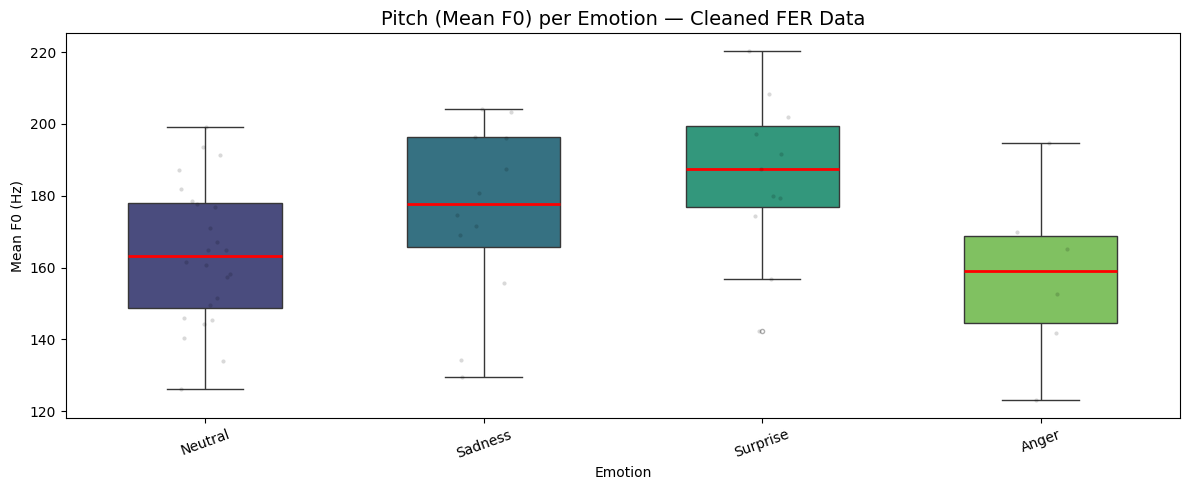

In [20]:
# Build df_merged: align each audio segment to the on-screen emotion of the
# *speaking* participant (the face on the same side the camera shows them on).
_vis = df_visual                                   # cleaned visual (index = frame_idx ~ seconds)
_aud = df_audio.dropna(subset=['meanF0Hz']).reset_index(drop=True)

_solo = {idx: ('L' if (p[0]['bbox'][0] + p[0]['bbox'][2]) / 2 < 640 else 'R')
         for idx, p in _vis['valid_poses'].items() if isinstance(p, list) and len(p) == 1}
_face = {}
for idx, fl in _vis['valid_fer'].items():
    d = {}
    if isinstance(fl, list):
        for f in fl:
            if isinstance(f, dict) and 'top_emotion' in f and 'bbox' in f:
                s = 'L' if (f['bbox'][0] + f['bbox'][2]) / 2 < 640 else 'R'
                d[s] = f['top_emotion']
    _face[idx] = d

_rows = []
for _, seg in _aud.iterrows():
    t0 = seg['time stamp']
    secs = range(int(round(t0)), int(round(t0 + seg['duration'])) + 1)
    sides = [_solo[x] for x in secs if x in _solo]
    side = ('L' if sides.count('L') >= sides.count('R') else 'R') if sides else None
    emos = [_face[x][side] for x in secs if x in _face and side in _face[x]]
    if emos:
        _rows.append({'emotion': Counter(emos).most_common(1)[0][0],
                      'meanF0Hz': seg['meanF0Hz'],
                      'speechrate': seg['speechrate'],
                      'articulationrate': seg['articulationrate']})
df_merged = pd.DataFrame(_rows)
print(f"df_merged built: {len(df_merged)} speaker-attributed segments with emotion + acoustics")


emotion_order = df_merged['emotion'].value_counts().index.tolist()
palette       = dict(zip(emotion_order, sns.color_palette('viridis', len(emotion_order))))

plt.figure(figsize=(12, 5))
sns.boxplot(
    data=df_merged,
    x='emotion', y='meanF0Hz',
    order=emotion_order,
    palette=palette,
    width=0.55,
    flierprops=dict(marker='o', markersize=3, alpha=0.4),
    medianprops=dict(color='red', linewidth=2),
)
sns.stripplot(
    data=df_merged,
    x='emotion', y='meanF0Hz',
    order=emotion_order,
    color='black', alpha=0.15, size=3, jitter=True
)
plt.title('Pitch (Mean F0) per Emotion — Cleaned FER Data', fontsize=14)
plt.xlabel('Emotion')
plt.ylabel('Mean F0 (Hz)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# emotion vs speaking rate boxplot

/tmp/claude-0/ipykernel_2475/1809467526.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


/tmp/claude-0/ipykernel_2475/1809467526.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


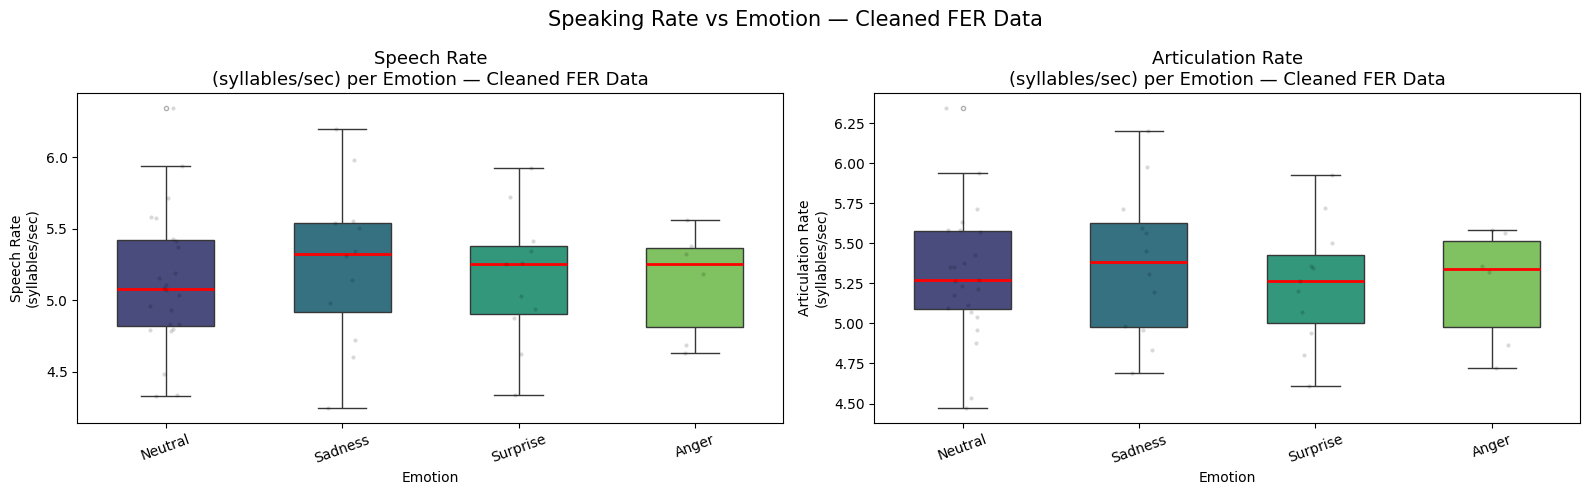

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, col, label in zip(
    axes,
    ['speechrate',       'articulationrate'],
    ['Speech Rate\n(syllables/sec)', 'Articulation Rate\n(syllables/sec)']
):
    sns.boxplot(
        data=df_merged,
        x='emotion', y=col,
        order=emotion_order,
        palette=palette,
        width=0.55,
        flierprops=dict(marker='o', markersize=3, alpha=0.4),
        medianprops=dict(color='red', linewidth=2),
        ax=ax
    )
    sns.stripplot(
        data=df_merged,
        x='emotion', y=col,
        order=emotion_order,
        color='black', alpha=0.15, size=3, jitter=True,
        ax=ax
    )
    ax.set_title(f'{label} per Emotion — Cleaned FER Data', fontsize=13)
    ax.set_xlabel('Emotion')
    ax.set_ylabel(label)
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Speaking Rate vs Emotion — Cleaned FER Data', fontsize=15)
plt.tight_layout()
plt.show()

# Emotion histogram 

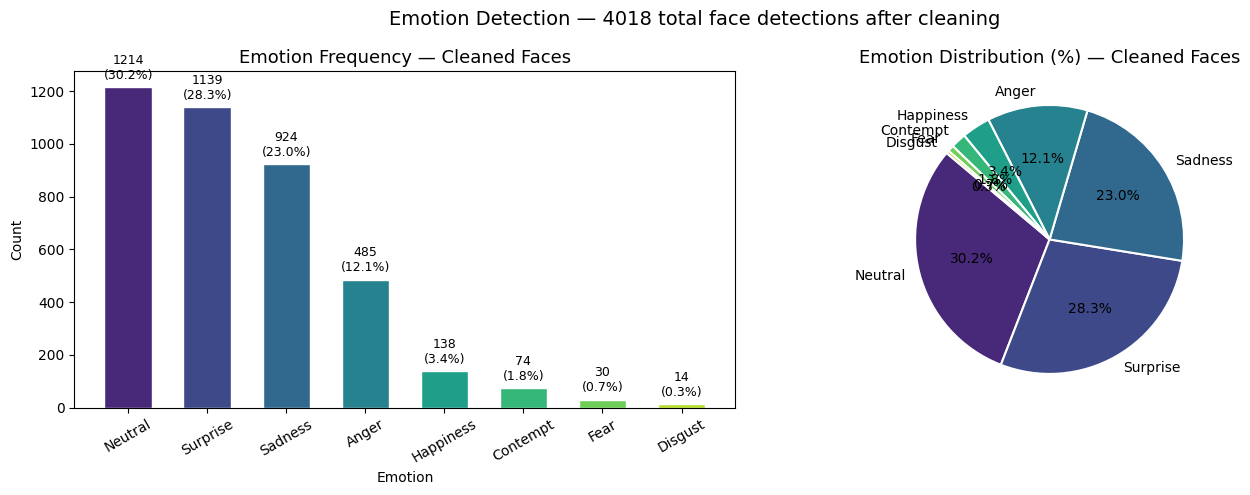


Total detections: 4018
           count   pct
Neutral     1214  30.2
Surprise    1139  28.3
Sadness      924  23.0
Anger        485  12.1
Happiness    138   3.4
Contempt      74   1.8
Fear          30   0.7
Disgust       14   0.3


In [22]:
all_emotions = []
for fer_list in df_visual['valid_fer'].dropna():
    if isinstance(fer_list, list):
        for face in fer_list:
            if isinstance(face, dict) and 'top_emotion' in face:
                all_emotions.append(face['top_emotion'])

emotion_counts = pd.Series(all_emotions).value_counts()
total          = len(all_emotions)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


bars = axes[0].bar(emotion_counts.index, emotion_counts.values,
                   color=sns.color_palette('viridis', len(emotion_counts)),
                   edgecolor='white', width=0.6)
axes[0].set_title('Emotion Frequency — Cleaned Faces', fontsize=13)
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)
# add count labels on top of each bar
for bar, count in zip(bars, emotion_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + total * 0.005,
                 f'{count}\n({count/total*100:.1f}%)',
                 ha='center', va='bottom', fontsize=9)

#  Pie chart 
axes[1].pie(
    emotion_counts.values,
    labels=emotion_counts.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('viridis', len(emotion_counts)),
    startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
axes[1].set_title('Emotion Distribution (%) — Cleaned Faces', fontsize=13)

plt.suptitle(f'Emotion Detection — {total} total face detections after cleaning', fontsize=14)
plt.tight_layout()
plt.show()

# quick summary printout
print(f"\nTotal detections: {total}")
print(emotion_counts.rename('count').to_frame()
      .assign(pct=lambda d: (d['count'] / total * 100).round(1)))


# TASK 2

In [1]:
# Setup - imports, paths, candidates and helpers
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import re, os, math, pywt
from collections import Counter, defaultdict
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score
import umap

sns.set_style("whitegrid")

FEAT_DIR  = "Project_Features/"
CLEAN_DIR = "cleaned_features/"
os.makedirs(CLEAN_DIR, exist_ok=True)

IMG_WIDTH, IMG_HEIGHT = 1280, 720

DEBATE   = "Seguro_vs_Filipe_December_19"
NEWSCAST = "Telejornal_RTP_Dec_2"

CANDIDATES = ['Cotrim_Figueiredo', 'Gouveia_Melo', 'Marques_Mendes', 'Martins',
              'Filipe', 'Pinto', 'Seguro', 'Ventura']

MONTH_DAY0 = {'October': 0, 'November': 31, 'December': 61, 'January': 92}

def day_number(month, day):
    return MONTH_DAY0[month] + (day - 1)

def parse_debate_name(name):

    name = re.sub(r'_(audio|speech|visual)$', '', name)
    m = re.search(r'_(October|November|December|January)_(\d+)$', name)
    month, day = m.group(1), int(m.group(2))
    cand_a, cand_b = name[:m.start()].split('_vs_')
    return cand_a, cand_b, month, day, day_number(month, day)

def which_side(bbox):

    x1, y1, x2, y2 = bbox
    return 'L' if (x1 + x2) / 2 < IMG_WIDTH / 2 else 'R'

def save_table(df, filename):

    path = os.path.join(CLEAN_DIR, filename)
    df.to_pickle(path)
    print(f"  saved -> {path}   ({df.shape[0]} rows x {df.shape[1]} cols)")

print("Debate :", DEBATE)
print("Newscast:", NEWSCAST)

Debate : Seguro_vs_Filipe_December_19
Newscast: Telejornal_RTP_Dec_2


# Debate: segmenting the video into moments by shot

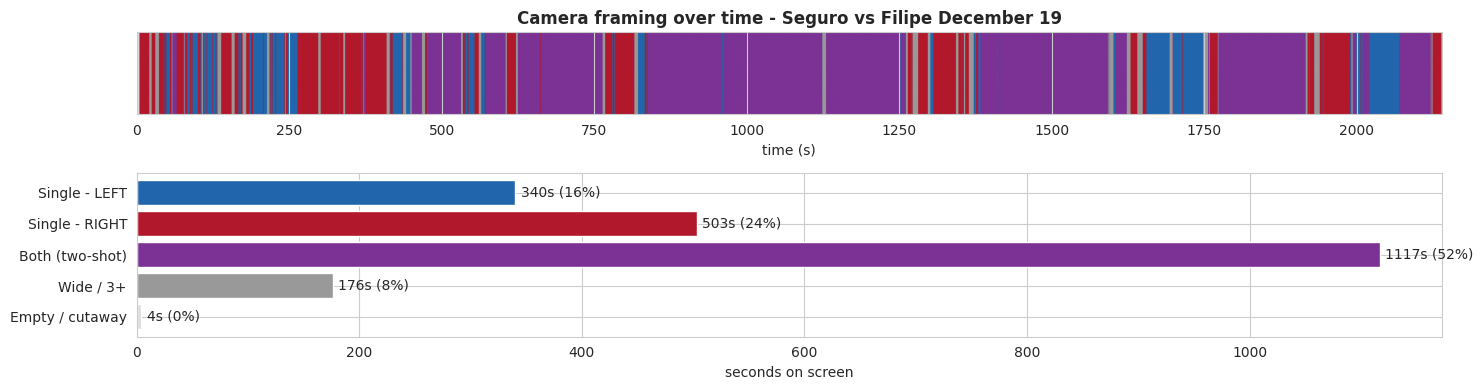

Solo screen time -> LEFT 340s vs RIGHT 503s
Both on screen: 1117s
  saved -> cleaned_features/Seguro_vs_Filipe_December_19_moments.pkl   (2140 rows x 2 cols)


In [2]:
# 2.1 - Moment segmentation (who is on screen each second)
df_visual = pd.read_pickle(CLEAN_DIR + DEBATE + "_visual.pkl")

def label_scene(row):
    n = row['valid_poses_count']
    if n == 0:
        return 'Empty / cutaway'
    if n == 1:
        side = which_side(row['valid_poses'][0]['bbox'])
        return 'Single - LEFT' if side == 'L' else 'Single - RIGHT'
    if n == 2:
        return 'Both (two-shot)'
    return 'Wide / 3+'

df_visual['scene'] = df_visual.apply(label_scene, axis=1)

scene_order  = ['Single - LEFT', 'Single - RIGHT', 'Both (two-shot)', 'Wide / 3+', 'Empty / cutaway']
scene_colour = ['#2166ac', '#b2182b', '#7b3294', '#999999', '#dddddd']
seconds_per_scene = df_visual['scene'].value_counts().reindex(scene_order).fillna(0).astype(int)
total_seconds = len(df_visual)

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(15, 4),
                                     gridspec_kw={'height_ratios': [1, 2]})
scene_to_code = {s: i for i, s in enumerate(scene_order)}
timeline = df_visual['scene'].map(scene_to_code).values[np.newaxis, :]
ax_top.imshow(timeline, aspect='auto', cmap=mpl.colors.ListedColormap(scene_colour),
              vmin=0, vmax=len(scene_order) - 1, extent=[0, total_seconds, 0, 1])
ax_top.set_yticks([]); ax_top.set_xlabel('time (s)')
ax_top.set_title(f'Camera framing over time - {DEBATE.replace("_", " ")}', fontweight='bold')

ax_bot.barh(scene_order, seconds_per_scene.values, color=scene_colour)
for i, value in enumerate(seconds_per_scene.values):
    ax_bot.text(value + 5, i, f'{value}s ({value/total_seconds*100:.0f}%)', va='center')
ax_bot.invert_yaxis(); ax_bot.set_xlabel('seconds on screen')
plt.tight_layout(); plt.show()

left_solo  = seconds_per_scene['Single - LEFT']
right_solo = seconds_per_scene['Single - RIGHT']
print(f"Solo screen time -> LEFT {left_solo}s vs RIGHT {right_solo}s")
print(f"Both on screen: {seconds_per_scene['Both (two-shot)']}s")

moments = df_visual[['scene', 'valid_poses_count']].copy()
save_table(moments, f"{DEBATE}_moments.pkl")

# How many speakers, and labelling them

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


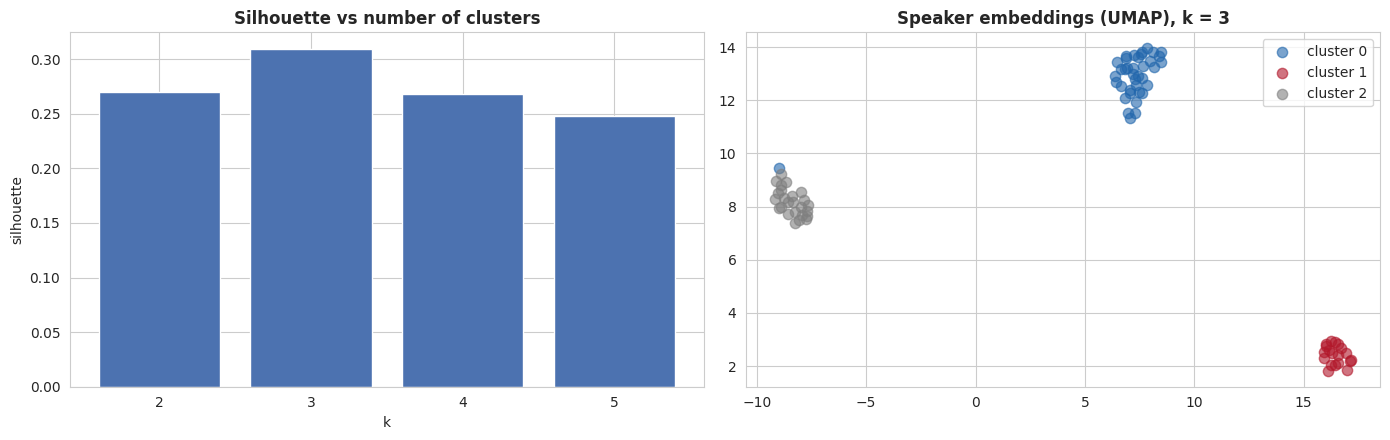

silhouette: {2: 0.27, 3: 0.309, 4: 0.268, 5: 0.248}


In [3]:
# 2.2 - Cluster the three voices (silhouette + KMeans k=3 + UMAP)
df_audio = pd.read_pickle(FEAT_DIR + DEBATE + "_audio.pkl").dropna(subset=['speak_embeddings'])
df_audio = df_audio.reset_index(drop=True)
embeddings = normalize(np.vstack(df_audio['speak_embeddings'].values))

silhouette = {}
for k in range(2, 6):
    labels_k = KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(embeddings)
    silhouette[k] = silhouette_score(embeddings, labels_k)

kmeans = KMeans(n_clusters=3, n_init=10, random_state=42).fit(embeddings)
df_audio['cluster'] = kmeans.labels_
embedding_2d = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(embeddings)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))
ax1.bar([str(k) for k in silhouette], list(silhouette.values()), color='#4C72B0')
ax1.set_title('Silhouette vs number of clusters', fontweight='bold')
ax1.set_xlabel('k'); ax1.set_ylabel('silhouette')
for cluster, colour in zip(range(3), ['#2166ac', '#b2182b', '#7f7f7f']):
    mask = df_audio['cluster'] == cluster
    ax2.scatter(embedding_2d[mask, 0], embedding_2d[mask, 1], s=55, alpha=0.6, color=colour, label=f'cluster {cluster}')
ax2.set_title('Speaker embeddings (UMAP), k = 3', fontweight='bold'); ax2.legend()
plt.tight_layout(); plt.show()
print("silhouette:", {k: round(v, 3) for k, v in silhouette.items()})

role                voice   solo L / R
  Person 1 (LEFT)       870s   300 / 45
  Person 2 (RIGHT)      928s   29 / 283
  Moderator             321s   28 / 176


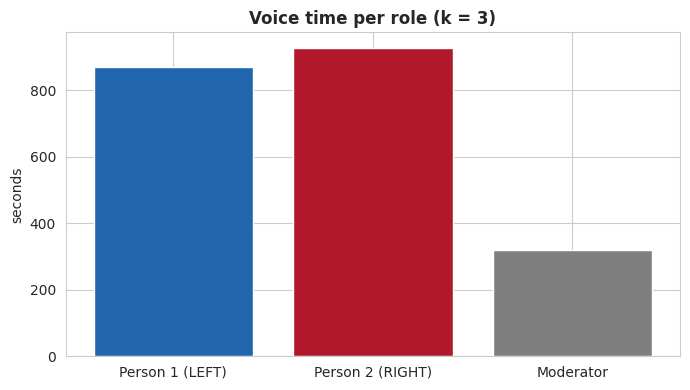

  saved -> cleaned_features/Seguro_vs_Filipe_December_19_speaker_segments.pkl   (82 rows x 7 cols)


In [4]:
# 2.2 - Map voice clusters to screen side; identify the moderator
solo_side = {}
for frame, row in df_visual.iterrows():
    if row['valid_poses_count'] == 1:
        solo_side[frame] = which_side(row['valid_poses'][0]['bbox'])

side_counts = {c: {'L': 0, 'R': 0} for c in range(3)}
for _, seg in df_audio.iterrows():
    for second in range(int(round(seg['time stamp'])), int(round(seg['time stamp'] + seg['duration'])) + 1):
        if second in solo_side:
            side_counts[seg['cluster']][solo_side[second]] += 1

left_cluster  = max(range(3), key=lambda c: side_counts[c]['L'])
right_cluster = max((c for c in range(3) if c != left_cluster), key=lambda c: side_counts[c]['R'])
moderator     = next(c for c in range(3) if c not in (left_cluster, right_cluster))

role = {left_cluster: 'Person 1 (LEFT)', right_cluster: 'Person 2 (RIGHT)', moderator: 'Moderator'}
df_audio['role'] = df_audio['cluster'].map(role)
df_audio['screen_side'] = df_audio['cluster'].map({left_cluster: 'L', right_cluster: 'R', moderator: None})

print("role                voice   solo L / R")
for cluster in [left_cluster, right_cluster, moderator]:
    seconds = df_audio.loc[df_audio['cluster'] == cluster, 'duration'].sum()
    print(f"  {role[cluster]:18s} {seconds:6.0f}s   {side_counts[cluster]['L']} / {side_counts[cluster]['R']}")

voice_time = df_audio.groupby('role')['duration'].sum()
order = ['Person 1 (LEFT)', 'Person 2 (RIGHT)', 'Moderator']
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(order, [voice_time.get(r, 0) for r in order], color=['#2166ac', '#b2182b', '#7f7f7f'])
ax.set_ylabel('seconds'); ax.set_title('Voice time per role (k = 3)', fontweight='bold')
plt.tight_layout(); plt.show()

speaker_segments = df_audio[['time stamp', 'duration', 'cluster', 'role', 'screen_side', 'meanF0Hz', 'speechrate']].copy()
save_table(speaker_segments, f"{DEBATE}_speaker_segments.pkl")

# Debate: audio <-> emotion

/tmp/ipykernel_1740/733293912.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_emotion, x='emotion', y=column, order=emotion_order,
/tmp/ipykernel_1740/733293912.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_emotion, x='emotion', y=column, order=emotion_order,


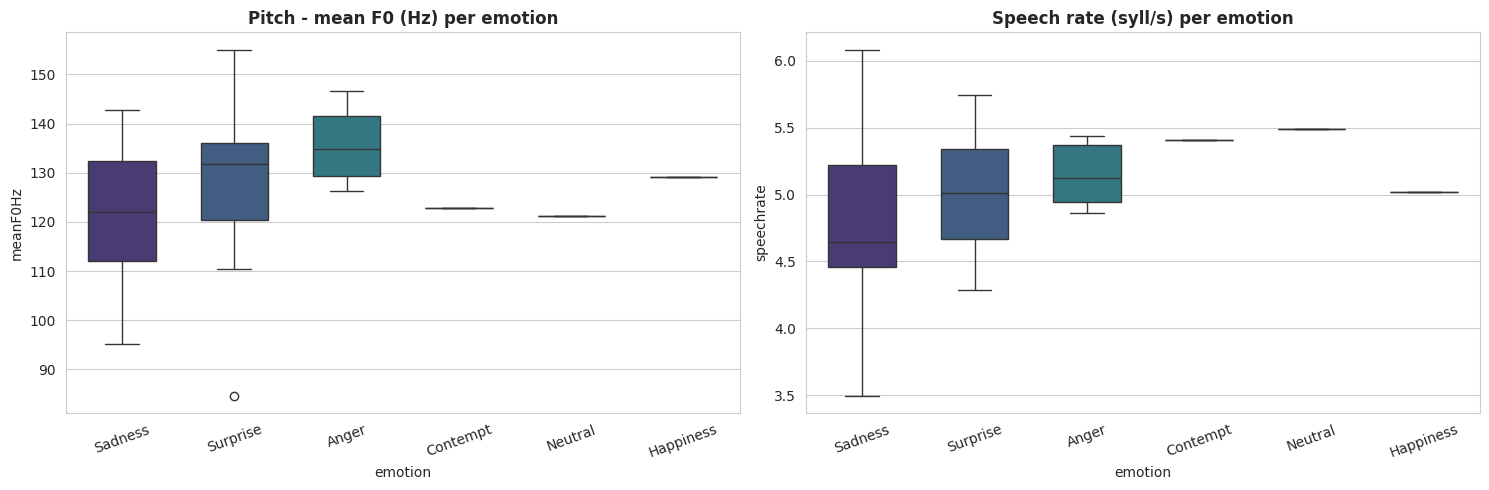

emotion
Anger        135.6
Contempt     122.8
Happiness    129.2
Neutral      121.1
Sadness      122.3
Surprise     128.9


In [5]:
# 2.3 - Audio vs the speaking person's emotion
side_emotion = {}
for frame, faces in df_visual['valid_fer'].items():
    found = {}
    if isinstance(faces, list):
        for face in faces:
            if isinstance(face, dict) and 'top_emotion' in face:
                found[which_side(face['bbox'])] = face['top_emotion']
    side_emotion[frame] = found

rows = []
for _, seg in df_audio.iterrows():
    side = seg['screen_side']
    seconds = range(int(round(seg['time stamp'])), int(round(seg['time stamp'] + seg['duration'])) + 1)
    emotions = [side_emotion[s][side] for s in seconds if s in side_emotion and side in side_emotion[s]]
    if emotions:
        rows.append({'emotion': Counter(emotions).most_common(1)[0][0],
                     'meanF0Hz': seg['meanF0Hz'],
                     'speechrate': seg['speechrate']})
df_emotion = pd.DataFrame(rows)
emotion_order = df_emotion['emotion'].value_counts().index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, column, label in zip(axes, ['meanF0Hz', 'speechrate'],
                             ['Pitch - mean F0 (Hz)', 'Speech rate (syll/s)']):
    sns.boxplot(data=df_emotion, x='emotion', y=column, order=emotion_order,
                palette='viridis', width=0.6, ax=ax)
    ax.set_title(f'{label} per emotion', fontweight='bold')
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()
print(df_emotion.groupby('emotion')['meanF0Hz'].mean().round(1).to_string())

# Newscast: anchor → news transitions 

In [ ]:

df_ocr = pd.read_pickle(FEAT_DIR + NEWSCAST + "_ocr.pkl")
df_ocr['frame'] = df_ocr['Frame'].str.extract(r'frame_(\d+)').astype(int)
df_ocr = df_ocr.sort_values('frame').set_index('frame')

LOCATION = re.compile(r'\b(DIRETO|WASHINGTON|MOSCOVO|BUENOS AIRES|KIEV|BRUXELAS|MADRID|PARIS|'
                      r'LONDRES|GAZA|JERUSAL|ROMA|VATICANO|ABU DHABI|POKROVSK)\b', re.I)
ROLE     = re.compile(r'\b(Dir\.|Diretor|Jornalista|Rep[oó]rter|Comentador|Ministr|Secret[aá]ri|'
                      r'Coordenador|Analista|Enviad|Correspondente)\b', re.I)
ENGLISH_NOISE = set('THE OF AND PARTY PROPERTY STATE OWNERS ADDRESS REAL'.split())

def read_boxes(cell):
    if not isinstance(cell, (list, np.ndarray)):
        return []
    boxes = []
    for box in cell:
        if isinstance(box, dict) and 'text' in box:
            text = re.sub('<[^>]+>', '', str(box['text'])).strip()
            boxes.append((text, float(box.get('conf', 0))))
    return boxes

def find_headline(boxes):
    candidates = []
    for text, conf in boxes:
        letters = re.sub(r'[^A-Za-zÀ-ÿ ]', '', text)
        if conf >= 0.6 and len(letters.replace(' ', '')) >= 10:
            uppercase = sum(ch.isupper() for ch in letters)
            lowercase = sum(ch.islower() for ch in letters)
            words = set(text.upper().split())
            if uppercase >= lowercase and not (words and words <= ENGLISH_NOISE):
                candidates.append((len(letters), text.upper().strip()))
    return sorted(candidates)[-1][1] if candidates else None

def is_field_frame(boxes):
    return any(LOCATION.search(t) or ROLE.search(t) for t, c in boxes if c > 0.5)

df_ocr['boxes']    = df_ocr['OCR'].apply(read_boxes)
df_ocr['headline'] = df_ocr['boxes'].apply(find_headline)
df_ocr['field']    = df_ocr['boxes'].apply(is_field_frame)
print(f"{len(df_ocr)} frames | headline present {df_ocr['headline'].notna().mean()*100:.0f}% | "
      f"field frames {df_ocr['field'].mean()*100:.0f}%")

2885 frames | headline present 87% | field frames 16%


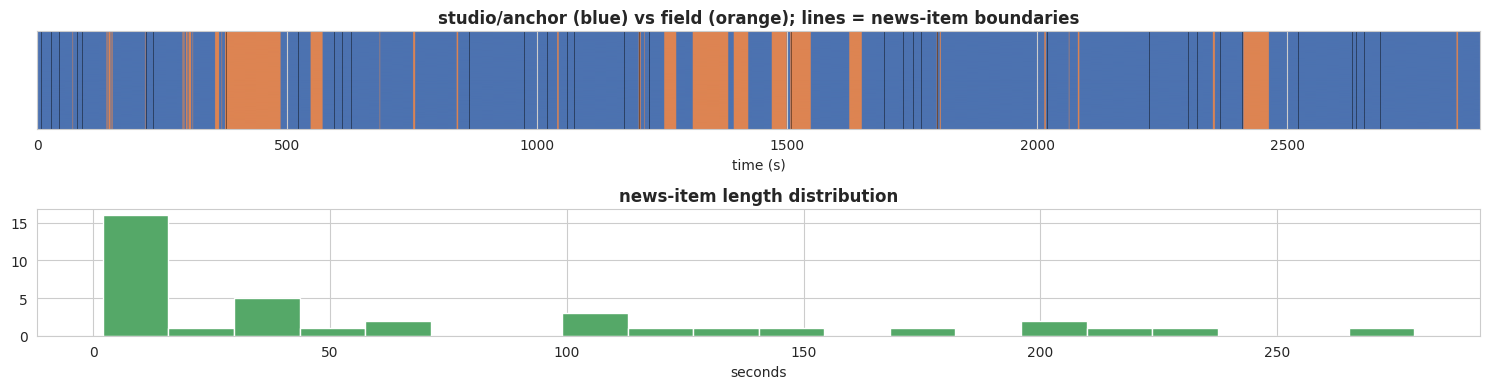

37 news items | median length 31s

longest items:
   279s  field= 55%  PRESIDENTE DOS EUA DIZ QUE NÃO É FÁCIL DE RESOLVER
   227s  field=  4%  RISCO DE INFEÇÃO É BAIXO MAS ESTÁ SOB VIGILÂNCIA
   214s  field=  2%  EX-CHEFE DA DIPLOMACIA EUROPEIA SUSPEITA DE FRAUDE
   200s  field=  2%  TRABALHADORES DA AUTOEUROPA ADEREM À PARALISAÇÃO
   200s  field=  1%  SEGURO FAZ APELO À "RESPONSABILIDADE" DA ESQUERDA
   177s  field= 37%  PAPA APELA A TRUMP QUE NÃO USE FORÇA CONTRA MADURO
   142s  field= 15%  AND THE PROPERTY OF THE PARTY OF THE PARTY OF THE PARTY
   139s  field= 79%  ADIADAS VISITAS OFICIAIS A ESPANHA E AO VATICANO
  saved -> cleaned_features/Telejornal_RTP_Dec_2_news_items.pkl   (37 rows x 5 cols)


In [ ]:
banner = df_ocr['headline'].ffill(limit=5)

runs = []
current, start, previous = None, None, None
for frame, text in banner.items():
    if text != current:
        if current is not None:
            runs.append([current, start, previous])
        current, start = text, frame
    previous = frame
if current is not None:
    runs.append([current, start, previous])
runs = [r for r in runs if isinstance(r[0], str) and (r[2] - r[1]) >= 2]

STOPWORDS = set('DE DA DO DOS DAS E A O QUE EM NO NA UMA UM PARA COM POR SE AO OS AS NÃO'.split())
def keywords(text):
    return {w for w in re.findall(r'[A-ZÀ-Ý]{3,}', text) if w not in STOPWORDS}

stories = []
for headline, start, end in runs:
    if stories:
        prev_headline, prev_start, prev_end = stories[-1]
        gap = start - prev_end
        same_story = gap <= 8 and (keywords(headline) & keywords(prev_headline) or gap <= 3)
        if same_story:
            stories[-1] = [prev_headline if len(prev_headline) >= len(headline) else headline,
                           prev_start, end]
            continue
    stories.append([headline, start, end])

news_items = pd.DataFrame([{'headline': h, 'start_s': s, 'end_s': e, 'length_s': e - s,
                            'field_pct': round(df_ocr.loc[s:e, 'field'].mean() * 100)}
                           for h, s, e in stories])

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(15, 4), gridspec_kw={'height_ratios': [1, 1.3]})
ax_top.imshow(df_ocr['field'].astype(int).values[np.newaxis, :], aspect='auto',
              cmap=mpl.colors.ListedColormap(['#4C72B0', '#dd8452']), vmin=0, vmax=1,
              extent=[0, len(df_ocr), 0, 1])
for _, item in news_items.iterrows():
    ax_top.axvline(item['start_s'], color='black', lw=0.6, alpha=0.5)
ax_top.set_yticks([]); ax_top.set_xlabel('time (s)')
ax_top.set_title('studio/anchor (blue) vs field (orange); lines = news-item boundaries', fontweight='bold')
ax_bot.hist(news_items['length_s'], bins=20, color='#55a868', edgecolor='white')
ax_bot.set_title('news-item length distribution', fontweight='bold'); ax_bot.set_xlabel('seconds')
plt.tight_layout(); plt.show()

print(f"{len(news_items)} news items | median length {news_items['length_s'].median():.0f}s")
print("\nlongest items:")
for _, item in news_items.sort_values('length_s', ascending=False).head(8).iterrows():
    print(f"  {item['length_s']:4d}s  field={item['field_pct']:3d}%  {item['headline'][:55]}")
save_table(news_items, f"{NEWSCAST}_news_items.pkl")

-----------

# Themes across the campaign

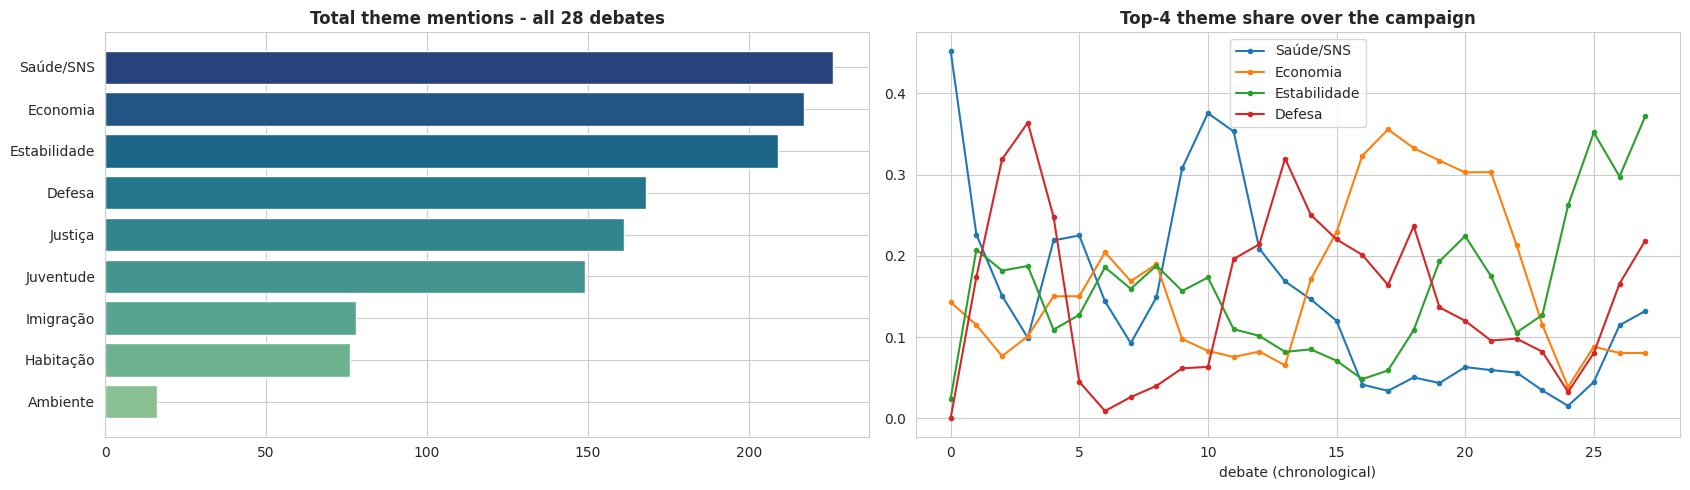

ranking: {'Saúde/SNS': 226, 'Economia': 217, 'Estabilidade': 209, 'Defesa': 168, 'Justiça': 161, 'Juventude': 149, 'Imigração': 78, 'Habitação': 76, 'Ambiente': 16}
  saved -> cleaned_features/debate_themes.pkl   (28 rows x 11 cols)


In [ ]:
THEMES = {
    'Estabilidade': ['estabilidade', 'dissolução', 'parlamento', 'governabilidade', 'compromisso', 'moderação', 'política'],
    'Saúde/SNS':    ['sns', 'saúde', 'médicos', 'urgências', 'hospitais', 'hospital', 'utentes'],
    'Habitação':    ['habitação', 'rendas', 'casa', 'imobiliário', 'arrendamento', 'construção'],
    'Imigração':    ['imigração', 'imigrantes', 'fronteiras', 'nacionalidade', 'estrangeiros', 'integração'],
    'Economia':     ['economia', 'inflação', 'salários', 'impostos', 'crescimento', 'fiscal', 'económico'],
    'Defesa':       ['defesa', 'forças armadas', 'nato', 'guerra', 'militar', 'armamento', 'marinha'],
    'Juventude':    ['jovens', 'juventude', 'emigração', 'precariedade', 'futuro'],
    'Justiça':      ['justiça', 'corrupção', 'tribunais', 'ministério público', 'impunidade'],
    'Ambiente':     ['ambiente', 'clima', 'climáticas', 'incêndios', 'sustentabilidade'],
}
THEME_NAMES = list(THEMES)

def count_themes(text):
    text = text.lower()
    counts = {}
    for theme, words in THEMES.items():
        counts[theme] = sum(len(re.findall(r'\b' + re.escape(w) + r'\b', text)) for w in words)
    return counts

debate_speech_files = sorted(f for f in os.listdir(FEAT_DIR)
                             if f.endswith('_speech.pkl') and 'Telejornal' not in f)

theme_rows = []
for filename in debate_speech_files:
    cand_a, cand_b, month, day, day_no = parse_debate_name(filename.replace('_speech.pkl', ''))
    transcript = ' '.join(pd.read_pickle(FEAT_DIR + filename)['transcript'].dropna().astype(str))
    row = count_themes(transcript)
    row['debate'] = filename.replace('_speech.pkl', '')
    row['day'] = day_no
    theme_rows.append(row)

debate_themes = pd.DataFrame(theme_rows).sort_values('day').reset_index(drop=True)
theme_totals = debate_themes[THEME_NAMES].sum().sort_values(ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 5))
ax1.barh(theme_totals.index[::-1], theme_totals.values[::-1], color=sns.color_palette('crest', 9))
ax1.set_title('Total theme mentions - all 28 debates', fontweight='bold')

theme_share = debate_themes[THEME_NAMES].div(debate_themes[THEME_NAMES].sum(axis=1), axis=0).fillna(0)
for theme in theme_totals.index[:4]:
    ax2.plot(range(len(debate_themes)), theme_share[theme].rolling(3, min_periods=1).mean(),
             marker='o', ms=3, label=theme)
ax2.set_title('Top-4 theme share over the campaign', fontweight='bold')
ax2.set_xlabel('debate (chronological)'); ax2.legend()
plt.tight_layout(); plt.show()

print("ranking:", {k: int(v) for k, v in theme_totals.items()})
save_table(debate_themes, "debate_themes.pkl")

# Modeling the names every speaker (and the moderator)

In [ ]:
debate_audio_files = sorted(f for f in os.listdir(FEAT_DIR)
                            if f.endswith('_audio.pkl') and 'Telejornal' not in f)
debate_models = {}
for filename in debate_audio_files:
    debate = filename.replace('_audio.pkl', '')
    segments = pd.read_pickle(FEAT_DIR + filename).dropna(subset=['speak_embeddings']).reset_index(drop=True)
    vecs = normalize(np.vstack(segments['speak_embeddings'].values))
    labels = KMeans(n_clusters=3, n_init=10, random_state=42).fit_predict(vecs)
    centroids = [normalize(vecs[labels == c].mean(0, keepdims=True))[0] for c in range(3)]
    cand_a, cand_b, *_ = parse_debate_name(debate)
    debate_models[debate] = {'pair': (cand_a, cand_b), 'segments': segments,
                             'labels': labels, 'centroids': centroids}

debates_of = defaultdict(list)
for debate, model in debate_models.items():
    debates_of[model['pair'][0]].append(debate)
    debates_of[model['pair'][1]].append(debate)

chosen = {cand: {debate: 0 for debate in debates_of[cand]} for cand in CANDIDATES}
for cand in CANDIDATES:
    for _ in range(20):
        changed = False
        for debate in debates_of[cand]:
            others = [debate_models[o]['centroids'][chosen[cand][o]] for o in debates_of[cand] if o != debate]
            target = normalize(np.mean(others, axis=0, keepdims=True))[0]
            best = int(np.argmax([debate_models[debate]['centroids'][i] @ target for i in range(3)]))
            if best != chosen[cand][debate]:
                chosen[cand][debate] = best
                changed = True
        if not changed:
            break

def consistency_target(cand, debate):
    others = [debate_models[o]['centroids'][chosen[cand][o]] for o in debates_of[cand] if o != debate]
    return normalize(np.mean(others, axis=0, keepdims=True))[0]

cluster_to_candidate = {}
for debate, model in debate_models.items():
    cand_a, cand_b = model['pair']
    target_a, target_b = consistency_target(cand_a, debate), consistency_target(cand_b, debate)
    best = None
    for cluster_a in range(3):
        for cluster_b in range(3):
            if cluster_a == cluster_b:
                continue
            score = model['centroids'][cluster_a] @ target_a + model['centroids'][cluster_b] @ target_b
            if best is None or score > best[0]:
                best = (score, cluster_a, cluster_b)
    _, cluster_a, cluster_b = best
    moderator_cluster = next(c for c in range(3) if c not in (cluster_a, cluster_b))
    cluster_to_candidate[debate] = {cluster_a: cand_a, cluster_b: cand_b, moderator_cluster: 'Moderator'}

distinct = 0
moderator_quietest = 0
for debate, model in debate_models.items():
    mapping = cluster_to_candidate[debate]
    seconds = {name: model['segments'].loc[model['labels'] == c, 'duration'].sum() for c, name in mapping.items()}
    candidate_clusters = [c for c, name in mapping.items() if name != 'Moderator']
    if len(set(candidate_clusters)) == 2:
        distinct += 1
    if seconds['Moderator'] < min(v for n, v in seconds.items() if n != 'Moderator'):
        moderator_quietest += 1
print(f"two participants on different clusters: {distinct}/{len(debate_models)} debates")
print(f"moderator is the quietest of the three: {moderator_quietest}/{len(debate_models)} debates")

two participants on different clusters: 28/28 debates
moderator is the quietest of the three: 28/28 debates


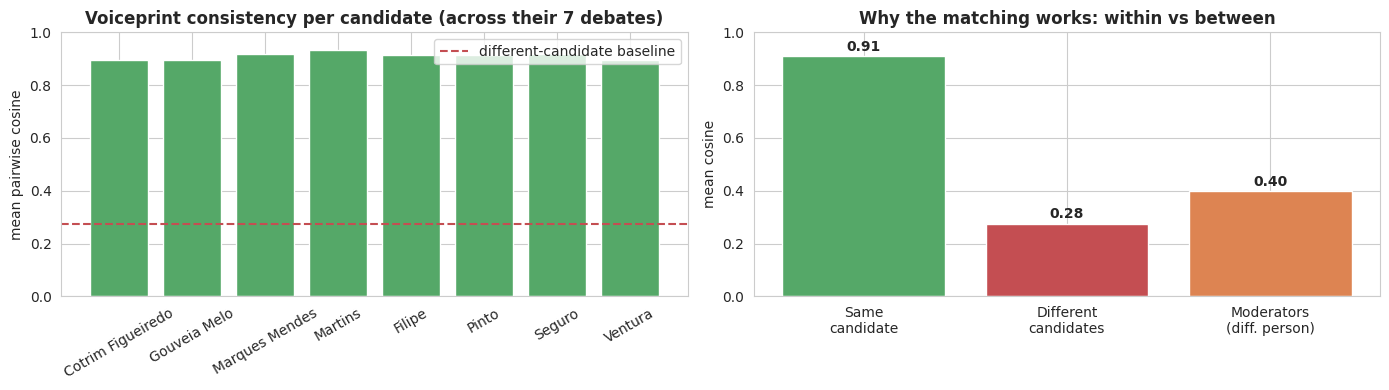

Voiceprint consistency (same candidate across 7 debates): 0.89-0.93  (mean 0.91)
Baseline between DIFFERENT candidates: 0.28
Moderators across debates (a different person each night): 0.40
=> a candidate's voice is ~3.3x more similar to itself than to other people.


In [ ]:
# Voiceprint consistency
from itertools import combinations

candidate_centroids = {cand: [debate_models[d]['centroids'][chosen[cand][d]] for d in debates_of[cand]]
                       for cand in CANDIDATES}

within_per_candidate, within_all = {}, []
for cand in CANDIDATES:
    pairs = [u @ v for u, v in combinations(candidate_centroids[cand], 2)]
    within_per_candidate[cand] = np.mean(pairs)
    within_all += pairs

flat = [(cand, vec) for cand in CANDIDATES for vec in candidate_centroids[cand]]
between_all = [v1 @ v2 for (c1, v1), (c2, v2) in combinations(flat, 2) if c1 != c2]

moderator_centroids = [model['centroids'][next(c for c, n in cluster_to_candidate[d].items() if n == 'Moderator')]
                       for d, model in debate_models.items()]
moderator_all = [u @ v for u, v in combinations(moderator_centroids, 2)]

within_mean, between_mean, moderator_mean = np.mean(within_all), np.mean(between_all), np.mean(moderator_all)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.bar([c.replace('_', ' ') for c in CANDIDATES], [within_per_candidate[c] for c in CANDIDATES], color='#55a868')
ax1.axhline(between_mean, color='#c44e52', ls='--', label='different-candidate baseline')
ax1.set_ylim(0, 1); ax1.set_ylabel('mean pairwise cosine'); ax1.legend()
ax1.set_title('Voiceprint consistency per candidate (across their 7 debates)', fontweight='bold')
ax1.tick_params(axis='x', rotation=30)
ax2.bar(['Same\ncandidate', 'Different\ncandidates', 'Moderators\n(diff. person)'],
        [within_mean, between_mean, moderator_mean], color=['#55a868', '#c44e52', '#dd8452'])
ax2.set_ylim(0, 1); ax2.set_ylabel('mean cosine')
ax2.set_title('Why the matching works: within vs between', fontweight='bold')
for i, value in enumerate([within_mean, between_mean, moderator_mean]):
    ax2.text(i, value + 0.02, f'{value:.2f}', ha='center', fontweight='bold')
plt.tight_layout(); plt.show()

print(f"Voiceprint consistency (same candidate across 7 debates): "
      f"{min(within_per_candidate.values()):.2f}-{max(within_per_candidate.values()):.2f}  (mean {within_mean:.2f})")
print(f"Baseline between DIFFERENT candidates: {between_mean:.2f}")
print(f"Moderators across debates (a different person each night): {moderator_mean:.2f}")
print(f"=> a candidate's voice is ~{within_mean/between_mean:.1f}x more similar to itself than to other people.")

# Global speaker umap — all 28 debates 


/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


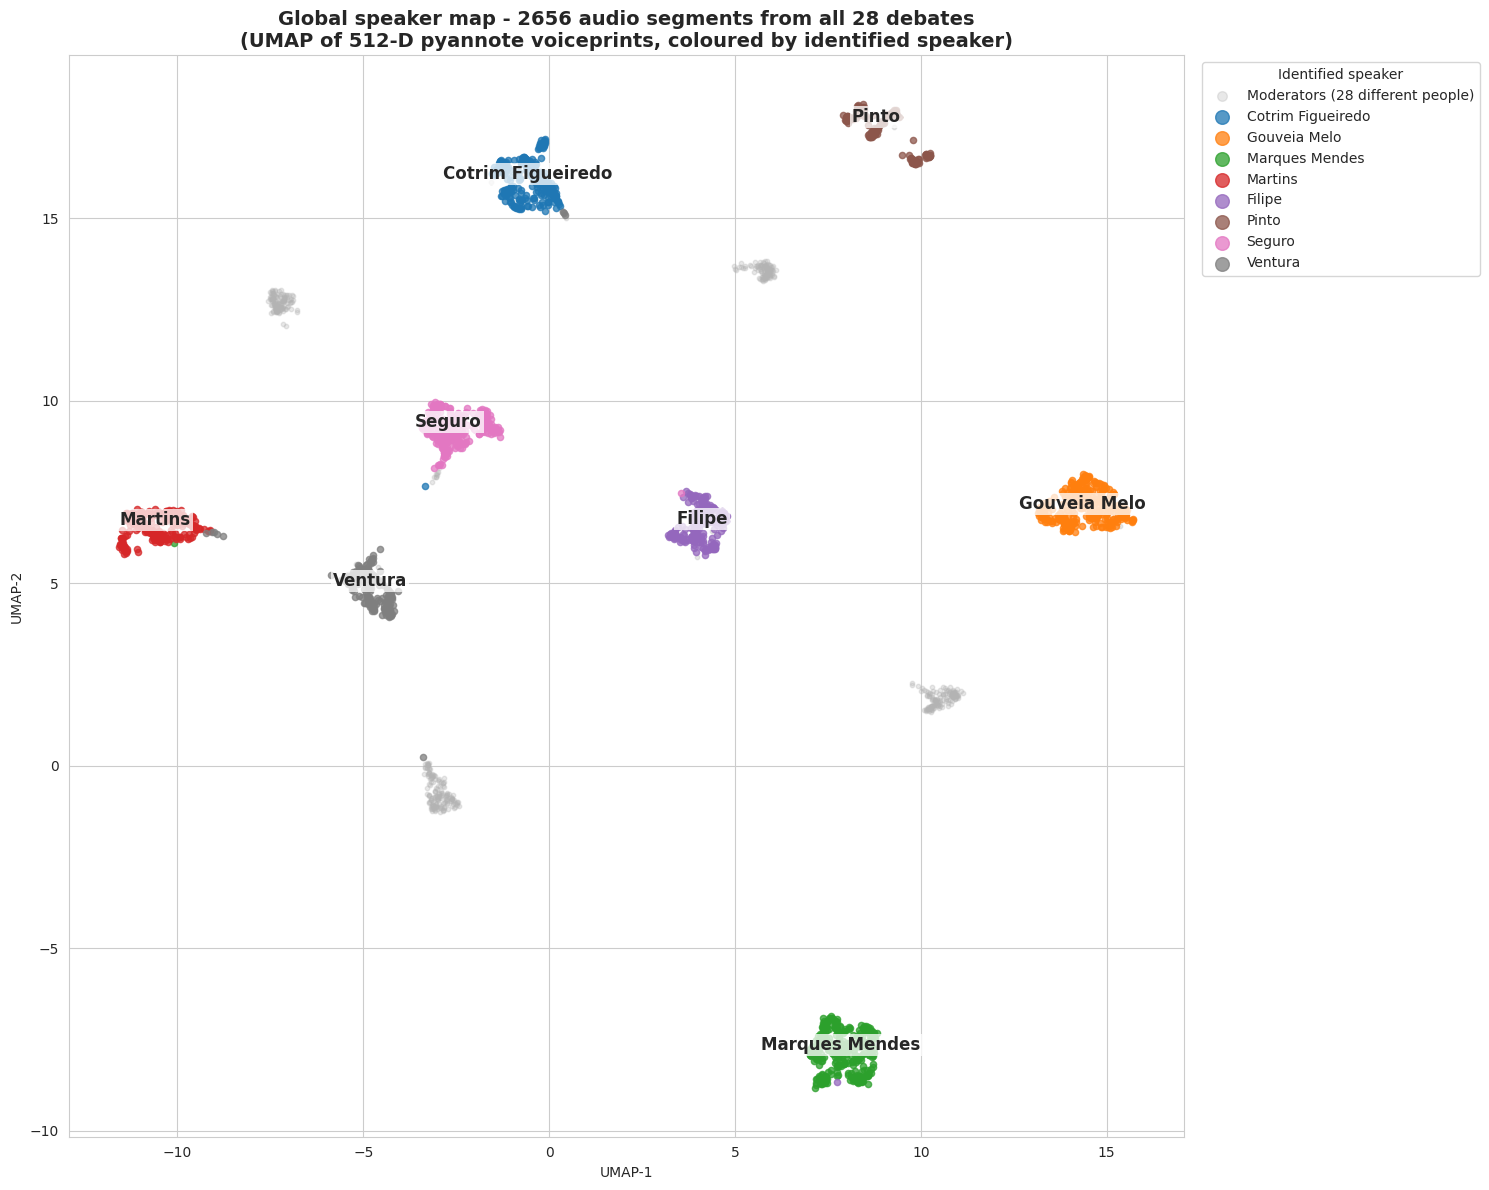

2656 segments total | 549 moderator, 2107 candidate
saved -> saved_plots/global_speaker_umap.png


In [ ]:
all_embeddings, all_speakers = [], []
for debate, model in debate_models.items():
    segments = model['segments']
    for i in range(len(segments)):
        all_embeddings.append(segments['speak_embeddings'].iloc[i])
        all_speakers.append(cluster_to_candidate[debate][model['labels'][i]])
all_embeddings = normalize(np.vstack(all_embeddings))
all_speakers = np.array(all_speakers)

coords = umap.UMAP(n_neighbors=20, min_dist=0.15, metric='cosine', random_state=42).fit_transform(all_embeddings)

speaker_colour = dict(zip(CANDIDATES, sns.color_palette('tab10', len(CANDIDATES))))
speaker_colour['Moderator'] = (0.7, 0.7, 0.7)

plt.figure(figsize=(15, 12))

is_moderator = all_speakers == 'Moderator'
plt.scatter(coords[is_moderator, 0], coords[is_moderator, 1], s=10,
            color=speaker_colour['Moderator'], alpha=0.30, label='Moderators (28 different people)')
for candidate in CANDIDATES:
    mask = all_speakers == candidate
    plt.scatter(coords[mask, 0], coords[mask, 1], s=20, color=speaker_colour[candidate],
                alpha=0.75, label=candidate.replace('_', ' '))

    cx, cy = np.median(coords[mask, 0]), np.median(coords[mask, 1])
    plt.text(cx, cy, candidate.replace('_', ' '), fontsize=12, fontweight='bold', ha='center',
             bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=1.5))

plt.title(f'Global speaker map - {len(all_embeddings)} audio segments from all 28 debates\n'
          '(UMAP of 512-D pyannote voiceprints, coloured by identified speaker)', fontsize=14, fontweight='bold')
plt.xlabel('UMAP-1'); plt.ylabel('UMAP-2')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', markerscale=2.2, fontsize=10, title='Identified speaker')
plt.tight_layout()
plt.savefig('saved_plots/global_speaker_umap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"{len(all_embeddings)} segments total | {is_moderator.sum()} moderator, {(~is_moderator).sum()} candidate")
print("saved -> saved_plots/global_speaker_umap.png")

# Per candidate vocabulary and speaking time

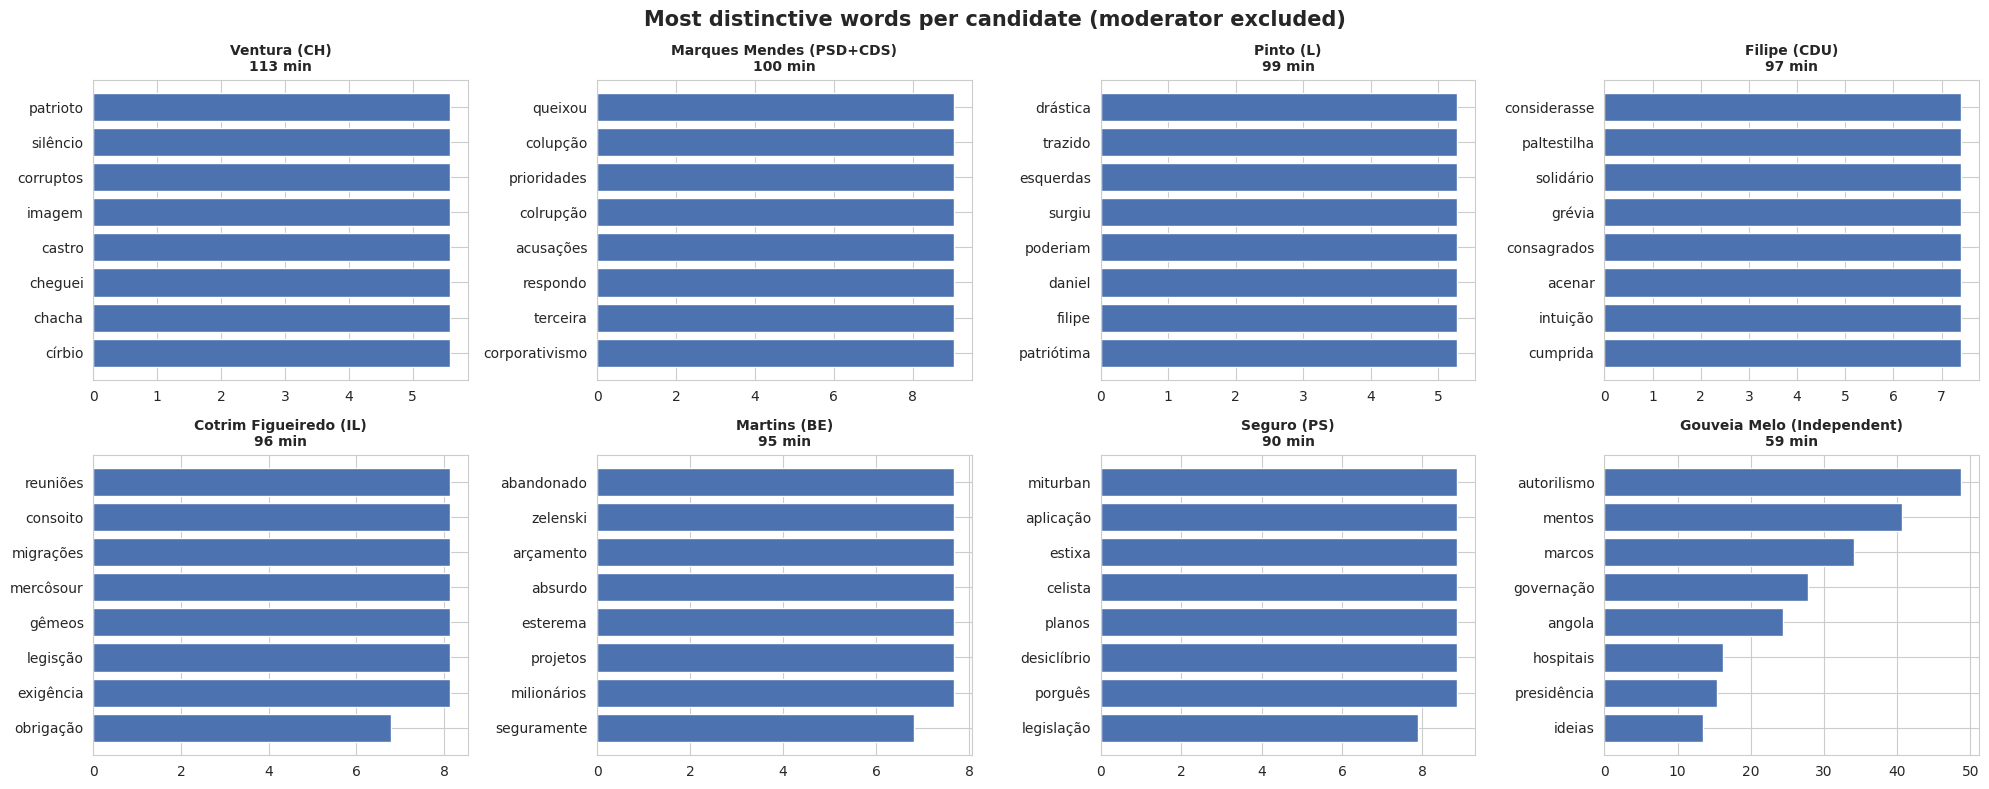

  saved -> cleaned_features/candidate_vocabulary.pkl   (120 rows x 4 cols)


In [ ]:
STOPWORDS = set('para como mais pessoas porque quando muito ainda sobre nosso nossa temos podem '
                'todos isso aqui mesmo entre depois sempre também tudo nada cada qualquer assim '
                'estava estamos estão deve pode ter foram'.split())

words_by_candidate = defaultdict(Counter)
speaking_seconds   = defaultdict(float)

for debate, model in debate_models.items():
    df_speech = pd.read_pickle(FEAT_DIR + debate + '_speech.pkl')
    segments, labels, mapping = model['segments'], model['labels'], cluster_to_candidate[debate]
    audio_start = segments['time stamp'].values
    audio_end   = audio_start + segments['duration'].values

    for i in range(len(segments)):
        speaker = mapping[labels[i]]
        if speaker in CANDIDATES:
            speaking_seconds[speaker] += segments['duration'].iloc[i]

    for _, line in df_speech.iterrows():
        line_start, line_end = line['timestamp'], line['timestamp'] + line['duration']
        overlap = np.maximum(0, np.minimum(line_end, audio_end) - np.maximum(line_start, audio_start))
        if overlap.sum() == 0:
            continue
        speaker = mapping[labels[int(overlap.argmax())]]
        if speaker not in CANDIDATES:
            continue
        text = re.sub(r'\d+', '', re.sub(r'[^\w\s]', '', str(line['transcript']).lower()))
        for word in text.split():
            if len(word) > 5 and word not in STOPWORDS:
                words_by_candidate[speaker][word] += 1

all_words = Counter()
for candidate in CANDIDATES:
    all_words.update(words_by_candidate[candidate])

def distinctive_words(candidate, n=8):
    total = sum(words_by_candidate[candidate].values())
    scores = {}
    for word, count in words_by_candidate[candidate].items():
        if count >= 4:
            scores[word] = (count / total) / (all_words[word] / sum(all_words.values()))
    return sorted(scores.items(), key=lambda x: -x[1])[:n]

party = pd.read_pickle(FEAT_DIR + 'candidate_party.pkl').set_index('Candidate')['Party'].to_dict()
fig, axes = plt.subplots(2, 4, figsize=(20, 8)); axes = axes.ravel()
for ax, candidate in zip(axes, sorted(CANDIDATES, key=lambda c: -speaking_seconds[c])):
    top = distinctive_words(candidate)[::-1]
    ax.barh([w for w, _ in top], [s for _, s in top], color='#4C72B0')
    ax.set_title(f"{candidate.replace('_', ' ')} ({party.get(candidate, '?')})\n"
                 f"{speaking_seconds[candidate]/60:.0f} min", fontsize=10, fontweight='bold')
plt.suptitle('Most distinctive words per candidate (moderator excluded)', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

vocab_rows = []
for candidate in CANDIDATES:
    for word, score in distinctive_words(candidate, 15):
        vocab_rows.append({'candidate': candidate, 'word': word,
                           'count': words_by_candidate[candidate][word], 'distinctiveness': round(score, 2)})
candidate_vocabulary = pd.DataFrame(vocab_rows)
save_table(candidate_vocabulary, "candidate_vocabulary.pkl")

# Candidates vocal profile

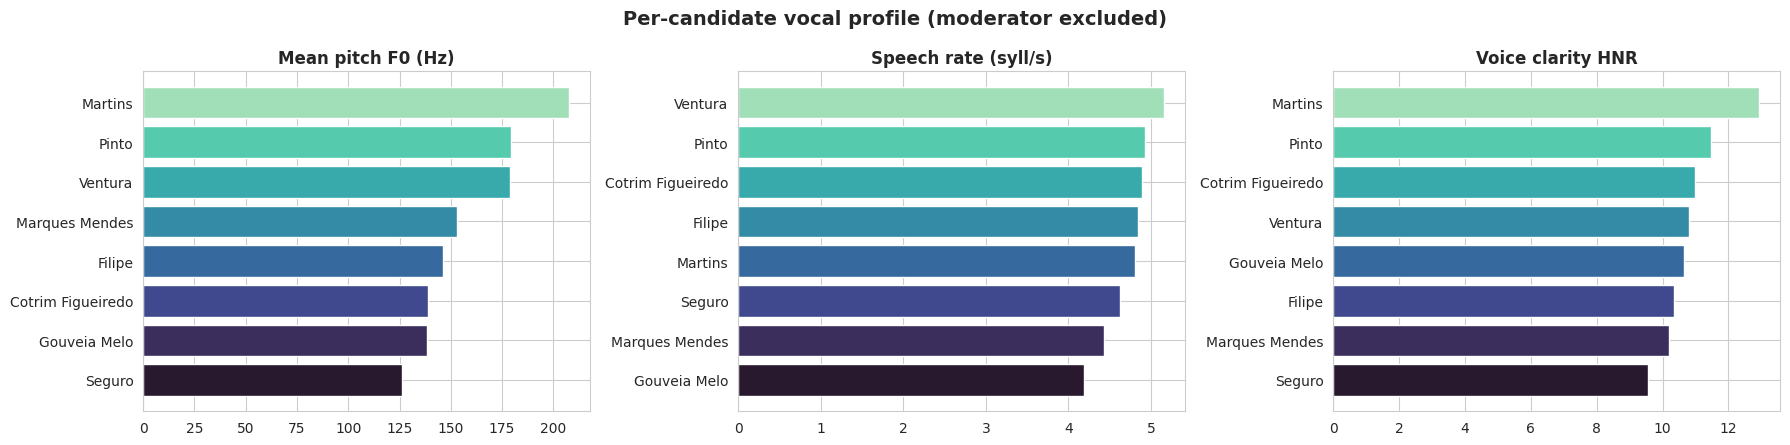

                   meanF0Hz  speechrate  articulationrate   HNR  stdevF0Hz
Cotrim_Figueiredo     138.9         4.9               5.1  11.0       30.8
Gouveia_Melo          138.6         4.2               4.7  10.7       27.1
Marques_Mendes        153.2         4.4               4.7  10.2       38.2
Martins               207.5         4.8               5.1  12.9       39.3
Filipe                146.1         4.8               5.2  10.3       33.9
Pinto                 179.4         4.9               5.1  11.5       32.1
Seguro                126.4         4.6               5.0   9.6       30.9
Ventura               179.0         5.2               5.3  10.8       43.3
  saved -> cleaned_features/candidate_vocal_profile.pkl   (8 rows x 6 cols)


In [ ]:
ACOUSTIC = ['meanF0Hz', 'speechrate', 'articulationrate', 'HNR', 'stdevF0Hz']
acoustic_values = defaultdict(lambda: defaultdict(list))

for debate, model in debate_models.items():
    segments, labels, mapping = model['segments'], model['labels'], cluster_to_candidate[debate]
    for i in range(len(segments)):
        candidate = mapping[labels[i]]
        if candidate not in CANDIDATES:
            continue
        for feature in ACOUSTIC:
            value = segments[feature].iloc[i]
            if pd.notna(value):
                acoustic_values[candidate][feature].append(value)

vocal_profile = pd.DataFrame({
    candidate: {feature: np.mean(acoustic_values[candidate][feature]) for feature in ACOUSTIC}
    for candidate in CANDIDATES
}).T

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for ax, feature, label in zip(axes, ['meanF0Hz', 'speechrate', 'HNR'],
                              ['Mean pitch F0 (Hz)', 'Speech rate (syll/s)', 'Voice clarity HNR']):
    ordered = vocal_profile[feature].sort_values()
    ax.barh([c.replace('_', ' ') for c in ordered.index], ordered.values,
            color=sns.color_palette('mako', 8))
    ax.set_title(label, fontweight='bold')
plt.suptitle('Per-candidate vocal profile (moderator excluded)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print(vocal_profile.round(1).to_string())
save_table(vocal_profile.reset_index().rename(columns={'index': 'candidate'}), "candidate_vocal_profile.pkl")

# Debate topics vs newscast topics

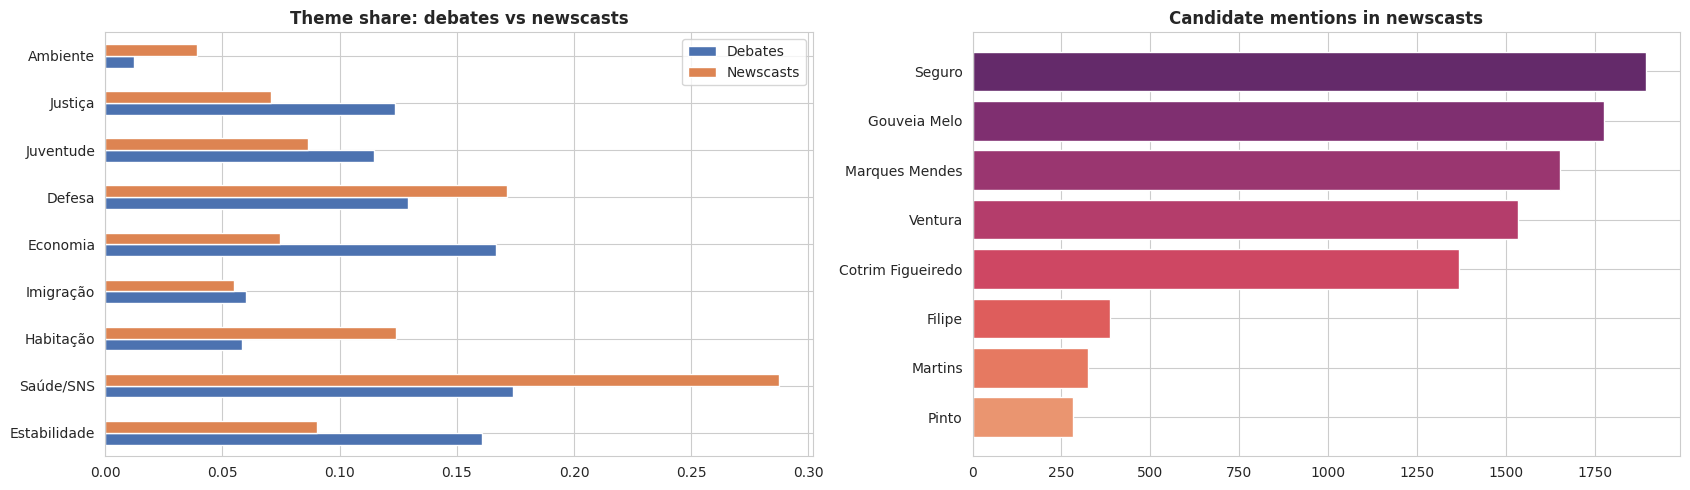

In [14]:
# 3.5 - Debate vs newscast themes and candidate mentions
newscast_speech_files = sorted(f for f in os.listdir(FEAT_DIR)
                               if f.endswith('_speech.pkl') and 'Telejornal' in f)
newscast_text = ' '.join(' '.join(pd.read_pickle(FEAT_DIR + f)['transcript'].dropna().astype(str))
                         for f in newscast_speech_files)
newscast_themes = pd.Series(count_themes(newscast_text))

comparison = pd.DataFrame({
    'Debates':   debate_themes[THEME_NAMES].sum() / debate_themes[THEME_NAMES].sum().sum(),
    'Newscasts': newscast_themes / newscast_themes.sum()
})

ocr_text_parts = []
for filename in sorted(f for f in os.listdir(FEAT_DIR) if f.endswith('_ocr.pkl')):
    for cell in pd.read_pickle(FEAT_DIR + filename)['OCR']:
        if isinstance(cell, (list, np.ndarray)):
            ocr_text_parts += [re.sub('<[^>]+>', '', str(b.get('text', ''))) for b in cell if isinstance(b, dict)]
all_news_text = (newscast_text + ' ' + ' '.join(ocr_text_parts)).lower()

surname = {c: c.split('_')[-1].lower() for c in CANDIDATES}
surname['Marques_Mendes'] = 'mendes'; surname['Gouveia_Melo'] = 'gouveia'; surname['Cotrim_Figueiredo'] = 'cotrim'
mentions = pd.Series({c: len(re.findall(r'\b' + surname[c] + r'\b', all_news_text)) for c in CANDIDATES}).sort_values()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 5))
comparison.plot.barh(ax=ax1, color=['#4C72B0', '#dd8452'])
ax1.set_title('Theme share: debates vs newscasts', fontweight='bold')
ax2.barh([c.replace('_', ' ') for c in mentions.index], mentions.values, color=sns.color_palette('flare', 8))
ax2.set_title('Candidate mentions in newscasts', fontweight='bold')
plt.tight_layout(); plt.show()

# Relation to the polls

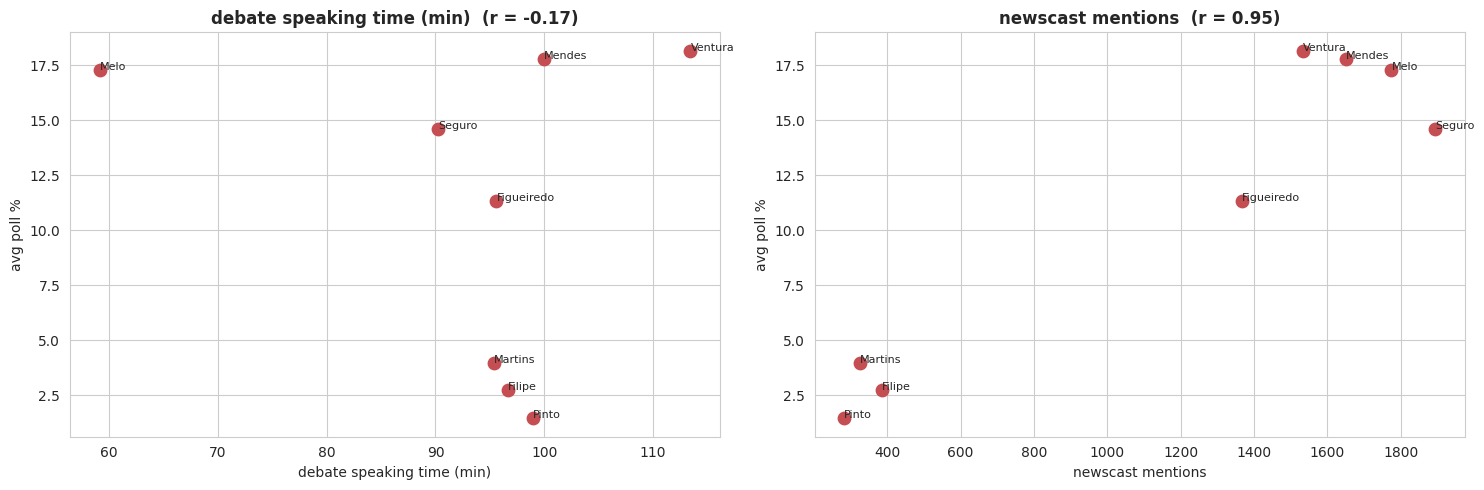

speaking time vs poll : r = -0.17
news mentions vs poll : r = 0.95


In [ ]:
polls = pd.read_pickle(FEAT_DIR + 'polls_timeline.pkl')
average_poll = polls[CANDIDATES].mean()

comparison_polls = pd.DataFrame({
    'poll': average_poll,
    'speaking_min': pd.Series(speaking_seconds) / 60,
    'news_mentions': mentions
}).dropna()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, column, label in zip(axes, ['speaking_min', 'news_mentions'],
                             ['debate speaking time (min)', 'newscast mentions']):
    ax.scatter(comparison_polls[column], comparison_polls['poll'], s=80, color='#c44e52')
    for candidate, row in comparison_polls.iterrows():
        ax.annotate(candidate.split('_')[-1], (row[column], row['poll']), fontsize=8)
    r = comparison_polls[column].corr(comparison_polls['poll'])
    ax.set_xlabel(label); ax.set_ylabel('avg poll %'); ax.set_title(f'{label}  (r = {r:.2f})', fontweight='bold')
plt.tight_layout(); plt.show()
print(f"speaking time vs poll : r = {comparison_polls['speaking_min'].corr(comparison_polls['poll']):.2f}")
print(f"news mentions vs poll : r = {comparison_polls['news_mentions'].corr(comparison_polls['poll']):.2f}")

# Absolute 1-second timeline + wavelet theme detector 

In [ ]:
def add_speech_rate(df_speech):
    df = df_speech.copy()
    df['word_count'] = df['transcript'].fillna('').astype(str).str.split().str.len()
    df['speech_rate'] = np.where(df['duration'] > 0, df['word_count'] / df['duration'], 0.0)
    return df

def build_absolute_timeline(df_visual, df_speech):

    df_master = df_visual.copy()
    if 'frame_idx' in df_master.columns:
        df_master = df_master.set_index('frame_idx')

    second_text = {}
    for _, row in df_speech.iterrows():
        if pd.isna(row['transcript']) or row['duration'] <= 0 or row['speech_rate'] <= 0:
            continue
        words = str(row['transcript']).split()
        start_second = int(round(row['timestamp']))
        words_per_second = row['speech_rate']
        for i in range(math.ceil(row['duration'])):
            chunk = words[int(round(i * words_per_second)): int(round((i + 1) * words_per_second))]
            if chunk:
                second = start_second + i
                second_text[second] = (second_text.get(second, '') + ' ' + ' '.join(chunk)).strip()

    df_master = df_master.join(pd.Series(second_text, name='transcript_1Hz'), how='left')
    df_master['transcript_1Hz'] = df_master['transcript_1Hz'].fillna('')
    df_master['is_silence'] = df_master['transcript_1Hz'] == ''
    return df_master

theme_pattern = {theme: re.compile('|'.join(r'\b' + re.escape(w) + r'\b' for w in words))
                 for theme, words in THEMES.items()}

def wavelet_theme_timeline(df_master):

    length = int(df_master.index.max()) + 1
    counts = pd.DataFrame(0.0, index=range(length), columns=THEME_NAMES)
    for second, text in df_master['transcript_1Hz'].items():
        if text:
            text = text.lower()
            for theme in THEME_NAMES:
                counts.at[second, theme] = len(theme_pattern[theme].findall(text))

    power = pd.DataFrame(index=range(length))
    for theme in THEME_NAMES:
        signal = counts[theme].values
        if signal.sum() > 0:
            coefficients, _ = pywt.cwt(signal, np.arange(1, 64), 'cmor1.5-1.0', sampling_period=1)
            power[theme] = (np.abs(coefficients) ** 2).sum(axis=0)
        else:
            power[theme] = 0.0

    dominant = power.idxmax(axis=1)
    peak = power.max(axis=1)
    floor = peak[peak > 0].median() * 0.05 if (peak > 0).any() else 0
    dominant[peak < floor] = 'None'
    return power, dominant

def speaker_timeline(debate, length):
    model = debate_models[debate]
    mapping = cluster_to_candidate[debate]
    who = pd.Series('-', index=range(length))
    for i in range(len(model['segments'])):
        start = int(round(model['segments']['time stamp'].iloc[i]))
        end   = int(round(model['segments']['time stamp'].iloc[i] + model['segments']['duration'].iloc[i]))
        who.loc[start:end] = mapping[model['labels'][i]]
    return who

print("build_absolute_timeline / wavelet_theme_timeline ready.")

build_absolute_timeline / wavelet_theme_timeline ready.


In [ ]:
# Build and save per-second master timelines + theme emphasis
emphasis_rows = []
for debate, model in debate_models.items():
    df_visual = pd.read_pickle(CLEAN_DIR + debate + "_visual.pkl")
    df_speech = add_speech_rate(pd.read_pickle(FEAT_DIR + debate + "_speech.pkl"))

    df_master = build_absolute_timeline(df_visual, df_speech)
    power, dominant = wavelet_theme_timeline(df_master)
    length = int(df_master.index.max()) + 1

    df_master['theme_1Hz']   = dominant.reindex(df_master.index).fillna('None').values

    df_master['speaker_1Hz'] = speaker_timeline(debate, length).reindex(df_master.index).fillna('-').values
    df_master.to_pickle(CLEAN_DIR + debate + "_master.pkl")

    spoken = df_master[df_master['speaker_1Hz'].isin(CANDIDATES) & (df_master['theme_1Hz'] != 'None')]
    cand_a, cand_b, month, day, day_no = parse_debate_name(debate)
    for candidate, group in spoken.groupby('speaker_1Hz'):
        share = group['theme_1Hz'].value_counts(normalize=True)
        row = {theme: share.get(theme, 0.0) for theme in THEME_NAMES}
        row.update(candidate=candidate, debate=debate, day=day_no)
        emphasis_rows.append(row)

theme_emphasis = pd.DataFrame(emphasis_rows)
print(f"saved {len(debate_models)} '*_master.pkl' timelines into {CLEAN_DIR}")
save_table(theme_emphasis, "theme_emphasis_by_candidate.pkl")

saved 28 '*_master.pkl' timelines into cleaned_features/
  saved -> cleaned_features/theme_emphasis_by_candidate.pkl   (56 rows x 12 cols)


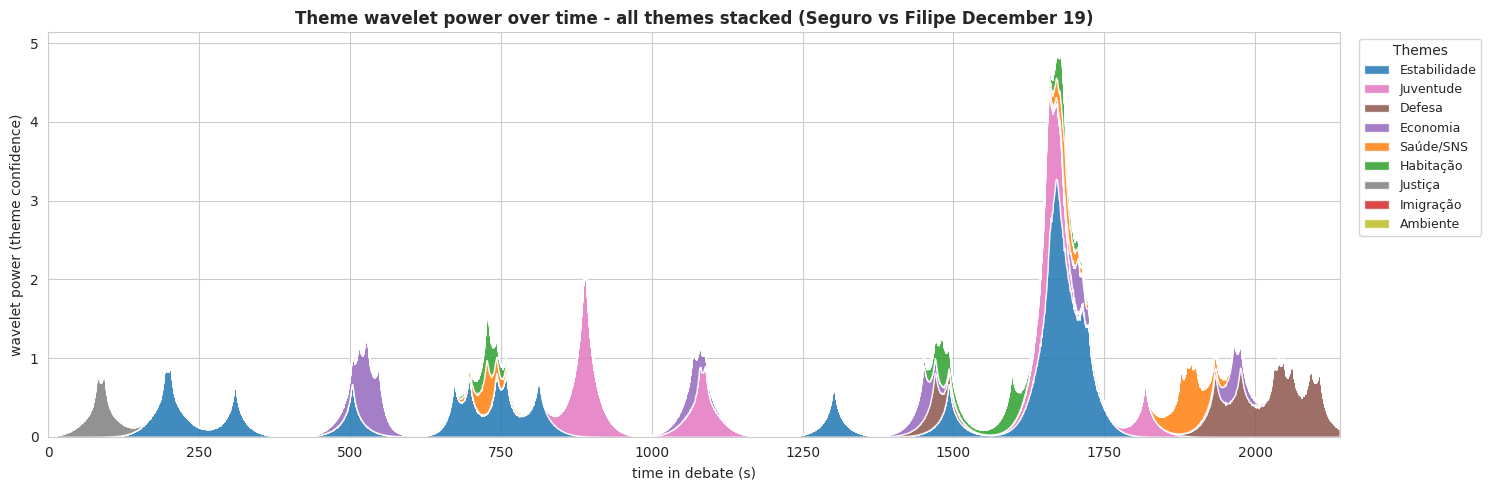

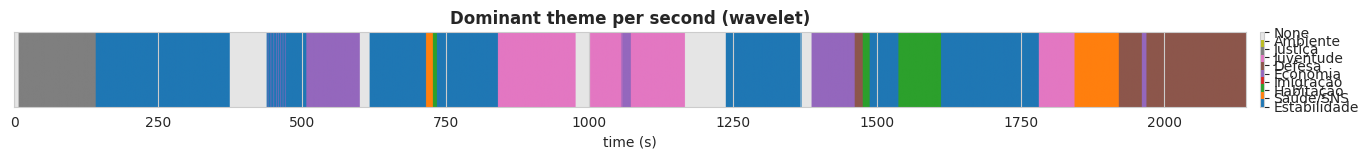

In [ ]:
# Featured debate: stacked theme power + dominant-theme ribbon
df_master_featured = pd.read_pickle(CLEAN_DIR + DEBATE + "_master.pkl")
power, dominant = wavelet_theme_timeline(df_master_featured)
length = len(power)
theme_colour = dict(zip(THEME_NAMES, sns.color_palette('tab10', 9)))

stack_order = power[THEME_NAMES].sum().sort_values(ascending=False).index
plt.figure(figsize=(15, 5))
plt.stackplot(range(length), [power[t].values for t in stack_order],
              labels=list(stack_order), colors=[theme_colour[t] for t in stack_order], alpha=0.85)
plt.title(f'Theme wavelet power over time - all themes stacked ({DEBATE.replace("_", " ")})', fontweight='bold')
plt.xlabel('time in debate (s)'); plt.ylabel('wavelet power (theme confidence)'); plt.xlim(0, length)
plt.legend(title='Themes', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout(); plt.show()

ribbon_labels = THEME_NAMES + ['None']
ribbon_colours = [theme_colour[t] for t in THEME_NAMES] + [(0.9, 0.9, 0.9)]
code_of = {label: i for i, label in enumerate(ribbon_labels)}
ribbon = dominant.map(code_of).values[np.newaxis, :]
fig, ax = plt.subplots(figsize=(15, 1.7))
img = ax.imshow(ribbon, aspect='auto', cmap=mpl.colors.ListedColormap(ribbon_colours),
                vmin=0, vmax=len(ribbon_labels) - 1, extent=[0, length, 0, 1])
ax.set_yticks([]); ax.set_xlabel('time (s)')
ax.set_title('Dominant theme per second (wavelet)', fontweight='bold')
bar = plt.colorbar(img, ax=ax, pad=0.01, ticks=range(len(ribbon_labels))); bar.set_ticklabels(ribbon_labels)
plt.tight_layout(); plt.show()

# Candidates agenda in all 28 debates vs polls

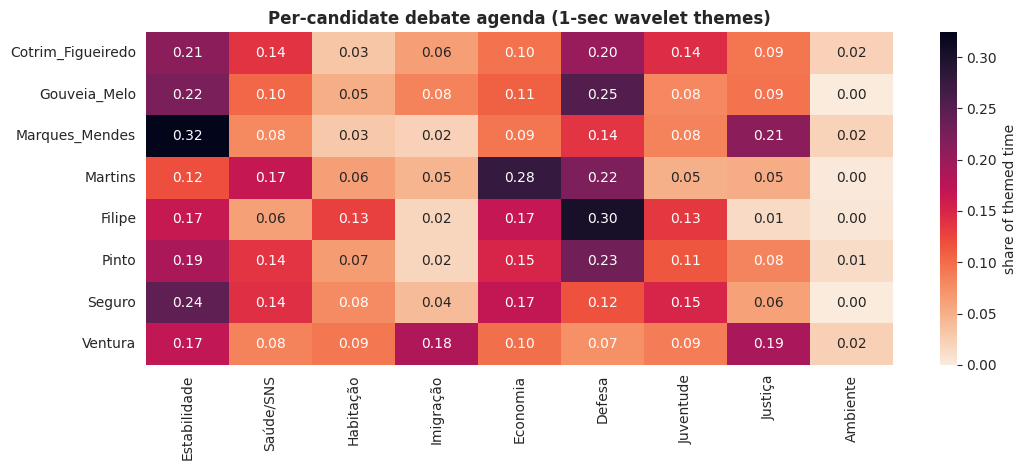

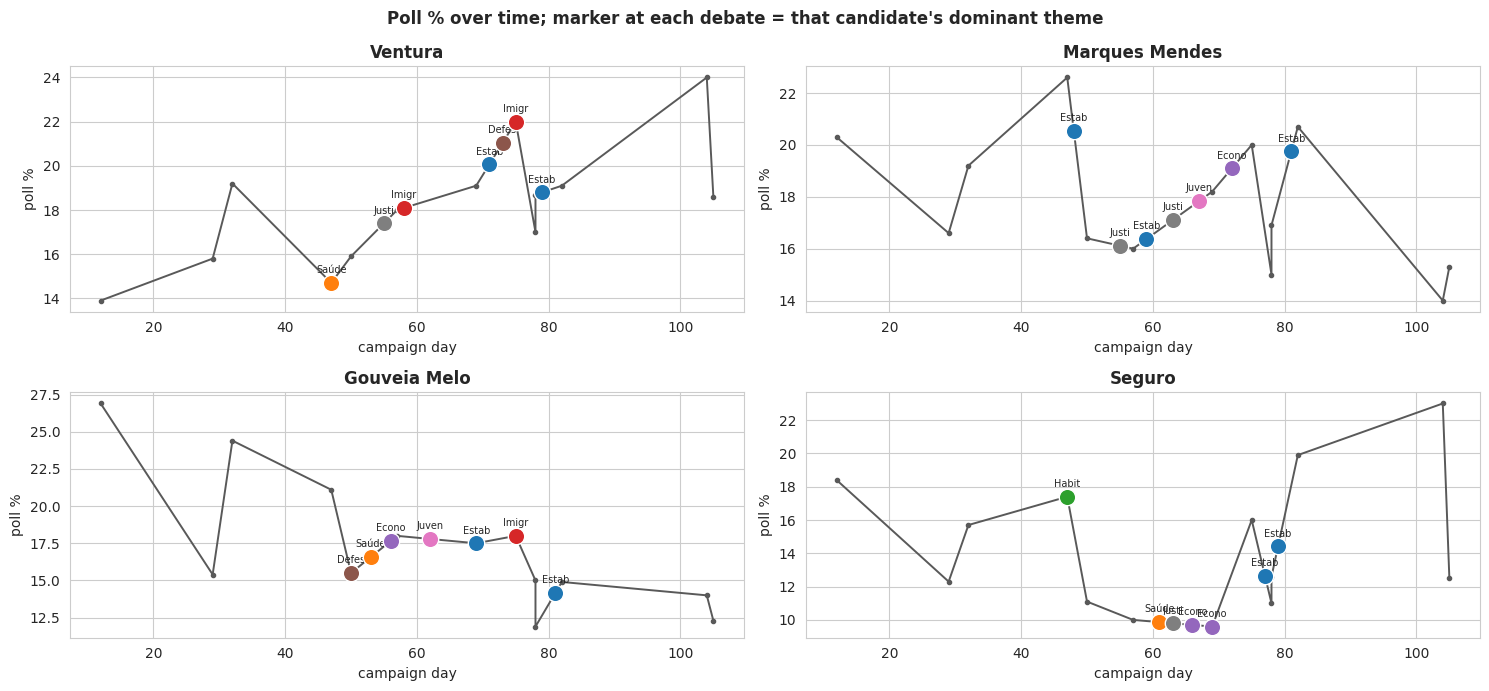

In [ ]:
agenda = theme_emphasis.groupby('candidate')[THEME_NAMES].mean().reindex(CANDIDATES)
plt.figure(figsize=(11, 4.8))
sns.heatmap(agenda, annot=True, fmt='.2f', cmap='rocket_r', cbar_kws={'label': 'share of themed time'})
plt.title('Per-candidate debate agenda (1-sec wavelet themes)', fontweight='bold'); plt.ylabel('')
plt.tight_layout(); plt.show()

polls['day'] = [day_number(d.split('_')[0], int(d.split('_')[1])) for d in polls['date']]
def poll_change(candidate, day, window=12):
    before = polls.loc[(polls['day'] > day - window) & (polls['day'] <= day), candidate].mean()
    after  = polls.loc[(polls['day'] > day) & (polls['day'] <= day + window), candidate].mean()
    return after - before
theme_emphasis['poll_change'] = [poll_change(r.candidate, r.day) for r in theme_emphasis.itertuples()]

top4 = polls[CANDIDATES].mean().sort_values(ascending=False).index[:4]
polls_sorted = polls.sort_values('day')
fig, axes = plt.subplots(2, 2, figsize=(15, 7)); axes = axes.ravel()
for ax, candidate in zip(axes, top4):
    ax.plot(polls_sorted['day'], polls_sorted[candidate], color='0.35', lw=1.4, marker='o', ms=3)
    for _, row in theme_emphasis[theme_emphasis['candidate'] == candidate].sort_values('day').iterrows():
        dominant_theme = row[THEME_NAMES].astype(float).idxmax()
        y = np.interp(row['day'], polls_sorted['day'], polls_sorted[candidate])
        ax.scatter(row['day'], y, color=theme_colour[dominant_theme], s=140, edgecolor='white', zorder=5)
        ax.annotate(dominant_theme.split('/')[0][:5], (row['day'], y), fontsize=7, ha='center',
                    xytext=(0, 7), textcoords='offset points')
    ax.set_title(candidate.replace('_', ' '), fontweight='bold'); ax.set_xlabel('campaign day'); ax.set_ylabel('poll %')
plt.suptitle("Poll % over time; marker at each debate = that candidate's dominant theme", fontweight='bold')
plt.tight_layout(); plt.show()

# Themes vs poll change analysis

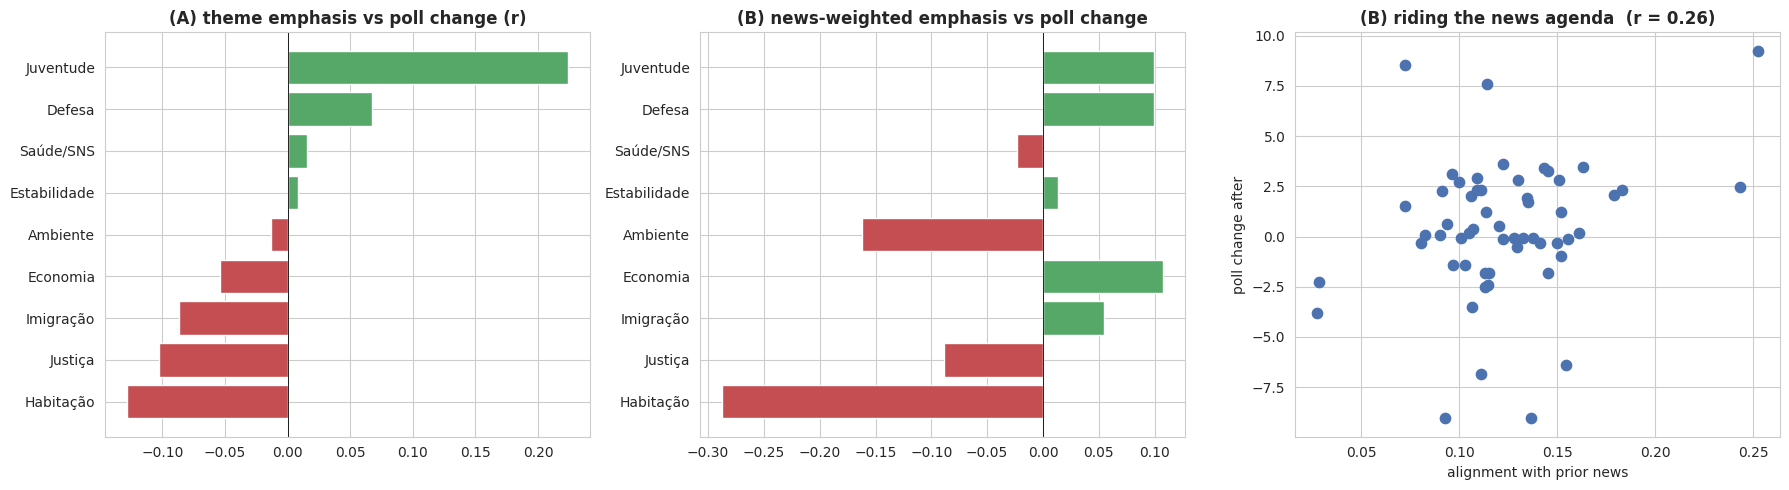

agenda-alignment vs poll change: r = 0.26
most poll-positive theme: Juventude (r = 0.22)


In [ ]:
emphasis = theme_emphasis.dropna(subset=['poll_change']).copy()
corr_raw = pd.Series({t: emphasis[t].corr(emphasis['poll_change']) for t in THEME_NAMES}).sort_values()

newscast_dates = defaultdict(list)
for filename in sorted(set(re.sub(r'_(ocr|speech)\.pkl', '', f) for f in os.listdir(FEAT_DIR) if f.startswith('Telejornal'))):
    m = re.search(r'_(Nov|Dec|Jan)_(\d+)$', filename)
    full_month = {'Nov': 'November', 'Dec': 'December', 'Jan': 'January'}[m.group(1)]
    newscast_dates[day_number(full_month, int(m.group(2)))].append(filename)

news_theme_share = {}
for day, files in newscast_dates.items():
    shares = np.zeros(9)
    for filename in files:
        text = ' '.join(pd.read_pickle(FEAT_DIR + filename + '_speech.pkl')['transcript'].dropna().astype(str))
        vec = np.array(list(count_themes(text).values()), float)
        if vec.sum() > 0:
            shares += vec / vec.sum()
    news_theme_share[day] = shares / len(files)
news_days = sorted(news_theme_share)

def news_before(day):
    earlier = [d for d in news_days if d < day]
    return news_theme_share[earlier[-1]] if earlier else None

alignment = []
weighted = []
for _, row in emphasis.iterrows():
    prior = news_before(row['day'])
    emphasis_vec = row[THEME_NAMES].values.astype(float)
    if prior is None:
        alignment.append(np.nan); weighted.append([np.nan] * 9); continue
    alignment.append(float(emphasis_vec @ (prior / prior.sum())))
    w = emphasis_vec * prior
    weighted.append(w / w.sum() if w.sum() > 0 else w)
emphasis['alignment'] = alignment
weighted = pd.DataFrame(weighted, index=emphasis.index, columns=THEME_NAMES)
corr_weighted = pd.Series({t: weighted[t].corr(emphasis['poll_change']) for t in THEME_NAMES}).reindex(corr_raw.index)
alignment_r = emphasis['alignment'].corr(emphasis['poll_change'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].barh(corr_raw.index, corr_raw.values, color=['#c44e52' if v < 0 else '#55a868' for v in corr_raw.values])
axes[0].axvline(0, color='k', lw=0.6); axes[0].set_title('(A) theme emphasis vs poll change (r)', fontweight='bold')
axes[1].barh(corr_weighted.index, corr_weighted.values, color=['#c44e52' if v < 0 else '#55a868' for v in corr_weighted.values])
axes[1].axvline(0, color='k', lw=0.6); axes[1].set_title('(B) news-weighted emphasis vs poll change', fontweight='bold')
axes[2].scatter(emphasis['alignment'], emphasis['poll_change'], s=55, color='#4C72B0')
axes[2].set_xlabel('alignment with prior news'); axes[2].set_ylabel('poll change after')
axes[2].set_title(f'(B) riding the news agenda  (r = {alignment_r:.2f})', fontweight='bold')
plt.tight_layout(); plt.show()
print(f"agenda-alignment vs poll change: r = {alignment_r:.2f}")
print(f"most poll-positive theme: {corr_raw.idxmax()} (r = {corr_raw.max():.2f})")

TRying to get some validation

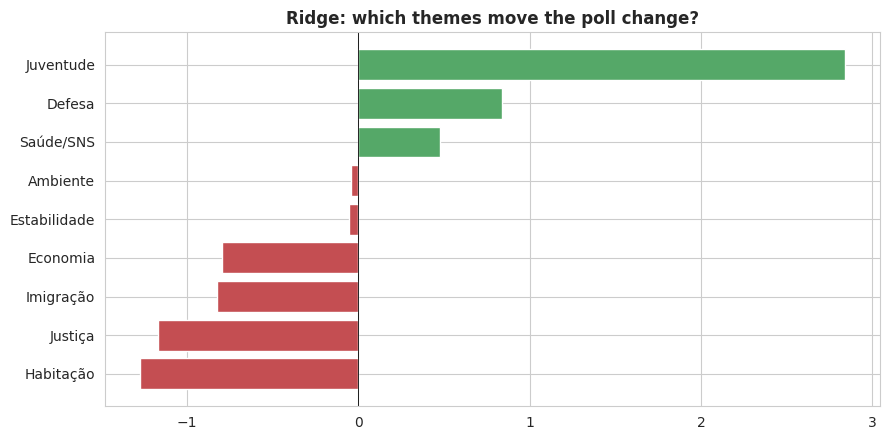

Ridge leave-one-out R^2 = -0.153  (n = 56)
=> with only 13 multi-agency polls, themes do NOT predict poll moves out of sample.
most poll-positive theme (Ridge): Juventude (+2.84)


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import LeaveOneOut

X = emphasis[THEME_NAMES].values
y = emphasis['poll_change'].values
predicted = np.zeros(len(y))
for train, test in LeaveOneOut().split(X):
    predicted[test] = Ridge(alpha=1.0).fit(X[train], y[train]).predict(X[test])
loo_r2 = 1 - ((y - predicted) ** 2).sum() / ((y - y.mean()) ** 2).sum()
coefficients = pd.Series(Ridge(alpha=1.0).fit(X, y).coef_, index=THEME_NAMES).sort_values()

plt.figure(figsize=(9, 4.5))
plt.barh(coefficients.index, coefficients.values,
         color=['#c44e52' if v < 0 else '#55a868' for v in coefficients.values])
plt.axvline(0, color='k', lw=0.6)
plt.title('Ridge: which themes move the poll change?', fontweight='bold')
plt.tight_layout(); plt.show()

print(f"Ridge leave-one-out R^2 = {loo_r2:+.3f}  (n = {len(y)})")
print("=> with only 13 multi-agency polls, themes do NOT predict poll moves out of sample.")
print(f"most poll-positive theme (Ridge): {coefficients.idxmax()} ({coefficients.max():+.2f})")